# Machine Learning Case Study
## Credit Default Prediction

### Predicting customer default risk using:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machines (SVM)

---

**Course:** Machine Learning 1 — Classification Methods  
**Author:** Szymon Lis

# Business Problem

Financial institutions issue thousands of credit cards and loans every day.  
One of the key business challenges is assessing whether a customer is likely to default on future payments.

Incorrect predictions can generate substantial financial losses:

- approving a risky customer may lead to loan default,
- rejecting a trustworthy customer may result in lost revenue and customer dissatisfaction.

The objective of this project is to build machine learning models capable of predicting whether a customer will default on their credit card payment next month.

# Why Is This Problem Important?

Credit default prediction is one of the most important applications of machine learning in finance and banking.

This problem introduces many real-world machine learning challenges:

- imbalanced classes,
- probability estimation,
- threshold selection,
- feature scaling,
- overfitting,
- model interpretability,
- hyperparameter tuning,
- model evaluation under business constraints.

This makes the dataset an excellent case study for supervised machine learning.

# Machine Learning Formulation

This is a **supervised binary classification problem**.

Goal:
- predict whether a customer will default (`1`) or not default (`0`).

Input:
- customer demographic data,
- historical payment behavior,
- billing information,
- repayment history.

Output:
- probability of default,
- predicted class label.

# Mathematical Formulation

We aim to estimate a function:

\[
Y = f(X) + \epsilon
\]

where:

- \(X\) represents customer features,
- \(Y\) is the target variable (default / no default),
- \(f(X)\) is the unknown relationship learned by the model,
- \(\epsilon\) is irreducible noise.

# Business Cost of Errors

In classification problems, different types of errors may have different business consequences.

## False Positive (Type I Error)
Model predicts default, but customer would repay the loan.

Possible consequence:
- lost customer,
- lost revenue,
- reduced customer satisfaction.

## False Negative (Type II Error)
Model predicts no default, but customer actually defaults.

Possible consequence:
- direct financial loss,
- increased credit risk,
- higher operational costs.


In real-world financial systems, False Negatives are often significantly more expensive than False Positives.

# Why Accuracy Alone Can Be Misleading

In many financial datasets, the number of non-default customers is much larger than the number of default customers.

As a result:

- a model predicting "no default" for every customer may achieve high accuracy,
- while completely failing to identify risky customers.

Therefore, in this project we will evaluate models using:
- Precision,
- Recall,
- F1-score,
- ROC AUC,
- PR AUC,
- Confusion Matrix analysis.

# Dataset

Dataset:
**Default of Credit Card Clients Dataset**

Source:
UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients?)

The dataset contains information about:
- customer demographics,
- credit limits,
- historical payments,
- bill statements,
- repayment status.

Target variable:
- `default payment next month`

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_excel(
    "default of credit card clients.xls",
    header=1
)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df = df.rename(
    columns={
        "default payment next month": "default"
    }
)

# 2. Data Understanding & Exploratory Data Analysis

Before training any machine learning model, we need to understand the structure, quality, and statistical properties of our data.

In this section, we will answer the following questions:

- How many observations and features do we have?
- What types of variables are available?
- Are there missing values or duplicated records?
- How is the target variable distributed?
- Are classes balanced or imbalanced?
- What are the distributions of key numerical variables?
- Are there visible relationships between features and credit default?

In [7]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
print(df.shape)

(30000, 25)


The dataset contains:

- rows: individual credit card clients,
- columns: client characteristics, credit history, payment history, and the target variable.

Each row represents one client.  
The target variable tells us whether the client defaulted on payment next month.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

### Dataset Structure and Data Quality

The dataset contains:

- **30,000 observations**,
- **25 columns**,
- all variables stored as numeric types (`int64`),
- no missing values detected.

This is an excellent starting point for a machine learning project because we do not need to solve missing-data problems before modeling.

The absence of null values means that every client has a complete repayment and billing history in the dataset.

However, even though all variables are numeric, not all of them should be interpreted as continuous numerical variables.

For example:

- `SEX`,
- `EDUCATION`,
- `MARRIAGE`

are actually **categorical variables encoded as integers**.

Similarly, repayment status variables (`PAY_0` to `PAY_6`) represent ordered repayment states rather than continuous quantities.

This is an important distinction because machine learning models may interpret numerical distances differently depending on the algorithm.

For example:

- Logistic Regression can often work with such encoded variables directly,
- distance-based methods like KNN may become sensitive to scaling and encoding choices,

Another important observation is the dataset size.

30,000 observations is large enough to:

- train multiple machine learning models,
- perform cross-validation,
- study overfitting and regularization,
- experiment with imbalance handling techniques.

At the same time, the dataset is still small enough to allow relatively fast experimentation during the workshop.

Finally, we can already anticipate one practical challenge:

all variables are stored on very different numerical scales.

For example:

- `LIMIT_BAL` may reach hundreds of thousands,
- repayment status variables range only over small integers,
- payment amounts can vary dramatically between clients.

This will later become especially important for:

- KNN,
- SVM,
- regularized models,
- and any method based on distances or geometry.

That is why feature scaling will become a recurring theme throughout the notebook.

## 2.1 Basic Data Cleaning

Before deeper analysis, we check whether the dataset contains technical columns, duplicated rows, or unexpected column names.

In [11]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object')

In [12]:
# Drop ID column if present
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [13]:
df.duplicated().sum()

np.int64(35)

In [14]:
# Remove duplicated rows if any exist
df = df.drop_duplicates()

df.shape

(29965, 24)

## 2.2 Missing Values

Missing values are one of the most common data quality problems in real-world machine learning projects.

Some algorithms cannot handle missing values directly, while others may produce biased results if missingness is ignored.

In [15]:
missing_values = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values

LIMIT_BAL    0
SEX          0
PAY_AMT6     0
PAY_AMT5     0
PAY_AMT4     0
PAY_AMT3     0
PAY_AMT2     0
PAY_AMT1     0
BILL_AMT6    0
BILL_AMT5    0
BILL_AMT4    0
BILL_AMT3    0
BILL_AMT2    0
BILL_AMT1    0
PAY_6        0
PAY_5        0
PAY_4        0
PAY_3        0
PAY_2        0
PAY_0        0
AGE          0
MARRIAGE     0
EDUCATION    0
default      0
dtype: int64

## 2.3 Target Variable Distribution

The target variable is `default`.

- `0` means the client did not default,
- `1` means the client defaulted.

This is a binary classification problem.

In [16]:
df["default"].value_counts()

default
0    23335
1     6630
Name: count, dtype: int64

In [17]:
df["default"].value_counts(normalize=True)

default
0    0.778742
1    0.221258
Name: proportion, dtype: float64

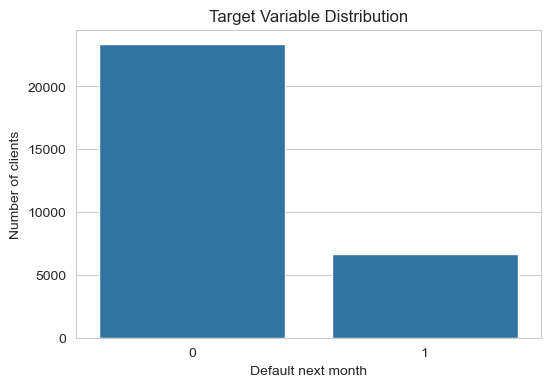

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="default")
plt.title("Target Variable Distribution")
plt.xlabel("Default next month")
plt.ylabel("Number of clients")
plt.show()

In [19]:
target_distribution = (
    df["default"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_distribution

default
0    77.87
1    22.13
Name: proportion, dtype: float64

This is a crucial observation.

If the default class is much smaller than the non-default class, then the dataset is imbalanced.

In such a case, accuracy alone can be misleading.  
A model may achieve high accuracy by mostly predicting the majority class, while failing to identify risky clients.

Therefore, later we will also use:

- recall,
- precision,
- F1-score,
- ROC AUC,
- PR AUC,
- confusion matrix.

## 2.4 Descriptive Statistics

Now we inspect basic descriptive statistics for numerical variables.

This helps us detect:

- different feature scales,
- outliers,
- unusual values,
- skewed distributions.

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29965.0,167442.005006,129760.135222,10000.0,50000.0,140000.0,240000.0,1000000.0
SEX,29965.0,1.603738,0.489128,1.0,1.0,2.0,2.0,2.0
EDUCATION,29965.0,1.853629,0.790411,0.0,1.0,2.0,2.0,6.0
MARRIAGE,29965.0,1.551877,0.521997,0.0,1.0,2.0,2.0,3.0
AGE,29965.0,35.487969,9.219459,21.0,28.0,34.0,41.0,79.0
PAY_0,29965.0,-0.016753,1.123492,-2.0,-1.0,0.0,0.0,8.0
PAY_2,29965.0,-0.131854,1.196322,-2.0,-1.0,0.0,0.0,8.0
PAY_3,29965.0,-0.164392,1.195878,-2.0,-1.0,0.0,0.0,8.0
PAY_4,29965.0,-0.218922,1.168175,-2.0,-1.0,0.0,0.0,8.0
PAY_5,29965.0,-0.264509,1.132220,-2.0,-1.0,0.0,0.0,8.0


### Credit Limit Distribution

The `LIMIT_BAL` variable shows substantial variability:

- minimum: 10,000,
- maximum: 1,000,000,
- median: 140,000.

The standard deviation is also very large.

This suggests that clients in the dataset represent very different financial profiles — from relatively small credit users to very high-limit customers.

It also immediately explains why feature scaling will later matter for:

- KNN,
- SVM,
- regularized models.

Without scaling, large financial variables may dominate distance calculations.

### Repayment Status Variables (`PAY_*`)

The repayment status variables (`PAY_0` to `PAY_6`) are especially interesting.

Most medians are equal to `0`, which means that the majority of clients are not severely delayed.

However, the maximum values reach `8`, indicating serious repayment delays for some customers.

Negative values also appear:

- `-1`,
- `-2`.

These correspond to special repayment states such as paying duly or no consumption.

From a business perspective, repayment history is likely to become one of the strongest predictors of default risk.

This is already intuitive:

> past repayment problems often predict future repayment problems.

Later, when we inspect feature importance and coefficients, we will verify whether the models learn this relationship.

### Bill Amount Variables (`BILL_AMT*`)

The bill amount variables have extremely wide ranges:

- some values are strongly negative,
- others exceed hundreds of thousands.

The negative values may initially look suspicious, but in financial systems they can occur because of:

- refunds,
- overpayments,
- accounting adjustments.

The distributions are clearly heavy-tailed and likely skewed.

This suggests that:

- outliers are present,
- means may be influenced by extreme observations,
- robust preprocessing or transformations could potentially help.


### Payment Amount Variables (`PAY_AMT*`)

The payment amount variables also show strong skewness and extreme values.

An important observation:

- the minimum payment values are often `0`,
- many clients may not have made payments in certain months,
- while some clients made extremely large payments.

This variability may later create useful signals for feature engineering.

For example:

- total payments,
- payment-to-bill ratios,
- average repayment behavior.

### Early Modeling Intuition

Even before building models, we can already formulate some hypotheses:

Clients may be more likely to default if they:

- have recent repayment delays,
- accumulate large unpaid bills,
- pay relatively small amounts compared to their debt,
- consistently delay payments across months.

This is an important part of real machine learning workflows:

> EDA is not only about plotting charts — it is also about forming hypotheses that models may later confirm or reject.

In [21]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_features

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default']

In [22]:
# Remove target from feature list
numeric_features_no_target = [col for col in numeric_features if col != "default"]

## 2.5 Understanding Key Feature Groups

The dataset contains several meaningful groups of variables:

- demographic variables,
- credit limit,
- repayment status history,
- bill statement amounts,
- previous payment amounts.

Understanding these groups helps us interpret the models later.

In [23]:
demographic_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
payment_status_features = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_amount_features = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
payment_amount_features = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

In [24]:
df[demographic_features].head()

,SEX,EDUCATION,MARRIAGE,AGE
0,2,2,1,24
1,2,2,2,26
2,2,2,2,34
3,2,2,1,37
4,1,2,1,57


## 2.6 Distribution of Credit Limit

`LIMIT_BAL` describes the amount of given credit.

This is one of the most important financial variables in the dataset.

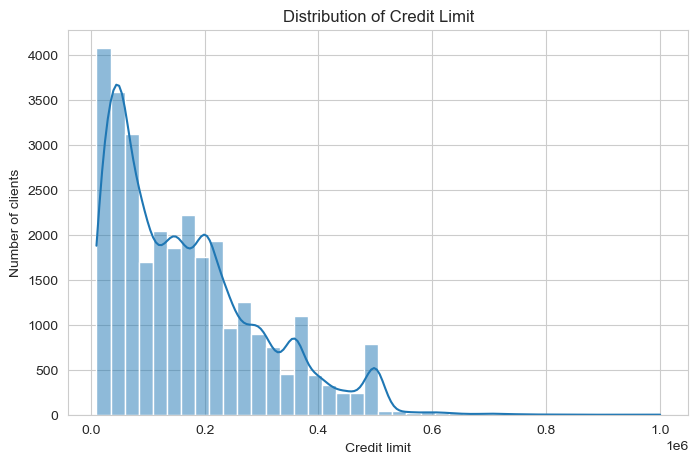

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(df["LIMIT_BAL"], bins=40, kde=True)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit limit")
plt.ylabel("Number of clients")
plt.show()

The distribution of `LIMIT_BAL` is strongly right-skewed.

Most clients have relatively low or moderate credit limits, while a much smaller number of clients have extremely large limits.

This creates a long right tail in the distribution.

From a business perspective, this makes sense.

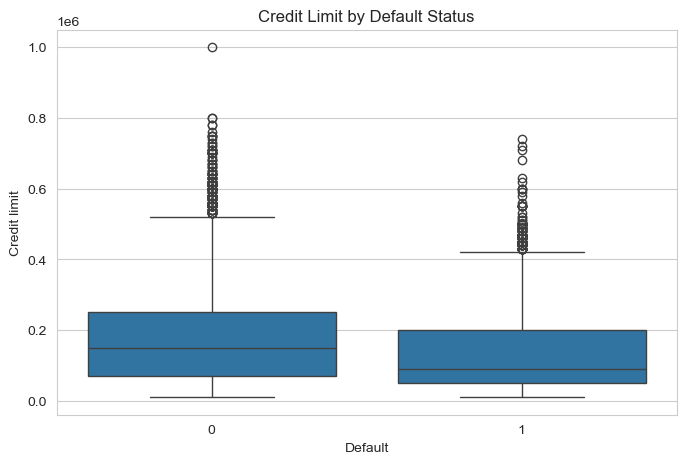

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="default", y="LIMIT_BAL")
plt.title("Credit Limit by Default Status")
plt.xlabel("Default")
plt.ylabel("Credit limit")
plt.show()

Several important patterns emerge.

First, the median credit limit appears lower for clients who defaulted.

This suggests that lower-credit clients may generally be riskier.

However, the relationship is clearly not deterministic.

We still observe many non-defaulting clients with low limits and some defaulting clients with relatively high limits.

This is a very important machine learning lesson:

> real-world classification problems rarely contain perfectly separable classes.

Instead, the model must learn probabilistic patterns.

### Large Overlap Between Classes

The two boxplots overlap substantially.

This means that `LIMIT_BAL` alone is not sufficient to predict default accurately.

If there were almost no overlap, the problem would be easy:

- small limit → default,
- large limit → no default.

But the overlap shows that default risk depends on multiple interacting factors:

- repayment history,
- debt accumulation,
- payment behavior,
- demographic variables,
- and possibly nonlinear relationships.

This observation already motivates why we need machine learning models rather than simple rule-based thresholds.

### Presence of Outliers

Both groups contain many extreme observations.

Some clients have very large credit limits reaching hundreds of thousands or even one million.

These outliers are important because:

- they may influence linear models,
- they may distort distance calculations in KNN,
- they may affect optimization in SVM,
- they increase the importance of scaling and regularization.

Later, we will see that preprocessing decisions become especially important for geometry-based models.

### Business Interpretation

From a banking perspective, higher credit limits are usually granted to clients considered more financially reliable.

That may partially explain why the non-default group tends to have somewhat higher limits.

However, high credit limits also imply larger potential losses when default occurs.

This means that:

> even rare defaults among high-limit clients may be financially very costly.

This is another reason why recall can become critically important in credit risk modeling.

This plot helps us compare credit limits between clients who defaulted and clients who did not.

If the distributions differ, `LIMIT_BAL` may contain predictive information.

## 2.7 Age Distribution

Age may be related to income stability, credit history, and repayment behavior.

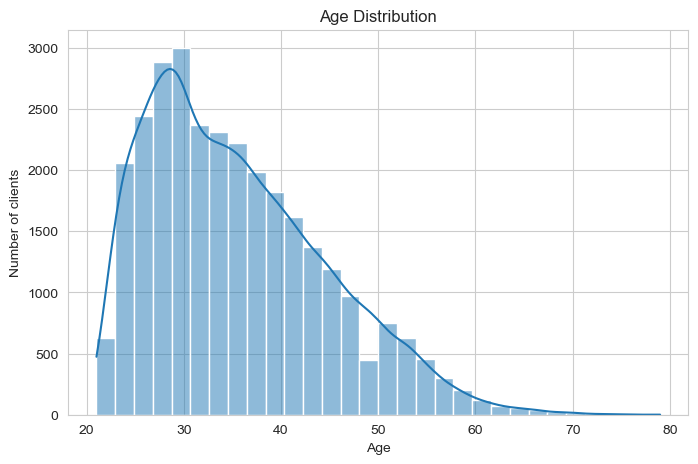

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df["AGE"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of clients")
plt.show()

### Age Distribution

The age distribution is concentrated mostly between approximately 25 and 45 years old.

The distribution is moderately right-skewed:

- younger and middle-aged clients dominate the dataset,
- older clients appear less frequently,
- very young and very old clients are relatively rare.

This pattern is realistic for credit card portfolios because the most active credit users are usually working-age adults.

### Peak Around Early Adulthood

The highest density appears around the late twenties and early thirties.

This may reflect a client segment that:

- actively uses credit products,
- is building financial independence,
- may still have relatively unstable financial situations compared to older clients.

From a business perspective, younger clients may sometimes carry higher credit risk because of:

- lower financial reserves,
- shorter credit history,
- less stable income patterns.

However, age alone is rarely sufficient for accurate prediction.

### Long Right Tail

The distribution gradually decreases for older ages and extends toward approximately 80 years old.

This creates another example of a non-symmetric distribution.

Compared to the financial variables, however, the skewness here is much milder.

This means that age probably will not create the same scaling problems as variables like:

- `LIMIT_BAL`,
- `BILL_AMT*`,
- `PAY_AMT*`.

Still, because KNN and SVM are sensitive to feature scale, age will later also be standardized together with other variables.

### Potential Nonlinear Relationships

An important observation is that age may influence default risk nonlinearly.

For example:

- very young clients may be risky because of unstable finances,
- middle-aged clients may be more stable,
- older clients may behave differently again.

A simple linear model may struggle to capture such patterns perfectly.

This is one reason why later sections on:

- feature engineering,
- polynomial features,
- SVM kernels,

become important.

### Connecting to Earlier Observations

Earlier, we observed that repayment behavior variables likely contain strong predictive signals.

Age is probably a weaker standalone predictor than repayment history.

However, machine learning models often benefit from combining:

- demographic information,
- financial exposure,
- historical repayment behavior.

The predictive power usually comes not from one variable alone, but from interactions between many variables.

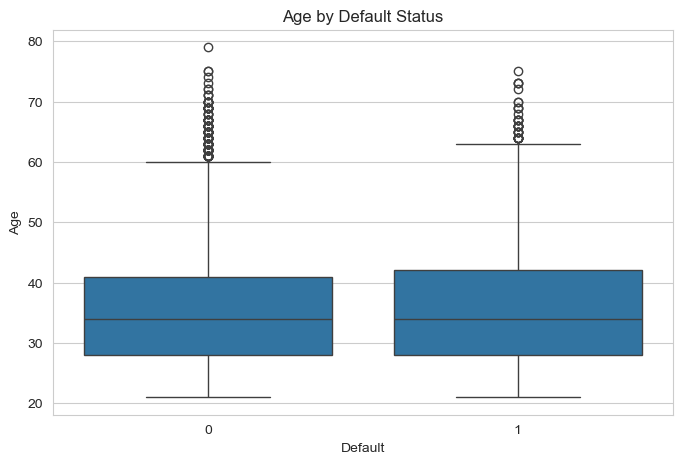

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="default", y="AGE")
plt.title("Age by Default Status")
plt.xlabel("Default")
plt.ylabel("Age")
plt.show()

### Age vs Default Status

Now we compare the age distributions between:

- clients who did not default,
- clients who defaulted.

At first glance, the two groups look surprisingly similar.

The medians are close, and the interquartile ranges overlap strongly.

This suggests that age alone is probably not a very strong predictor of default risk.

### Slight Shift Toward Older Clients in the Default Group

Although the overlap is large, the default group appears slightly older on average.

The median age for defaulting clients is somewhat higher.

This is an interesting observation because it challenges a simplistic intuition that younger clients are always riskier.

In reality, credit risk is usually influenced more by:

- repayment behavior,
- debt management,
- financial discipline,

than by age itself.

Age may still matter indirectly, but probably not as a dominant standalone variable.

### Strong Class Overlap

The heavy overlap between the two boxplots is important from a machine learning perspective.

It means there is no simple threshold such as:

- age > X → default,
- age < X → no default.

This reinforces an idea we already observed earlier with credit limits:

> the classes are not cleanly separable using single variables.

As a result, the predictive power must emerge from combining many variables simultaneously.

This is exactly the kind of problem where machine learning becomes valuable.

### Outliers and Long Tails

Both groups contain older outlier clients reaching ages above 70.

However, these observations are relatively rare.

Compared to financial variables, the age variable appears much more stable and less extreme.

This means that age is unlikely to dominate model behavior the way large financial variables might.

### Connecting to Previous Findings

Earlier, repayment status variables already appeared potentially very informative.

Compared to those variables, age likely provides weaker direct predictive power.

However, weaker variables are not useless.

Machine learning models often improve when combining:

- strong behavioral predictors,
- demographic context,
- financial exposure.

A variable that is weak individually may still contribute useful information when interacting with other variables.

This idea will later become especially important during:

- feature engineering,
- regularization,
- nonlinear modeling,
- and hyperparameter tuning.


## 2.8 Categorical Variables

Now we analyze categorical variables such as sex, education, and marital status.

These variables may capture important demographic patterns.

In [29]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


SEX
SEX
1    11874
2    18091
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64


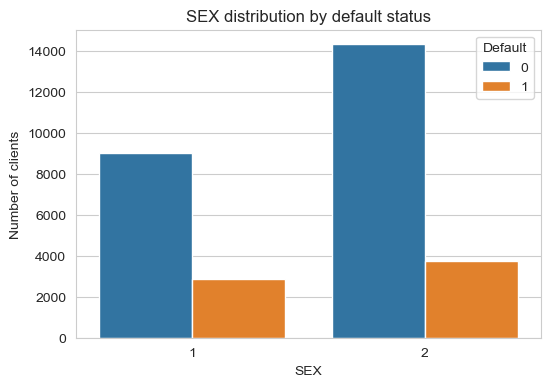

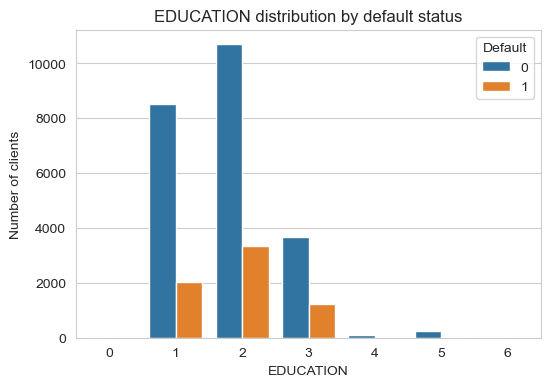

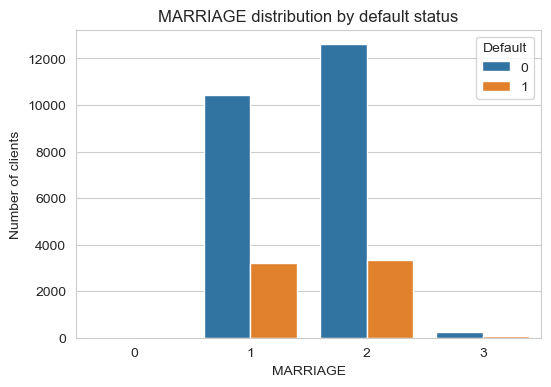

In [30]:
for col in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue="default")
    plt.title(f"{col} distribution by default status")
    plt.xlabel(col)
    plt.ylabel("Number of clients")
    plt.legend(title="Default")
    plt.show()

### SEX vs Default

The dataset contains more clients with `SEX = 2` than with `SEX = 1`.

Even though the absolute number of defaults is higher for `SEX = 2`, this does not automatically mean that this group is riskier.

Why?

Because the group itself is larger.

This is an important lesson in exploratory analysis:

> absolute counts can be misleading when group sizes differ.

What matters more is the proportion of defaults within each category.

Visually, the default share appears somewhat higher for `SEX = 1`, although the difference is not dramatic.

This suggests that sex may contain some predictive information, but probably not a dominant signal compared to repayment history variables.

### EDUCATION vs Default

The education variable shows a much richer structure.

Most clients belong to education categories:

- `1`,
- `2`,
- `3`.

Some categories contain very few observations, such as:

- `0`,
- `4`,
- `5`,
- `6`.

Small categories are important because machine learning models may struggle to learn stable patterns from very limited data.

This may later motivate:

- grouping rare categories,
- regularization,
- or careful interpretation of coefficients.

### Possible Relationship With Risk

The default distribution appears different across education groups.

Some education categories seem to contain proportionally more defaulters than others.

This may reflect broader socioeconomic patterns:

- income stability,
- financial literacy,
- employment opportunities,
- debt management behavior.

However, we should be careful not to overinterpret these patterns causally.

Machine learning models learn statistical relationships, not causal explanations.

### Important Modeling Consideration

Although `EDUCATION` is encoded numerically, it is fundamentally categorical.

This creates an interesting modeling question:

Should the model interpret:


### Business Interpretation

Demographic variables often provide weaker predictive power than behavioral variables.

Banks are usually much more interested in:

- how clients repay debt,
- whether delays accumulate,
- how large unpaid balances become,

than in demographic characteristics alone.

Still, demographic variables may contribute additional context when combined with financial behavior variables.

At this stage, we are not yet building a model.

We are trying to understand whether some groups of clients have visibly different default rates.

In [31]:
for col in categorical_features:
    default_rate_by_group = (
        df.groupby(col)["default"]
        .mean()
        .sort_values(ascending=False)
        .to_frame("default_rate")
    )
    
    display(default_rate_by_group)

,default_rate
SEX,
1,0.241620
2,0.207893


,default_rate
EDUCATION,
3,0.251679
2,0.237392
1,0.192370
6,0.156863
5,0.064286
4,0.056911
0,0.000000


,default_rate
MARRIAGE,
3,0.260062
1,0.234626
2,0.209470
0,0.092593


### Default Rate by Category

The previous countplots showed the absolute number of defaults in each category.

Now we calculate something more informative:

> the actual default rate inside each group.

This allows us to compare groups fairly, even when their sizes differ substantially.

### SEX and Default Rate

The default rate is slightly higher for:

- `SEX = 1` (~24%),
- compared to `SEX = 2` (~21%).

This confirms the visual intuition from the countplot.

However, the difference is relatively modest.

This suggests that sex alone is unlikely to be a strong standalone predictor.

Instead, it may contribute only a small amount of additional information when combined with stronger behavioral variables.

### EDUCATION and Default Rate

The education variable shows more noticeable variation.

The highest default rates appear for:

- `EDUCATION = 3`,
- followed by `EDUCATION = 2`.

Meanwhile, categories such as:

- `4`,
- `5`,
- `6`

show much lower default rates.

However, we must be careful with interpretation because some of these categories contain very few observations.

This introduces an important statistical idea:

> small groups may produce unstable estimates.

For example, a category with very few clients may appear extremely risky or extremely safe simply because of limited sample size.

In real production systems, analysts often:

- merge rare categories,
- remove unreliable categories,
- or apply regularization to stabilize estimates.

### MARRIAGE and Default Rate

For marriage status, category `3` has the highest default rate.

However, this category is relatively small.

The two dominant categories are:

- `1`,
- `2`.

Their default rates are closer to each other, although category `1` appears somewhat riskier.

Again, the differences exist, but they are not large enough to perfectly separate classes.

## 2.9 Default Rate by Repayment Status

Repayment status variables are likely to be among the strongest predictors.

They describe whether a client paid on time or had delays in previous months.

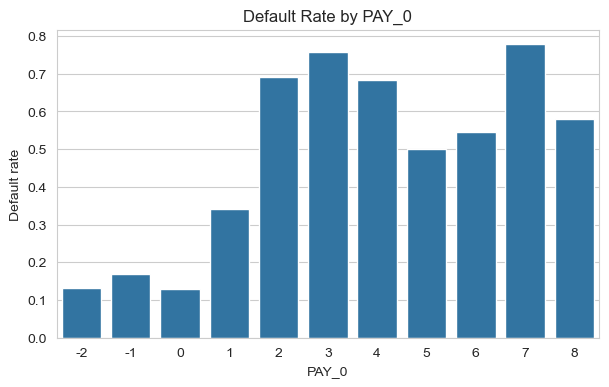

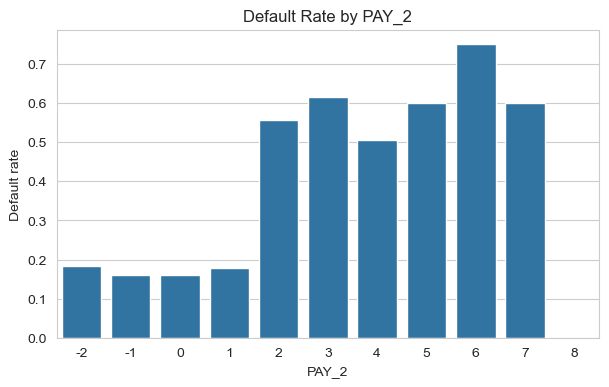

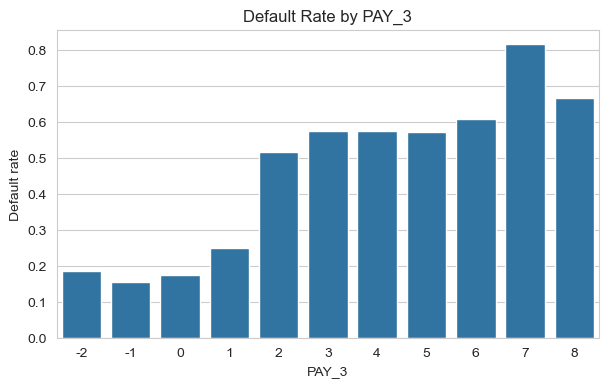

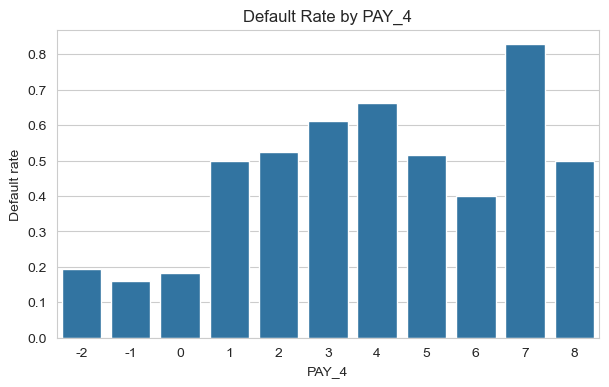

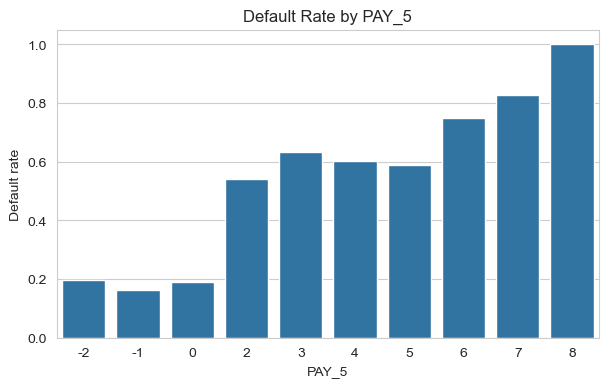

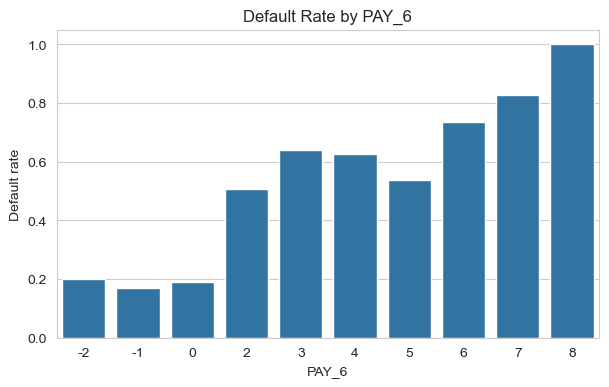

In [32]:
for col in payment_status_features:
    default_rate = (
        df.groupby(col)["default"]
        .mean()
        .to_frame("default_rate")
        .reset_index()
    )
    
    plt.figure(figsize=(7, 4))
    sns.barplot(data=default_rate, x=col, y="default_rate")
    plt.title(f"Default Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Default rate")
    plt.show()

These plots are useful because they connect directly to business intuition.

Clients with delayed payments in previous months should usually have a higher probability of future default.

## 2.10 Bill Amounts and Payment Amounts

Next, we compare bill amounts and payment amounts.

These variables may show whether clients are accumulating debt or actively repaying it.

In [33]:
df[bill_amount_features].describe().T

,count,mean,std,min,25%,50%,75%,max
BILL_AMT1,29965.0,51283.009778,73658.132403,-165580.0,3595.0,22438.0,67260.0,964511.0
BILL_AMT2,29965.0,49236.366294,71195.567392,-69777.0,3010.0,21295.0,64109.0,983931.0
BILL_AMT3,29965.0,47067.916069,69371.352323,-157264.0,2711.0,20135.0,60201.0,1664089.0
BILL_AMT4,29965.0,43313.329885,64353.514373,-170000.0,2360.0,19081.0,54601.0,891586.0
BILL_AMT5,29965.0,40358.334390,60817.130623,-81334.0,1787.0,18130.0,50247.0,927171.0
BILL_AMT6,29965.0,38917.012281,59574.147742,-339603.0,1262.0,17124.0,49252.0,961664.0


In [34]:
df[payment_amount_features].describe().T

,count,mean,std,min,25%,50%,75%,max
PAY_AMT1,29965.0,5670.099316,16571.849467,0.0,1000.0,2102.0,5008.0,873552.0
PAY_AMT2,29965.0,5927.983180,23053.456645,0.0,850.0,2010.0,5000.0,1684259.0
PAY_AMT3,29965.0,5231.688837,17616.361124,0.0,390.0,1804.0,4512.0,896040.0
PAY_AMT4,29965.0,4831.617454,15674.464538,0.0,300.0,1500.0,4016.0,621000.0
PAY_AMT5,29965.0,4804.897047,15286.372298,0.0,261.0,1500.0,4042.0,426529.0
PAY_AMT6,29965.0,5221.498014,17786.976864,0.0,131.0,1500.0,4000.0,528666.0


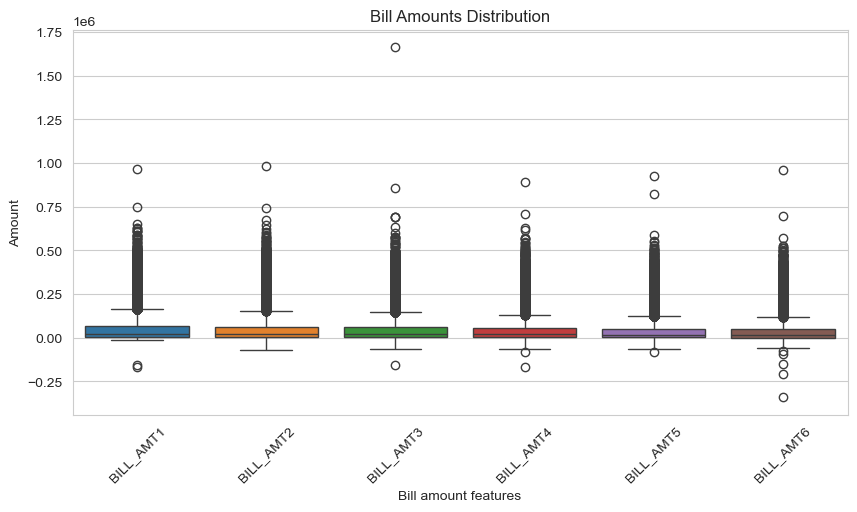

In [35]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[bill_amount_features])
plt.title("Bill Amounts Distribution")
plt.xlabel("Bill amount features")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

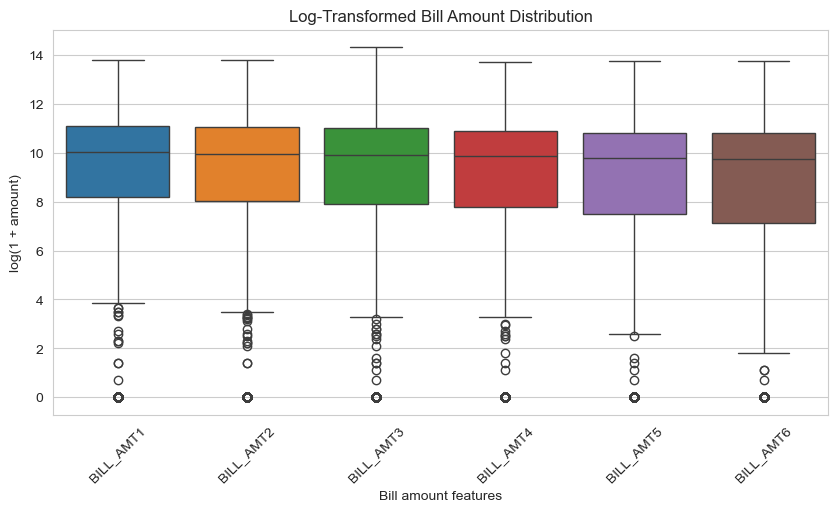

In [318]:
bill_cols = bill_amount_features

bill_log_df = np.log1p(df[bill_cols].clip(lower=0))

plt.figure(figsize=(10, 5))

sns.boxplot(data=bill_log_df)

plt.title("Log-Transformed Bill Amount Distribution")
plt.xlabel("Bill amount features")
plt.ylabel("log(1 + amount)")

plt.xticks(rotation=45)
plt.show()

### Log-Transformed Bill Amount Distribution

After applying the logarithmic transformation, the structure of the bill amount variables becomes much easier to interpret.

The previous raw-scale boxplots were dominated by extreme outliers.  
A relatively small number of clients had exceptionally large bill amounts, which compressed the majority of observations near zero.

This is a classic characteristic of financial data:

- most clients have moderate balances,
- a smaller number accumulate very large debt,
- distributions become heavily right-skewed.

### Why Log Transformation Helps

The transformation:

\[
\log(1+x)
\]

compresses large values while preserving the ordering of observations.

As a result:

- the distributions become visually comparable,
- the central structure becomes visible,
- extreme observations no longer dominate the plot.

This is an important practical lesson:

> preprocessing is not only about improving models — it also improves interpretability.

### Stability Across Months

One striking observation is that the six monthly bill amount distributions look very similar.

This suggests that client financial behavior is relatively stable over time.

Clients with high balances in one month often continue to have high balances in later months.

Similarly, clients with low balances tend to remain in lower ranges.

This temporal consistency is extremely important for credit risk modeling because it means historical billing behavior likely contains predictive information about future repayment outcomes.

### Presence of Outliers Still Matters

Even after log transformation, we still observe lower-end outliers and broad variability.

This tells us that the client population is highly heterogeneous.

Some clients:

- carry very large revolving balances,
- some consistently maintain low balances,
- others fluctuate more strongly.

Such heterogeneity is one reason why machine learning models may outperform simple rule-based systems.

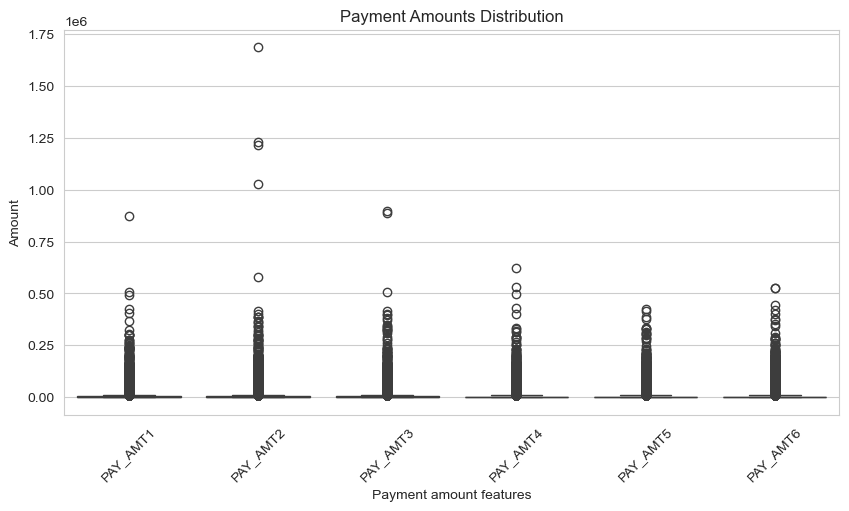

In [36]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[payment_amount_features])
plt.title("Payment Amounts Distribution")
plt.xlabel("Payment amount features")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

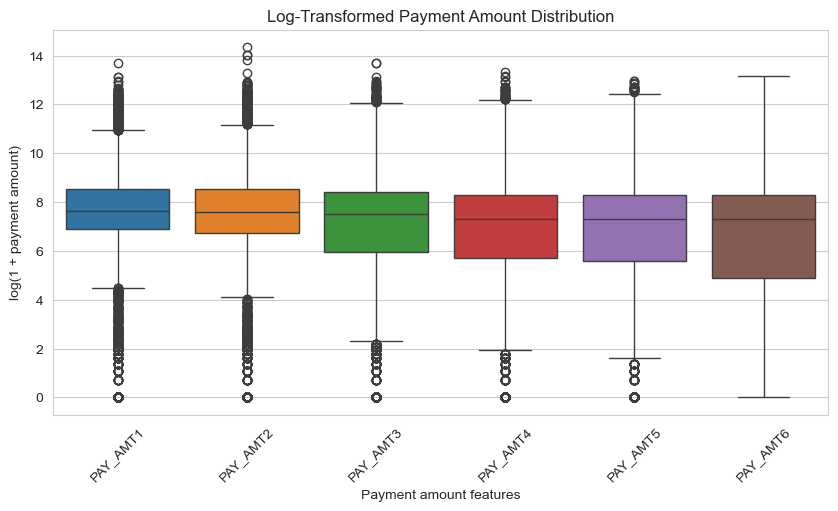

In [319]:
payment_cols = payment_amount_features

payment_log_df = np.log1p(df[payment_cols].clip(lower=0))

plt.figure(figsize=(10, 5))

sns.boxplot(data=payment_log_df)

plt.title("Log-Transformed Payment Amount Distribution")
plt.xlabel("Payment amount features")
plt.ylabel("log(1 + payment amount)")

plt.xticks(rotation=45)
plt.show()

### Large Number of Small Payments

One striking observation is the large concentration of observations near the lower part of the distribution.

This suggests that many clients:

- make relatively small payments,
- occasionally make no payment,
- or pay only a small fraction of their outstanding balance.

From a business perspective, this may indicate different repayment behaviors:

- disciplined full repayment,
- minimum-payment behavior,
- temporary liquidity problems,
- or accumulating debt.

This is potentially very important for predicting default risk.

### Stable Repayment Patterns Across Months

The distributions across months are again remarkably similar.

This suggests that repayment behavior is relatively persistent over time.

Clients who consistently make small payments tend to continue doing so, while clients making larger repayments often maintain similar behavior across multiple billing cycles.

This temporal consistency is valuable because:

> past financial behavior is often one of the strongest predictors of future financial behavior.

This is one reason why repayment-related variables are expected to become highly important during modeling.

### Slight Structural Changes Across Months

Although the monthly distributions are broadly similar, later months appear slightly more spread out.

This may suggest that repayment behavior becomes more heterogeneous over time.

Some clients may:

- gradually accumulate repayment difficulties,
- fluctuate between months,
- or change repayment behavior dynamically.

This hints that trends and aggregated repayment summaries may become useful engineered features later in the notebook.


This is important because:

- KNN is distance-based,
- SVM is sensitive to feature scale,
- logistic regression benefits from standardized inputs.

Therefore, feature scaling will be necessary before modeling.

## 2.11 Correlation Analysis

Correlation analysis helps identify linear relationships between variables.

It can also reveal groups of strongly related variables, for example consecutive bill amounts.

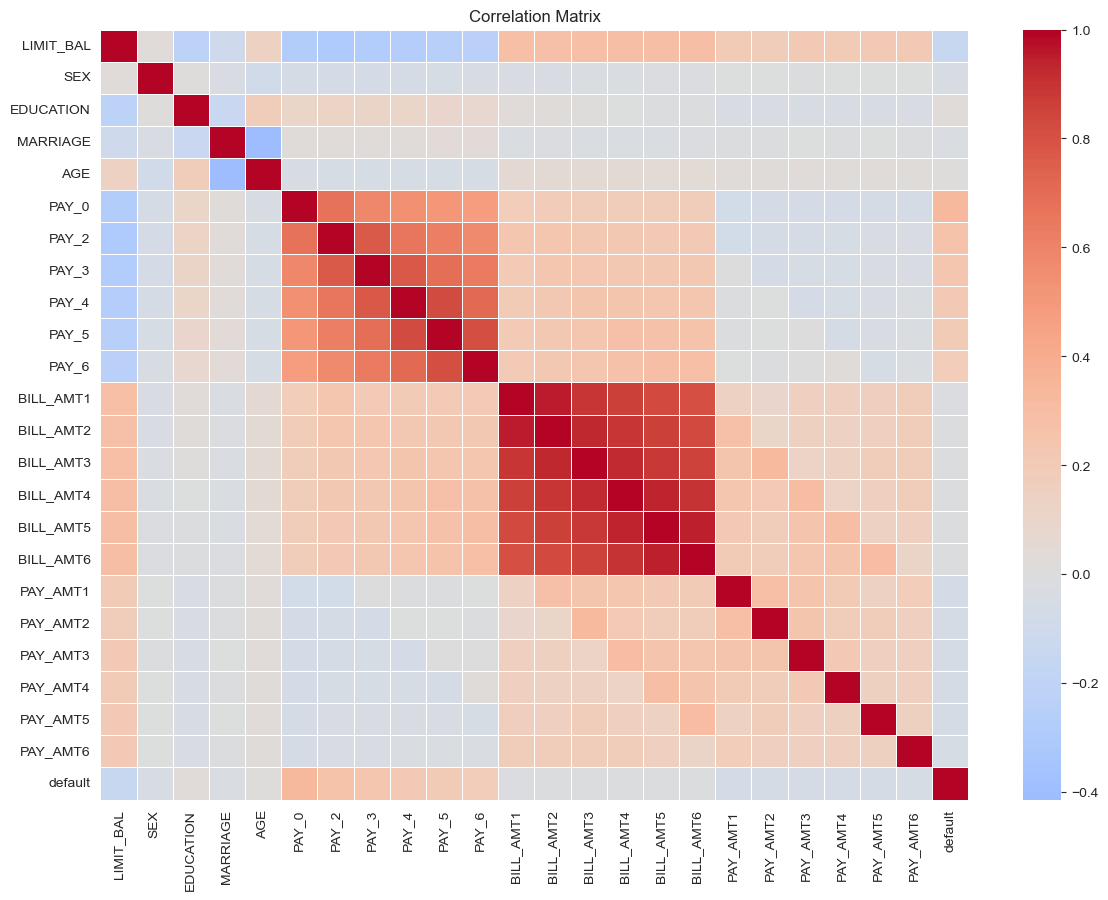

In [37]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

In [38]:
target_corr = (
    corr_matrix["default"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_default")
)

target_corr

,correlation_with_default
default,1.000000
PAY_0,0.324964
PAY_2,0.263656
PAY_3,0.235230
PAY_4,0.216551
PAY_5,0.204059
PAY_6,0.186740
EDUCATION,0.028017
AGE,0.013619
BILL_AMT6,-0.005469


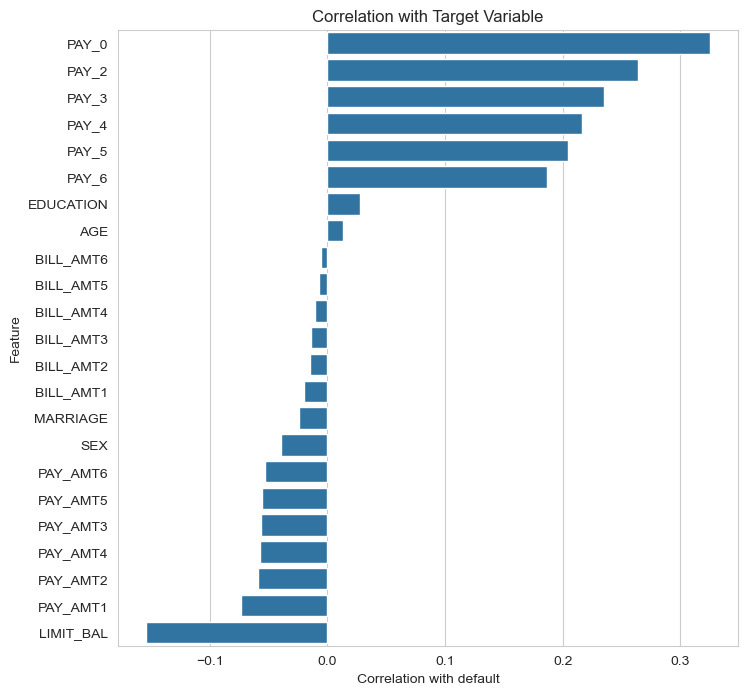

In [39]:
plt.figure(figsize=(8, 8))
sns.barplot(
    data=target_corr.drop(index="default").reset_index(),
    x="correlation_with_default",
    y="index"
)
plt.title("Correlation with Target Variable")
plt.xlabel("Correlation with default")
plt.ylabel("Feature")
plt.show()

Correlation with the target gives a first approximation of predictive power.

However, low correlation does not necessarily mean that a variable is useless.  
Some variables may have nonlinear effects or interactions with other variables.

## 2.12 Feature Scale Comparison

Many machine learning algorithms are sensitive to the scale of input variables.

This is especially important for:

- KNN,
- SVM,
- regularized logistic regression.

Let us compare the ranges of selected variables.

In [40]:
feature_ranges = pd.DataFrame({
    "min": df[numeric_features_no_target].min(),
    "max": df[numeric_features_no_target].max(),
    "mean": df[numeric_features_no_target].mean(),
    "std": df[numeric_features_no_target].std()
})

feature_ranges["range"] = feature_ranges["max"] - feature_ranges["min"]

feature_ranges.sort_values("range", ascending=False)

,min,max,mean,std,range
BILL_AMT3,-157264,1664089,47067.916069,69371.352323,1821353
PAY_AMT2,0,1684259,5927.983180,23053.456645,1684259
BILL_AMT6,-339603,961664,38917.012281,59574.147742,1301267
BILL_AMT1,-165580,964511,51283.009778,73658.132403,1130091
BILL_AMT4,-170000,891586,43313.329885,64353.514373,1061586
BILL_AMT2,-69777,983931,49236.366294,71195.567392,1053708
BILL_AMT5,-81334,927171,40358.334390,60817.130623,1008505
LIMIT_BAL,10000,1000000,167442.005006,129760.135222,990000
PAY_AMT3,0,896040,5231.688837,17616.361124,896040
PAY_AMT1,0,873552,5670.099316,16571.849467,873552


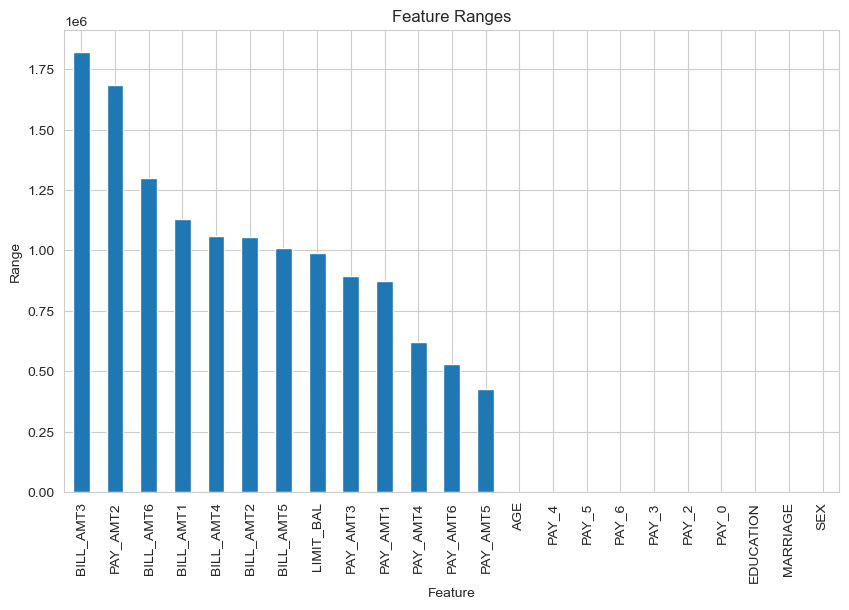

In [41]:
plt.figure(figsize=(10, 6))
feature_ranges["range"].sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Ranges")
plt.xlabel("Feature")
plt.ylabel("Range")
plt.xticks(rotation=90)
plt.show()

The feature ranges differ substantially.

This means that distance-based models may be dominated by variables with large numerical ranges.

For this reason, we will later compare models:

- without scaling,
- with scaling.

## 2.13 Simple Feature Engineering Preview

Before formal feature engineering, we can create a few intuitive business variables.

For example:

- total bill amount,
- total payment amount,
- payment-to-bill ratio.

These variables may better summarize repayment behavior than individual monthly values.

In [42]:
df_eda = df.copy()

df_eda["TOTAL_BILL_AMT"] = df_eda[bill_amount_features].sum(axis=1)
df_eda["TOTAL_PAY_AMT"] = df_eda[payment_amount_features].sum(axis=1)

df_eda["PAYMENT_TO_BILL_RATIO"] = (
    df_eda["TOTAL_PAY_AMT"] / (df_eda["TOTAL_BILL_AMT"] + 1)
)

In [43]:
df_eda[["TOTAL_BILL_AMT", "TOTAL_PAY_AMT", "PAYMENT_TO_BILL_RATIO", "default"]].head()

,TOTAL_BILL_AMT,TOTAL_PAY_AMT,PAYMENT_TO_BILL_RATIO,default
0,7704,689,0.089422,1
1,17077,5000,0.292774,1
2,101653,11018,0.108387,0
3,231334,8388,0.036259,0
4,109339,59049,0.540049,0


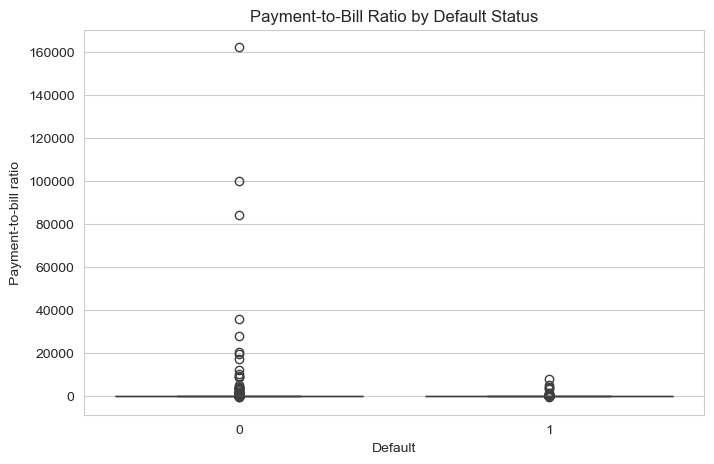

In [44]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="default", y="PAYMENT_TO_BILL_RATIO")
plt.title("Payment-to-Bill Ratio by Default Status")
plt.xlabel("Default")
plt.ylabel("Payment-to-bill ratio")
plt.show()

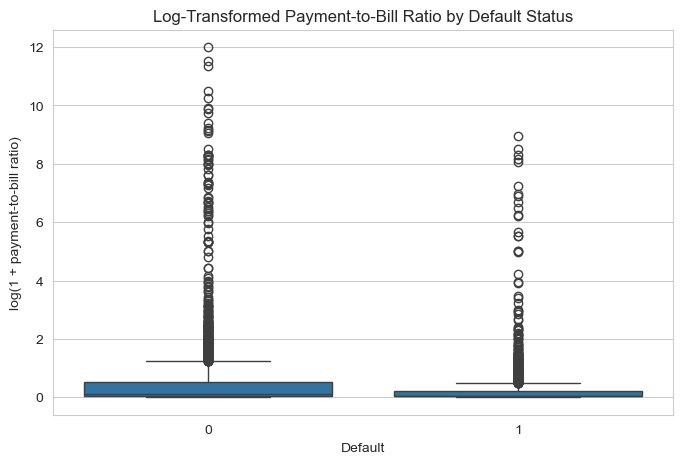

In [322]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_eda,
    x="default",
    y=np.log1p(df_eda["PAYMENT_TO_BILL_RATIO"].clip(lower=0))
)

plt.title("Log-Transformed Payment-to-Bill Ratio by Default Status")
plt.xlabel("Default")
plt.ylabel("log(1 + payment-to-bill ratio)")

plt.show()

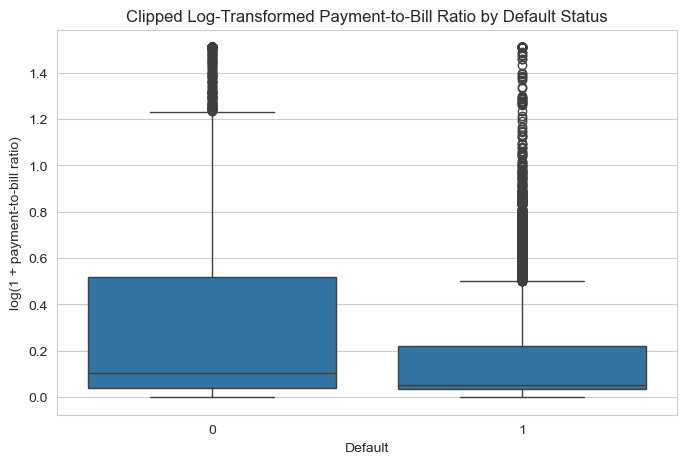

In [325]:
ratio_clipped = df_eda["PAYMENT_TO_BILL_RATIO"].clip(
    lower=0,
    upper=df_eda["PAYMENT_TO_BILL_RATIO"].quantile(0.99)
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df_eda["default"],
    y=np.log1p(ratio_clipped)
)

plt.title("Clipped Log-Transformed Payment-to-Bill Ratio by Default Status")
plt.xlabel("Default")
plt.ylabel("log(1 + payment-to-bill ratio)")

plt.show()

### Clearer Separation Between Groups

Now the relationship between repayment behavior and default risk becomes more visible.

Clients who defaulted generally have:

- lower median payment-to-bill ratios,
- smaller upper quartiles,
- and a more compressed distribution.

This suggests that defaulting clients tend to repay a smaller fraction of their accumulated debt.

In contrast, non-defaulting clients more frequently exhibit higher repayment relative to outstanding balances.

This aligns strongly with business intuition:

> clients who consistently repay a meaningful portion of their debt are generally less risky.

### Still Significant Overlap

Even after cleaning the visualization, the overlap between groups remains substantial.

This is extremely important.

The feature contains useful signal, but it still cannot perfectly separate the classes.

This reinforces a major theme throughout the notebook:

- machine learning models do not rely on one perfect variable,
- instead, they combine many partially informative signals.

The predictive power emerges from patterns across variables rather than deterministic rules.

### Why This Feature Is Interesting

This engineered variable is especially valuable because it combines two different financial dimensions:

- debt accumulation,
- repayment behavior.

Raw bill amounts and payment amounts separately describe only part of the financial picture.

The ratio captures repayment discipline relative to debt burden, which is often more behaviorally meaningful.

This is exactly the type of feature engineering that can improve machine learning performance.

This is only an exploratory feature engineering example.

Later, we will decide which engineered features should be included in the modeling pipeline.

## 2.14 EDA Summary

Main observations from the exploratory analysis:

- The task is a binary classification problem.
- The target variable is likely imbalanced.
- Financial variables have very different scales.
- Some variables contain outliers.
- Repayment history appears strongly related to default risk.
- Accuracy alone will not be sufficient for model evaluation.
- Feature scaling will be important for KNN and SVM.
- Feature engineering may improve predictive performance.

These observations will guide the modeling strategy in the next sections.

# 3. Baseline Model — Logistic Regression

After understanding the data, we start with a simple baseline model.

A baseline model is important because it gives us a reference point.  
More complex models should only be considered useful if they improve over this simple starting point.

We will use **Logistic Regression**, one of the most common models for binary classification.

## 3.1 Why Logistic Regression?

Logistic Regression is a natural first model for this problem because:

- it is simple and fast,
- it works well as a baseline,
- it provides probability estimates,
- it is relatively interpretable,
- it is commonly used in credit risk modeling.

The model estimates the probability that a client will default next month.

For binary classification, Logistic Regression models the probability of class `1`:

\[
P(Y=1|X)=\frac{1}{1+e^{-z}}
\]

where:

\[
z = \beta_0 + \beta_1x_1 + ... + \beta_px_p
\]

## 3.2 Prepare Features and Target

We separate the dataset into:

- `X`: explanatory variables,
- `y`: target variable.

The target distribution confirms that this is not a perfectly balanced classification problem.

Because of this, we will use a stratified train-test split.  
Stratification preserves the class proportions in both training and test sets.

## 3.3 Train-Test Split

We split the data into:

- training set: used to train the model,
- test set: used to evaluate generalization performance.

The test set must not be used during model training.

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (23972, 23)
X_test shape: (5993, 23)


In [50]:
print("Train target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train target distribution:
default
0    0.779
1    0.221
Name: proportion, dtype: float64

Test target distribution:
default
0    0.779
1    0.221
Name: proportion, dtype: float64


## 3.4 Preprocessing for Logistic Regression

Logistic Regression requires numerical input.

In this dataset, all variables are already encoded as numbers.  
However, the variables have very different scales.

Since Logistic Regression is optimized using numerical procedures and may use regularization, scaling the features is recommended.

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [52]:
log_reg_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

Using a pipeline is a good practice.

The scaler is fitted only on the training data and then applied to the test data.  
This prevents data leakage.

## 3.5 Train Baseline Logistic Regression Model

Now we train the baseline model.

In [53]:
log_reg_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


After training, we generate:

- predicted classes,
- predicted probabilities.

In [54]:
y_pred = log_reg_pipeline.predict(X_test)
y_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [55]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [56]:
y_proba[:10]

array([0.22316826, 0.18045917, 0.23000882, 0.22324844, 0.17476755,
       0.12612984, 0.28007478, 0.1641204 , 0.09560419, 0.04099572])

## 3.6 First Evaluation Metrics

We start with standard classification metrics.

However, we should remember that accuracy alone may be misleading in imbalanced classification problems.

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba)
}

baseline_metrics = pd.Series(baseline_metrics).round(4)
baseline_metrics

accuracy     0.8129
precision    0.7253
recall       0.2489
f1           0.3706
roc_auc      0.7158
pr_auc       0.5040
dtype: float64

Each metric answers a different question:

- **Accuracy**: how many predictions were correct overall?
- **Precision**: among clients predicted as default, how many actually defaulted?
- **Recall**: among actual defaulters, how many did we detect?
- **F1-score**: balance between precision and recall.
- **ROC AUC**: ranking quality across thresholds.
- **PR AUC**: especially useful for imbalanced classification.

### First Evaluation Metrics

The baseline Logistic Regression model achieves:

- **Accuracy:** ~81%
- **Precision:** ~73%
- **Recall:** ~25%
- **F1-score:** ~37%
- **ROC AUC:** ~0.72
- **PR AUC:** ~0.50

At first glance, the accuracy looks relatively strong.

An 81% accuracy might initially suggest that the model performs well.

However, this is exactly the moment where we must remember one of the key lessons from earlier sections:

> accuracy can be misleading in imbalanced classification problems.

Because approximately 78% of clients do not default, a naive model predicting mostly “no default” could already achieve relatively high accuracy.

This is why we must inspect several metrics simultaneously.

### Precision vs Recall

The model achieves relatively high precision (~73%).

This means:

> when the model predicts default, it is often correct.

In other words, the model is fairly conservative when labeling clients as risky.

However, recall is much lower (~25%).

This means:

> the model detects only about one quarter of actual defaulters.

So although predicted defaults are often correct, the model still misses many risky clients.

This is a very common pattern in imbalanced classification:

- high precision,
- low recall.

The classifier becomes cautious about predicting the minority class.

### Business Interpretation

From a banking perspective, low recall may be problematic.

False Negatives correspond to:

- risky clients predicted as safe,
- potentially leading to financial losses.

Meanwhile, False Positives correspond to:

- safe clients incorrectly flagged as risky,
- potentially causing unnecessary caution or rejected applications.

The acceptable balance depends on business priorities.

If the bank wants to minimize missed defaulters, recall becomes extremely important.

This insight will later motivate:

- threshold tuning,
- class weighting,
- SMOTE,
- and other imbalance-handling techniques.

### F1-score as a Balance Metric

The F1-score combines precision and recall into a single metric.

The relatively moderate F1-score (~37%) reflects the imbalance between:

- strong precision,
- but weak recall.

This suggests that the model has learned some meaningful signal, but still struggles to identify many risky clients.

### ROC AUC vs PR AUC

The ROC AUC (~0.72) indicates that the model has reasonably good ranking ability overall.

In simple terms:

> the model can often assign higher risk scores to defaulters than to non-defaulters.

However, because the dataset is imbalanced, PR AUC becomes especially important.

The PR AUC (~0.50) focuses specifically on the positive class:

- the defaulters.

This gives a more realistic picture of performance under class imbalance.

This is actually a very strong baseline result.

Why?

Because the model is already demonstrating a realistic business trade-off:

- conservative predictions,
- relatively high precision,
- but insufficient recall.

This creates a natural motivation for the next sections of the notebook:

- threshold tuning,
- KNN and geometry-based methods,
- SVM margins,
- cross-validation,
- regularization,
- and imbalanced learning techniques.

At this point, we already know:

> the problem is not simply “build a classifier.”

The real challenge is:

> how to detect more risky clients without generating too many false alarms.

## 3.7 Classification Report

The classification report gives separate metrics for each class.

In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.73      0.25      0.37      1326

    accuracy                           0.81      5993
   macro avg       0.77      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993



In credit default prediction, class `1` is usually the more important class.

Class `1` represents clients who default.  
If recall for class `1` is low, the model fails to detect many risky clients.

## 3.8 Confusion Matrix

The confusion matrix shows the exact number of correct and incorrect predictions.

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

cm

array([[4542,  125],
       [ 996,  330]])

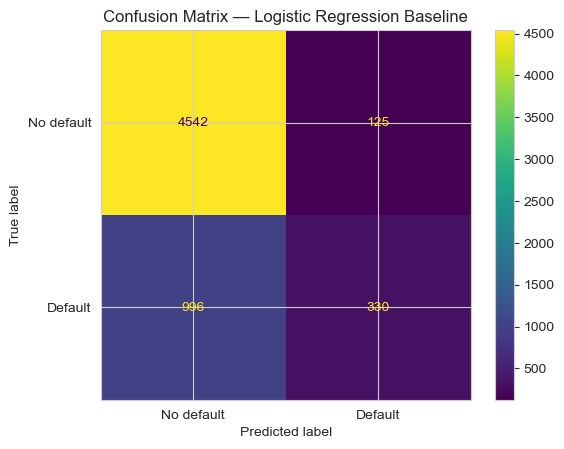

In [60]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression Baseline")
plt.show()

The confusion matrix allows us to identify:

- True Negatives: correctly predicted non-default clients,
- False Positives: clients predicted as default but who did not default,
- False Negatives: clients predicted as safe but who actually defaulted,
- True Positives: correctly detected default clients.

For credit risk, False Negatives are especially important because they represent risky clients that the model failed to identify.

## 3.9 ROC Curve

The ROC curve shows the trade-off between:

- True Positive Rate,
- False Positive Rate,

across different classification thresholds.

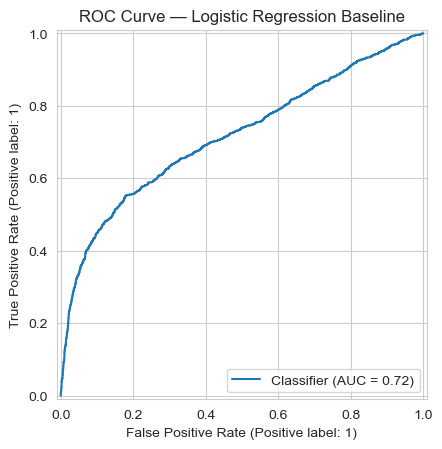

In [61]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Logistic Regression Baseline")
plt.show()

ROC AUC measures how well the model ranks defaulters above non-defaulters.

However, in imbalanced problems, ROC AUC may sometimes be overly optimistic.

## 3.10 Precision-Recall Curve

The Precision-Recall curve is often more informative for imbalanced classification.

It focuses directly on the minority class, which in our case is default.

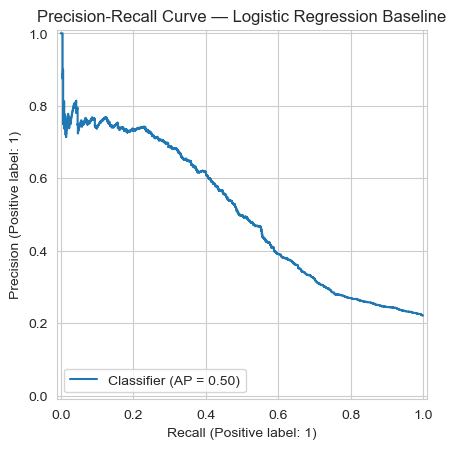

In [62]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall Curve — Logistic Regression Baseline")
plt.show()

### Precision-Recall Curve — Logistic Regression Baseline

The Precision-Recall (PR) curve provides a deeper view of model performance for imbalanced classification problems.

Unlike ROC curves, PR curves focus directly on the positive class:

- in our case, clients who default.

This makes the PR curve especially valuable in credit risk modeling.

### What We Observe Here

At low recall values, precision is relatively high.

This means:

> when the model flags only the most confident risky clients, it is often correct.

However, as recall increases, precision gradually drops.

To detect more defaulters, the model must expand the set of predicted risky clients, which inevitably introduces more false alarms.

This behavior is completely expected in real-world classification systems.

### Average Precision (AP)

The curve reports:

\[
AP \approx 0.50
\]

Average Precision summarizes the overall quality of the precision-recall trade-off across thresholds.

In imbalanced problems, AP is often more informative than accuracy because it focuses specifically on the minority class.

### Business Interpretation

From a business perspective, the PR curve helps answer questions such as:

- How many false alarms are acceptable?
- How many risky clients do we want to detect?
- Should the bank prioritize precision or recall?

Different business objectives lead to different operating points on the curve.

For example:

- a conservative strategy may prioritize high precision,
- a risk-averse strategy may prioritize high recall.

This naturally motivates the next sections of the notebook, where we will study:

- threshold tuning,
- imbalance handling,
- and alternative models such as KNN and SVM.

The key idea is becoming increasingly clear:

> model evaluation is not only about statistical performance — it is about business trade-offs.
The Precision-Recall curve helps us understand the trade-off between:

- detecting more defaulters,
- keeping false alarms under control.

This is directly connected to business decision-making.

## 3.11 Model Coefficients

One advantage of Logistic Regression is interpretability.

We can inspect model coefficients to understand which variables increase or decrease predicted default probability.

In [63]:
log_reg_model = log_reg_pipeline.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg_model.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coefficient
5,PAY_0,0.649294,0.649294
11,BILL_AMT1,-0.452551,0.452551
12,BILL_AMT2,0.267870,0.267870
17,PAY_AMT1,-0.257157,0.257157
18,PAY_AMT2,-0.191068,0.191068
6,PAY_2,0.111036,0.111036
0,LIMIT_BAL,-0.105319,0.105319
2,EDUCATION,-0.094361,0.094361
16,BILL_AMT6,0.090841,0.090841
20,PAY_AMT4,-0.090321,0.090321


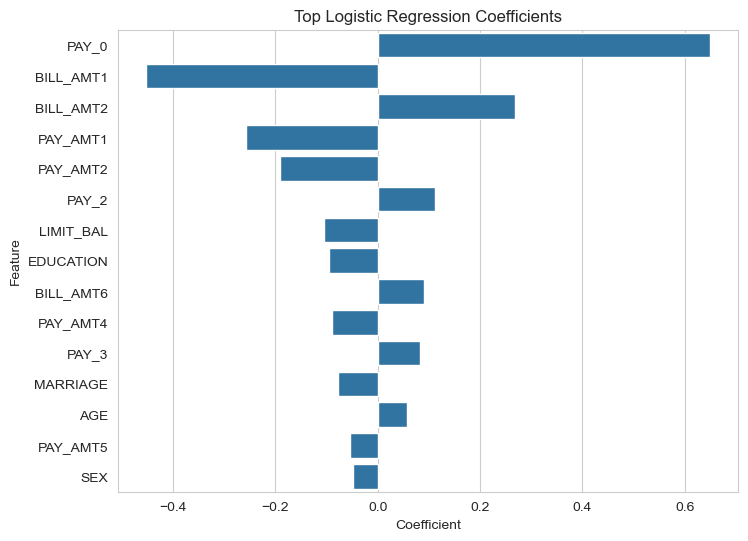

In [64]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=coef_df.head(15),
    x="coefficient",
    y="feature"
)
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Positive coefficients increase the predicted probability of default.

Negative coefficients decrease the predicted probability of default.

Because the features were standardized, coefficient magnitudes are more comparable.

## 3.12 Store Baseline Results

We store baseline results so that we can compare them with KNN, SVM, and other models later.

In [65]:
results = []

results.append({
    "model": "Logistic Regression Baseline",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba)
})

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression Baseline,0.812948,0.725275,0.248869,0.370578,0.715807,0.504034


## 3.13 Baseline Model Summary

The baseline Logistic Regression model gives us the first reference point.

Key observations:

- The model is simple and interpretable.
- It provides probability estimates.
- Accuracy may look acceptable, but recall for defaulters may be limited.
- The default threshold of 0.5 may not be optimal.
- Business costs suggest that we should pay special attention to False Negatives.

In the next section, we will investigate evaluation metrics more deeply and show why threshold selection matters.

# 4. Metrics Deep Dive

In the previous section, we trained a baseline Logistic Regression model.

Now we will focus on model evaluation.

This is one of the most important parts of any classification project because different metrics answer different business questions.

In credit default prediction, we are especially interested in detecting risky clients.  
Therefore, accuracy alone is not enough.

## 4.1 Accuracy Trap

Let us start with a very simple dummy model.

This model always predicts the majority class.

If the dataset is imbalanced, such a model may achieve deceptively high accuracy while being completely useless for detecting defaulters.

In [66]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)
dummy_proba = dummy_model.predict_proba(X_test)[:, 1]

In [67]:
dummy_metrics = {
    "accuracy": accuracy_score(y_test, dummy_pred),
    "precision": precision_score(y_test, dummy_pred, zero_division=0),
    "recall": recall_score(y_test, dummy_pred, zero_division=0),
    "f1": f1_score(y_test, dummy_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, dummy_proba),
    "pr_auc": average_precision_score(y_test, dummy_proba)
}

pd.Series(dummy_metrics).round(4)

accuracy     0.7787
precision    0.0000
recall       0.0000
f1           0.0000
roc_auc      0.5000
pr_auc       0.2213
dtype: float64

The dummy model may have relatively high accuracy because most clients do not default.

However, its recall for default cases is zero.

This means that the model does not identify any risky clients.

In [68]:
print(classification_report(y_test, dummy_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4667
           1       0.00      0.00      0.00      1326

    accuracy                           0.78      5993
   macro avg       0.39      0.50      0.44      5993
weighted avg       0.61      0.78      0.68      5993



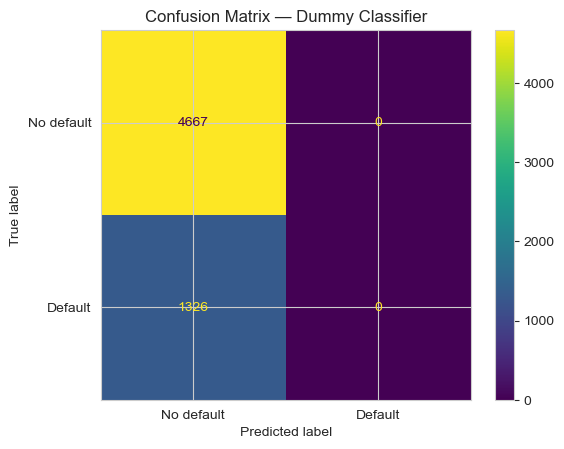

In [69]:
cm_dummy = confusion_matrix(y_test, dummy_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dummy,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Dummy Classifier")
plt.show()

## 4.2 Baseline vs Dummy Model

Now we compare the Logistic Regression baseline with the dummy classifier.

In [70]:
metrics_comparison = pd.DataFrame([
    {
        "model": "Dummy Classifier",
        **dummy_metrics
    },
    {
        "model": "Logistic Regression",
        **baseline_metrics.to_dict()
    }
])

metrics_comparison = metrics_comparison.set_index("model").round(4)

metrics_comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Dummy Classifier,0.7787,0.0000,0.0000,0.0000,0.5000,0.2213
Logistic Regression,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040


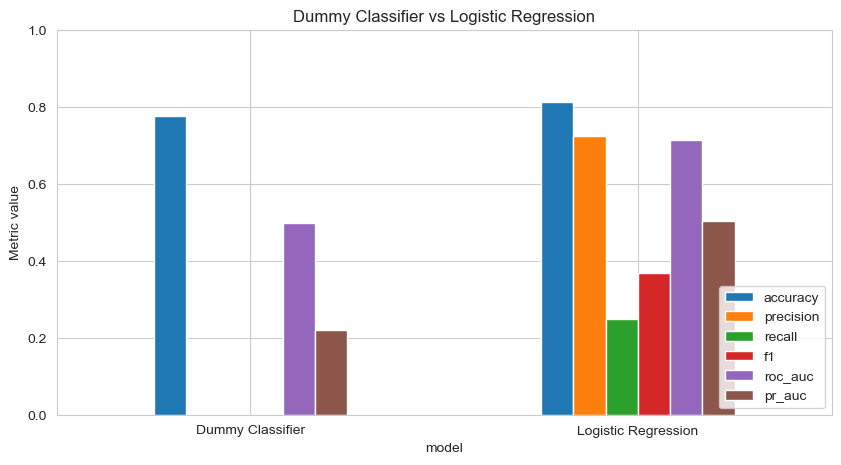

In [71]:
metrics_comparison[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Dummy Classifier vs Logistic Regression")
plt.ylabel("Metric value")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

This comparison shows why a meaningful baseline is necessary.

A model can look acceptable according to accuracy, but still fail completely on the business-critical class.

## 4.3 Confusion Matrix Anatomy

For binary classification, every prediction belongs to one of four groups:

- True Negative: predicted no default and the client did not default,
- False Positive: predicted default but the client did not default,
- False Negative: predicted no default but the client defaulted,
- True Positive: predicted default and the client defaulted.

In credit risk, False Negatives are usually especially costly.

In [72]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 4542
False Positives: 125
False Negatives: 996
True Positives: 330


In [73]:
confusion_df = pd.DataFrame(
    cm,
    index=["Actual: No default", "Actual: Default"],
    columns=["Predicted: No default", "Predicted: Default"]
)

confusion_df

,Predicted: No default,Predicted: Default
Actual: No default,4542,125
Actual: Default,996,330


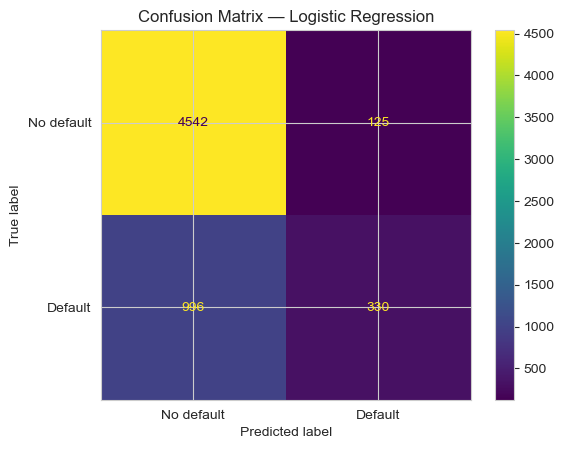

In [74]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

## 4.4 Manual Metric Calculation

To understand the metrics better, we calculate them manually from the confusion matrix.

This helps connect formulas with business interpretation.

In [75]:
manual_accuracy = (tp + tn) / (tp + tn + fp + fn)
manual_precision = tp / (tp + fp)
manual_recall = tp / (tp + fn)
manual_specificity = tn / (tn + fp)
manual_f1 = 2 * manual_precision * manual_recall / (manual_precision + manual_recall)

manual_metrics = pd.Series({
    "accuracy": manual_accuracy,
    "precision": manual_precision,
    "recall": manual_recall,
    "specificity": manual_specificity,
    "f1": manual_f1
})

manual_metrics.round(4)

accuracy       0.8129
precision      0.7253
recall         0.2489
specificity    0.9732
f1             0.3706
dtype: float64

Metric interpretation:

- **Precision** answers: when the model predicts default, how often is it correct?
- **Recall** answers: among all actual defaulters, how many did the model detect?
- **Specificity** answers: among all non-defaulters, how many did the model correctly reject?
- **F1-score** combines precision and recall into one metric.

In credit risk, recall is often very important because missing a risky client may generate financial loss.

## 4.5 Threshold Tuning

By default, classification models usually use threshold `0.5`.

That means:

- if predicted probability >= 0.5, predict default,
- otherwise, predict no default.

However, the threshold does not have to be 0.5.

Changing the threshold changes the business behavior of the model.

In [76]:
threshold = 0.5

custom_pred = (y_proba >= threshold).astype(int)

print(classification_report(y_test, custom_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.73      0.25      0.37      1326

    accuracy                           0.81      5993
   macro avg       0.77      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993



Now we evaluate many possible thresholds and observe how the metrics change.

In [77]:
thresholds = np.arange(0.01, 1.00, 0.01)

threshold_results = []

for threshold in thresholds:
    pred_threshold = (y_proba >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_threshold),
        "precision": precision_score(y_test, pred_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_threshold, zero_division=0),
        "f1": f1_score(y_test, pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.head()

,threshold,accuracy,precision,recall,f1
0,0.01,0.224595,0.221719,0.997738,0.362814
1,0.02,0.230269,0.222710,0.995475,0.363987
2,0.03,0.238278,0.224340,0.993967,0.366060
3,0.04,0.249291,0.226040,0.987179,0.367852
4,0.05,0.268814,0.228789,0.972097,0.370402


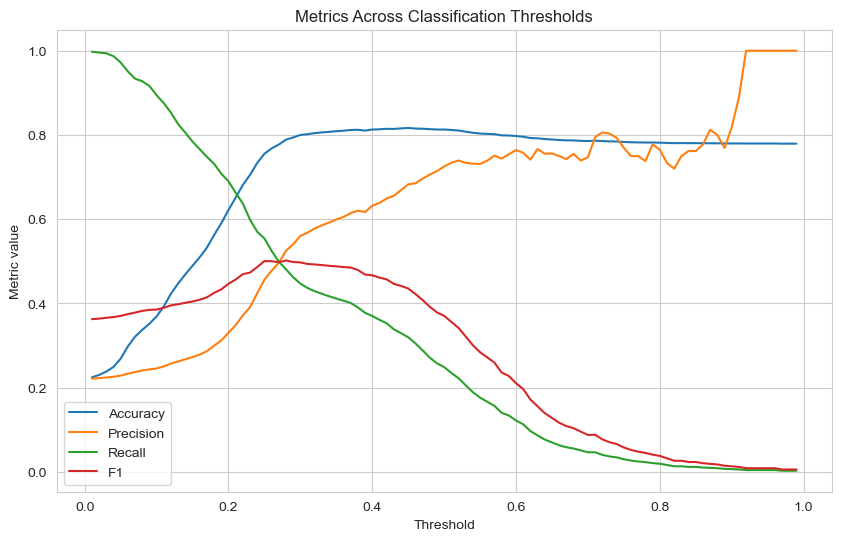

In [78]:
plt.figure(figsize=(10, 6))

plt.plot(threshold_results["threshold"], threshold_results["accuracy"], label="Accuracy")
plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1")

plt.title("Metrics Across Classification Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True)
plt.show()

This plot shows the precision-recall trade-off.

Usually:

- lowering the threshold increases recall,
- lowering the threshold decreases precision,
- increasing the threshold increases precision,
- increasing the threshold decreases recall.

There is no universally optimal threshold.  
The best threshold depends on the business objective.

## 4.6 Selecting Threshold by F1-score

One common strategy is to choose the threshold that maximizes F1-score.

This is useful when we want a balance between precision and recall.

In [79]:
best_f1_row = threshold_results.loc[threshold_results["f1"].idxmax()]

best_f1_row

threshold    0.280000
accuracy     0.788920
precision    0.525103
recall       0.481146
f1           0.502165
Name: 27, dtype: float64

In [80]:
best_f1_threshold = best_f1_row["threshold"]

best_f1_pred = (y_proba >= best_f1_threshold).astype(int)

print("Best F1 threshold:", round(best_f1_threshold, 3))
print(classification_report(y_test, best_f1_pred))

Best F1 threshold: 0.28
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4667
           1       0.53      0.48      0.50      1326

    accuracy                           0.79      5993
   macro avg       0.69      0.68      0.68      5993
weighted avg       0.78      0.79      0.79      5993



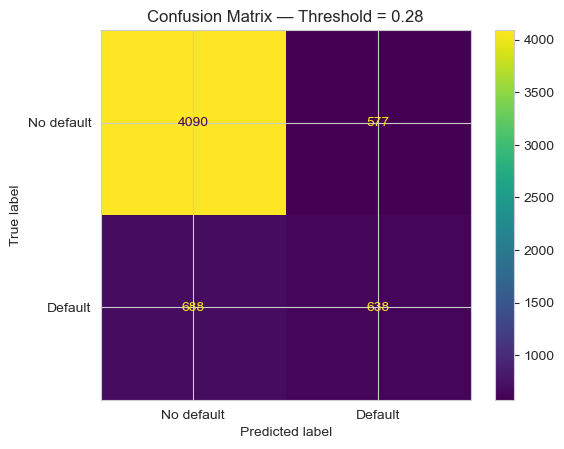

In [81]:
cm_best_f1 = confusion_matrix(y_test, best_f1_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_f1,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix — Threshold = {best_f1_threshold:.2f}")
plt.show()

## 4.7 Selecting Threshold by Business Objective

In credit risk, we may care more about detecting defaulters than maximizing F1-score.

For example, suppose we want to detect at least 70% of actual defaulters.

Then we can search for the threshold that achieves recall >= 0.70 and among those thresholds gives the best precision.

In [82]:
min_recall = 0.70

candidate_thresholds = threshold_results[
    threshold_results["recall"] >= min_recall
]

candidate_thresholds.sort_values("precision", ascending=False).head()

,threshold,accuracy,precision,recall,f1
18,0.19,0.590522,0.312375,0.708145,0.433518
17,0.18,0.562323,0.299660,0.731523,0.425159
16,0.17,0.532621,0.286788,0.748115,0.414629
15,0.16,0.509761,0.278814,0.766214,0.408853
14,0.15,0.489571,0.272751,0.784314,0.404748


In [83]:
if len(candidate_thresholds) > 0:
    business_row = candidate_thresholds.sort_values("precision", ascending=False).iloc[0]
    business_threshold = business_row["threshold"]

    business_pred = (y_proba >= business_threshold).astype(int)

    print("Selected threshold:", round(business_threshold, 3))
    print(classification_report(y_test, business_pred))
else:
    print("No threshold satisfies the minimum recall requirement.")

Selected threshold: 0.19
              precision    recall  f1-score   support

           0       0.87      0.56      0.68      4667
           1       0.31      0.71      0.43      1326

    accuracy                           0.59      5993
   macro avg       0.59      0.63      0.56      5993
weighted avg       0.75      0.59      0.62      5993



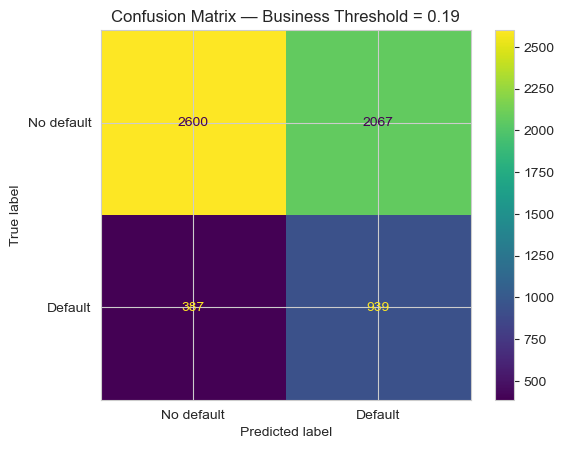

In [84]:
if len(candidate_thresholds) > 0:
    cm_business = confusion_matrix(y_test, business_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_business,
        display_labels=["No default", "Default"]
    )

    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — Business Threshold = {business_threshold:.2f}")
    plt.show()

This approach is more business-oriented.

Instead of blindly accepting threshold 0.5, we define a desired behavior and select the threshold accordingly.

## 4.8 ROC Curve and ROC AUC

The ROC curve shows how recall changes relative to the false positive rate across all thresholds.

ROC AUC measures the model's ranking ability.

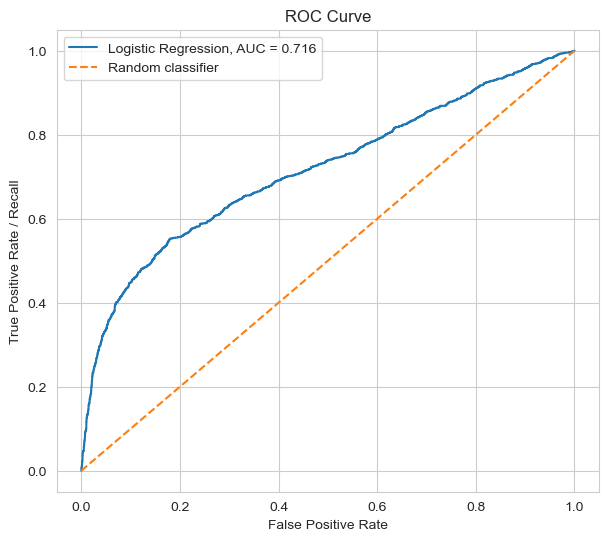

In [86]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression, AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.grid(True)
plt.show()

ROC AUC can be interpreted as the probability that a randomly selected defaulter receives a higher risk score than a randomly selected non-defaulter.

However, ROC AUC may look optimistic when the positive class is rare.

## 4.9 Precision-Recall Curve and PR AUC

The Precision-Recall curve focuses on the positive class.

For imbalanced classification problems, it is often more informative than the ROC curve.

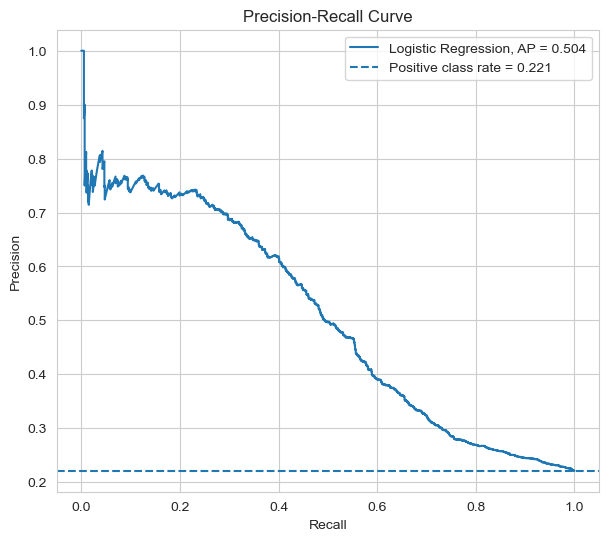

In [87]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"Logistic Regression, AP = {pr_auc:.3f}")

baseline_positive_rate = y_test.mean()
plt.axhline(
    y=baseline_positive_rate,
    linestyle="--",
    label=f"Positive class rate = {baseline_positive_rate:.3f}"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

The horizontal dashed line represents the default rate in the test set.

A useful model should perform meaningfully above this baseline.

## 4.10 Probability Distribution by True Class

A good classifier should assign higher probabilities to actual defaulters than to non-defaulters.

Let us visualize predicted probabilities separately for both classes.

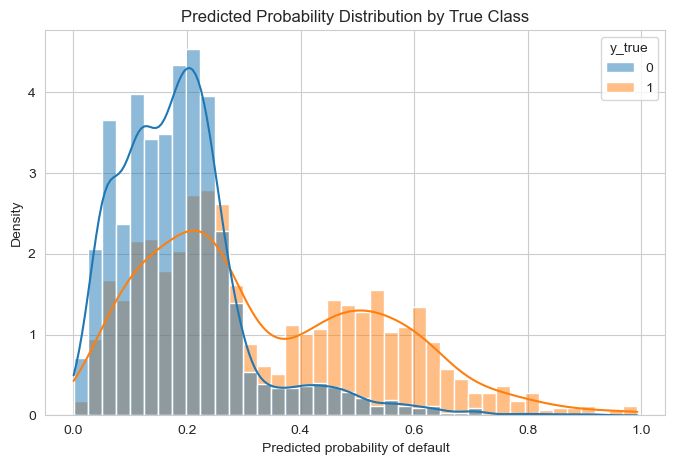

In [88]:
proba_df = pd.DataFrame({
    "y_true": y_test,
    "y_proba": y_proba
})

plt.figure(figsize=(8, 5))
sns.histplot(
    data=proba_df,
    x="y_proba",
    hue="y_true",
    bins=40,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Predicted Probability Distribution by True Class")
plt.xlabel("Predicted probability of default")
plt.ylabel("Density")
plt.show()

### Probability Distribution by True Class

This visualization is one of the most informative plots in the entire classification workflow.

Instead of looking only at final predictions (`0` or `1`), we now examine the predicted probabilities produced by Logistic Regression.

This allows us to answer a deeper question:

> Does the model assign higher risk scores to actual defaulters?

### What We Would Expect From a Good Classifier

Ideally:

- non-defaulters (`0`) should receive low predicted probabilities,
- defaulters (`1`) should receive high predicted probabilities.

In a perfect classifier, the two distributions would be completely separated.

However, real-world financial problems are rarely that simple.

Some risky clients behave similarly to safe clients, and vice versa.

As a result, overlap between the distributions is expected.

### What We Observe Here

The model clearly shifts the two groups apart:

- the non-default group concentrates mostly around lower probabilities,
- the default group is shifted toward higher probabilities.

This is a very important result.

It means that the model has learned meaningful ranking information.

Earlier in the notebook, we saw:

- repayment history variables strongly correlated with default,
- repayment behavior appeared highly informative,
- and Logistic Regression improved substantially over the Dummy Classifier.

This plot visually confirms those earlier findings.

### The Overlap Region

Although the distributions are separated, there is still substantial overlap.

This overlap is extremely important because it represents:

- ambiguous clients,
- borderline financial behavior,
- and uncertainty in prediction.

For example:

- some non-defaulters receive relatively high predicted probabilities,
- some actual defaulters receive low predicted probabilities.

This explains why classification is difficult.

The model cannot perfectly distinguish the two groups because the underlying behaviors themselves overlap.

### Connection to Threshold Tuning

This plot also explains why the default classification threshold matters so much.

## 4.11 Lift Chart

A lift chart helps answer a business question:

If we sort clients by predicted default probability, how many actual defaulters do we capture in the riskiest segment?

This is useful for credit risk monitoring, campaigns, manual review, and risk-based decisions.

In [89]:
lift_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_proba": y_proba
})

lift_df = lift_df.sort_values("y_proba", ascending=False).reset_index(drop=True)

lift_df["rank"] = np.arange(1, len(lift_df) + 1)
lift_df["cumulative_defaults"] = lift_df["y_true"].cumsum()
lift_df["cumulative_clients"] = lift_df["rank"]

total_defaults = lift_df["y_true"].sum()
total_clients = len(lift_df)

lift_df["share_clients"] = lift_df["cumulative_clients"] / total_clients
lift_df["share_defaults_captured"] = lift_df["cumulative_defaults"] / total_defaults
lift_df["lift"] = lift_df["share_defaults_captured"] / lift_df["share_clients"]

lift_df.head()

,y_true,y_proba,rank,cumulative_defaults,cumulative_clients,share_clients,share_defaults_captured,lift
0,1,0.993154,1,1,1,0.000167,0.000754,4.519608
1,1,0.992597,2,2,2,0.000334,0.001508,4.519608
2,1,0.992222,3,3,3,0.000501,0.002262,4.519608
3,1,0.990551,4,4,4,0.000667,0.003017,4.519608
4,1,0.966293,5,5,5,0.000834,0.003771,4.519608


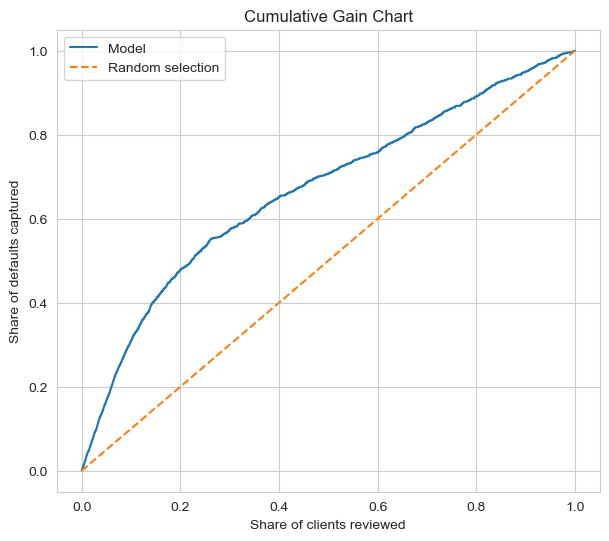

In [90]:
plt.figure(figsize=(7, 6))

plt.plot(
    lift_df["share_clients"],
    lift_df["share_defaults_captured"],
    label="Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random selection"
)

plt.title("Cumulative Gain Chart")
plt.xlabel("Share of clients reviewed")
plt.ylabel("Share of defaults captured")
plt.legend()
plt.grid(True)
plt.show()

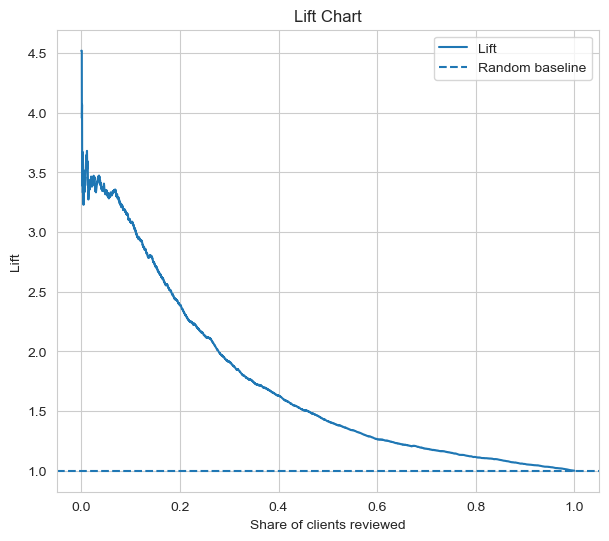

In [91]:
plt.figure(figsize=(7, 6))

plt.plot(
    lift_df["share_clients"],
    lift_df["lift"],
    label="Lift"
)

plt.axhline(y=1, linestyle="--", label="Random baseline")

plt.title("Lift Chart")
plt.xlabel("Share of clients reviewed")
plt.ylabel("Lift")
plt.legend()
plt.grid(True)
plt.show()

### Cumulative Gain Chart

The cumulative gain chart answers an important business question:

> If we review clients in order of predicted risk, how many actual defaulters can we capture?

This is one of the most practical visualizations in risk modeling because it connects machine learning directly to operational decision-making.

### What the Model Achieves

The blue curve rises much faster than the random baseline.

This means:

> the model successfully concentrates risky clients near the top of the ranking.

For example, visually we can observe that:

- reviewing roughly 20% of the highest-risk clients captures close to 50% of all defaulters.

This is a very strong business result.

It means the model can prioritize risky clients far more efficiently than random selection.

### Why Ranking Matters

This visualization reinforces an idea we introduced earlier in the probability distribution section:

> classification models are often more valuable for ranking than for hard yes/no decisions.

In practice, banks rarely rely only on binary predictions.

Instead, they often use predicted probabilities to:

- prioritize manual review,
- allocate fraud investigation resources,
- assign different risk policies,
- or identify high-risk segments for monitoring.

The gain chart shows that our Logistic Regression model already provides useful ranking capability.

### Lift Chart

The lift chart provides another way to interpret ranking performance.

Lift measures:

\[
\text{Lift} =
\frac{
\text{share of defaults captured}
}{
\text{share of clients reviewed}
}
\]

A lift value above 1 means the model performs better than random selection.

### Interpreting the Lift Curve

At the very beginning of the ranking, the lift is extremely high.

This means that among the highest-risk clients selected by the model, the concentration of actual defaulters is several times higher than in the general population.

This is a highly desirable property in risk modeling.

It means the model is effectively identifying concentrated pockets of risk.

### Why Lift Decreases Over Time

As more clients are reviewed, the lift gradually decreases.

This is expected.

Initially, the model selects the most obviously risky clients.

Later, the remaining clients become progressively harder to distinguish from one another.

Eventually, when all clients are included, the lift converges toward 1 because:

- reviewing 100% of clients captures 100% of defaults,
- which becomes equivalent to random selection.

### Business Interpretation

From a business perspective, lift is extremely useful because it quantifies operational efficiency.

For example:

- if a bank can manually review only 10% of applications,
- the lift chart shows how much more effective model-based prioritization becomes compared to random review.

This directly translates into:

- better allocation of human analysts,
- more efficient fraud/risk investigation,
- and potentially lower financial losses.

In [92]:
top_segments = [0.01, 0.05, 0.10, 0.20, 0.30]

segment_summary = []

for segment in top_segments:
    n_clients = int(len(lift_df) * segment)
    segment_data = lift_df.iloc[:n_clients]
    
    segment_summary.append({
        "top_share_clients": segment,
        "number_of_clients": n_clients,
        "defaults_captured": segment_data["y_true"].sum(),
        "share_defaults_captured": segment_data["y_true"].sum() / total_defaults,
        "default_rate_in_segment": segment_data["y_true"].mean(),
        "lift": segment_data["y_true"].mean() / y_test.mean()
    })

segment_summary = pd.DataFrame(segment_summary)

segment_summary.round(4)

,top_share_clients,number_of_clients,defaults_captured,share_defaults_captured,default_rate_in_segment,lift
0,0.01,59,47,0.0354,0.7966,3.6004
1,0.05,299,221,0.1667,0.7391,3.3406
2,0.10,599,409,0.3084,0.6828,3.0860
3,0.20,1198,633,0.4774,0.5284,2.3881
4,0.30,1797,762,0.5747,0.4240,1.9165


### Business Interpretation of Top Risk Segments

The previous gain and lift charts showed that the model ranks risky clients much better than random selection.

Now we quantify this behavior more concretely by examining the highest-risk segments.

The table answers questions such as:

- What happens if we review only the top 1% most risky clients?
- How many actual defaulters can we capture?
- How concentrated is risk in the highest predicted probability groups?

This is extremely important in real financial systems because operational resources are limited.

Banks often cannot manually review every client, so prioritization becomes critical.

### Top 1% Highest-Risk Clients

The results are striking.

Among the top 1% highest-risk clients:

- nearly 80% actually defaulted,
- and the lift exceeds 3.5.

This means:

> the model identifies a group where default risk is more than 3.5 times higher than in the overall population.

This is a very strong concentration of risk.

Even though the overall default rate in the dataset is only around 22%, the model isolates a tiny segment where default becomes the dominant outcome.

### Expanding the Reviewed Population

As we expand the reviewed segment:

- 5%,
- 10%,
- 20%,
- 30%,

the default rate gradually decreases.

This is expected.

The model first ranks the most obviously risky clients at the top.

As we move deeper into the ranking, the remaining clients become less distinguishable.

However, even at 20–30% of reviewed clients, the default rate remains substantially above the population baseline.

This confirms that:

> the model preserves useful ranking quality far beyond only the extreme top segment.

### Strong Business Value

These results demonstrate why ranking models are so valuable operationally.

For example:

- reviewing only the top 10% highest-risk clients captures over 30% of all defaults,
- while maintaining a default rate far above the population average.

This allows banks to:

- prioritize manual investigation,
- allocate analysts more efficiently,
- trigger enhanced verification,
- or apply stricter lending policies selectively.

Without a predictive model, achieving this concentration of risk would be impossible through random selection.

### Lift as a Business Efficiency Metric

The lift values provide an intuitive measure of efficiency.

For example:

- a lift of 3 means the reviewed segment contains three times more defaulters than random sampling would produce.

This is often easier for business stakeholders to interpret than abstract statistical metrics such as ROC AUC.

In practice, lift charts are widely used in:

- banking,
- marketing,
- fraud detection,
- and customer targeting.

### Connecting to Earlier Findings

Earlier sections already suggested that:

- repayment history variables contain strong predictive signal,
- Logistic Regression learned meaningful structure,
- and predicted probabilities partially separate the classes.

Now we see the operational consequence of those findings:

> the model can successfully concentrate risky clients into high-priority segments.

This is an important transition in the notebook.

We are moving from purely statistical evaluation toward business-oriented model interpretation.

### Important Practical Insight

Notice that the model still does not capture all defaulters in small segments.

Even among the highest-risk clients, there are still:

- false positives,
- and missed defaulters.

This reinforces a realistic lesson:

> machine learning models reduce uncertainty — they do not eliminate it.

The goal is not perfect prediction.

The goal is to make better decisions than random or naive strategies.

## 4.12 Comparing Threshold Strategies

Now we compare three decision rules:

1. default threshold = 0.5,
2. threshold maximizing F1-score,
3. business threshold targeting high recall.

In [93]:
threshold_strategy_results = []

strategies = {
    "Default threshold 0.5": 0.5,
    "Best F1 threshold": best_f1_threshold
}

if len(candidate_thresholds) > 0:
    strategies["Business threshold"] = business_threshold

for strategy_name, threshold in strategies.items():
    pred = (y_proba >= threshold).astype(int)
    
    threshold_strategy_results.append({
        "strategy": strategy_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0)
    })

threshold_strategy_results = pd.DataFrame(threshold_strategy_results)

threshold_strategy_results.round(4)

,strategy,threshold,accuracy,precision,recall,f1
0,Default threshold 0.5,0.50,0.8129,0.7253,0.2489,0.3706
1,Best F1 threshold,0.28,0.7889,0.5251,0.4811,0.5022
2,Business threshold,0.19,0.5905,0.3124,0.7081,0.4335


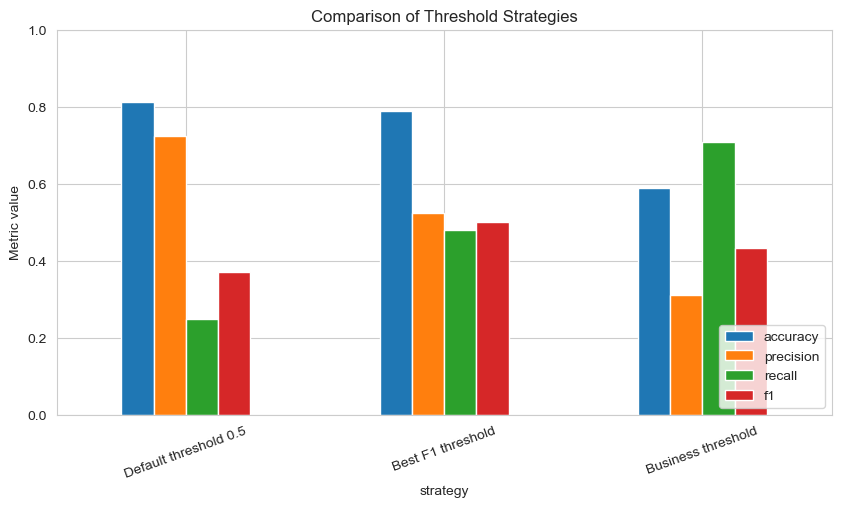

In [94]:
threshold_strategy_results.set_index("strategy")[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparison of Threshold Strategies")
plt.ylabel("Metric value")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## 4.13 Metrics Deep Dive Summary

Main conclusions:

- Accuracy can be misleading in imbalanced classification problems.
- A dummy model can achieve high accuracy while detecting no defaulters.
- Precision and recall describe different business trade-offs.
- The default threshold of 0.5 is not necessarily optimal.
- Lowering the threshold usually increases recall but reduces precision.
- ROC AUC measures ranking quality.
- PR AUC is especially useful when the positive class is rare.
- Lift charts help translate model scores into business prioritization.

In the next section, we will move from Logistic Regression to K-Nearest Neighbors and study how distance-based models behave.

# 5. K-Nearest Neighbors — Geometry Matters

In this section, we move from a parametric model to a non-parametric model: **K-Nearest Neighbors**.

KNN is conceptually simple:

> similar clients should have similar default behavior.

For a new client, the model looks for the `k` most similar clients in the training set and predicts based on their labels.

## 5.1 Why KNN?

KNN is useful for teaching machine learning because it makes the geometry of classification very explicit.

The model depends heavily on:

- distance between observations,
- feature scaling,
- number of neighbors,
- dimensionality,
- irrelevant features.

Unlike Logistic Regression, KNN does not estimate coefficients.  
It stores the training data and uses it directly during prediction.

## 5.2 KNN Intuition

For classification, KNN follows three steps:

1. calculate distance from the new observation to training observations,
2. select the `k` nearest neighbors,
3. assign the majority class among those neighbors.

The most common distance metric is Euclidean distance:

\[
d(x,y)=\sqrt{\sum_{i=1}^{p}(x_i-y_i)^2}
\]

## 5.3 KNN Without Feature Scaling

First, let us deliberately train KNN without scaling.

This is not recommended, but it is a useful experiment.

Because KNN is distance-based, variables with large numerical ranges may dominate the distance calculation.

In [95]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [96]:
knn_no_scaling = KNeighborsClassifier(
    n_neighbors=5
)

knn_no_scaling.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [97]:
knn_no_scaling_pred = knn_no_scaling.predict(X_test)
knn_no_scaling_proba = knn_no_scaling.predict_proba(X_test)[:, 1]

In [98]:
knn_no_scaling_metrics = {
    "accuracy": accuracy_score(y_test, knn_no_scaling_pred),
    "precision": precision_score(y_test, knn_no_scaling_pred, zero_division=0),
    "recall": recall_score(y_test, knn_no_scaling_pred, zero_division=0),
    "f1": f1_score(y_test, knn_no_scaling_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, knn_no_scaling_proba),
    "pr_auc": average_precision_score(y_test, knn_no_scaling_proba)
}

pd.Series(knn_no_scaling_metrics).round(4)

accuracy     0.7509
precision    0.3717
recall       0.1825
f1           0.2448
roc_auc      0.6030
pr_auc       0.2865
dtype: float64

In [99]:
print(classification_report(y_test, knn_no_scaling_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.80      0.91      0.85      4667
           1       0.37      0.18      0.24      1326

    accuracy                           0.75      5993
   macro avg       0.58      0.55      0.55      5993
weighted avg       0.70      0.75      0.72      5993



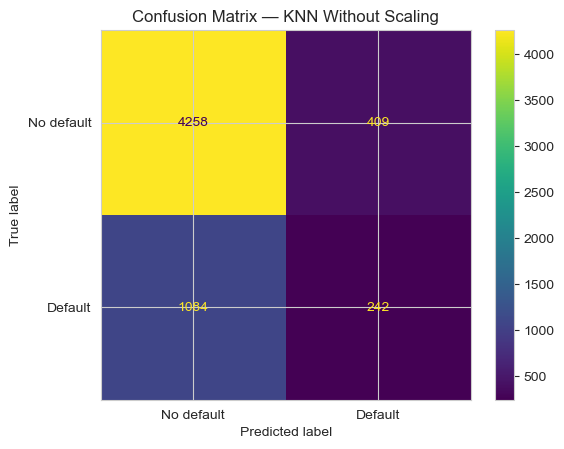

In [100]:
cm_knn_no_scaling = confusion_matrix(y_test, knn_no_scaling_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_no_scaling,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — KNN Without Scaling")
plt.show()

## 5.4 Why Scaling Matters

KNN compares observations using distances.

If one variable has a much larger scale than others, it can dominate the distance calculation.

For example:

- `LIMIT_BAL` may range from thousands to hundreds of thousands,
- `AGE` may range from around 20 to 80,
- repayment status variables may range only over a few integer values.

Without scaling, KNN may mostly compare clients by high-range financial variables and ignore other important signals.

In [101]:
feature_scale_summary = pd.DataFrame({
    "min": X_train.min(),
    "max": X_train.max(),
    "mean": X_train.mean(),
    "std": X_train.std()
})

feature_scale_summary["range"] = feature_scale_summary["max"] - feature_scale_summary["min"]

feature_scale_summary.sort_values("range", ascending=False).head(10)

,min,max,mean,std,range
BILL_AMT3,-157264,1664089,47095.932922,69410.121826,1821353
PAY_AMT2,0,1684259,5933.725471,24152.270171,1684259
BILL_AMT6,-339603,961664,38899.466044,59577.264417,1301267
BILL_AMT1,-165580,964511,51270.568622,73242.028172,1130091
BILL_AMT2,-69777,983931,49292.170240,70980.237323,1053708
LIMIT_BAL,10000,1000000,167272.638078,129869.870528,990000
BILL_AMT5,-61372,927171,40381.773444,60717.985167,988543
BILL_AMT4,-81334,891586,43378.609795,64355.851717,972920
PAY_AMT3,0,896040,5224.315785,17711.547254,896040
PAY_AMT1,0,873552,5652.104330,16680.809675,873552


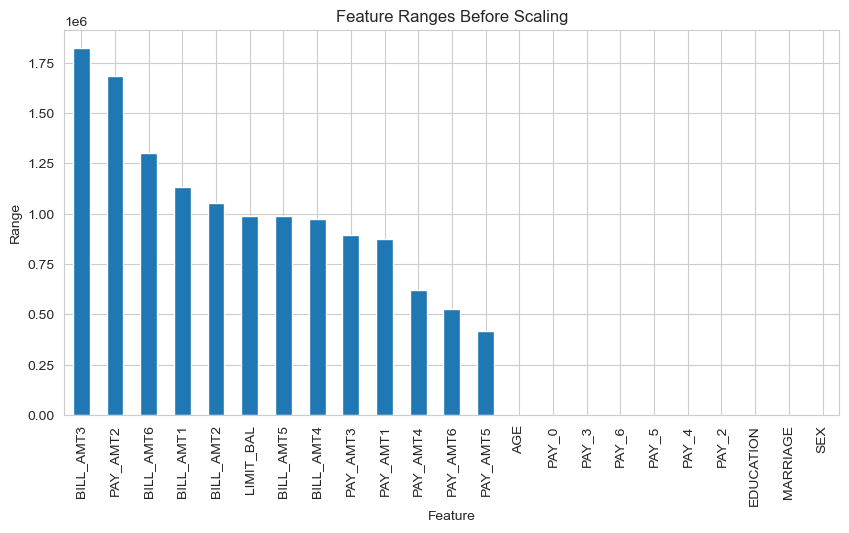

In [102]:
plt.figure(figsize=(10, 5))
feature_scale_summary["range"].sort_values(ascending=False).plot(kind="bar")

plt.title("Feature Ranges Before Scaling")
plt.xlabel("Feature")
plt.ylabel("Range")
plt.xticks(rotation=90)
plt.show()

The scale differences are substantial.

This motivates using standardization before KNN.

## 5.5 KNN With Feature Scaling

Now we train the same KNN model, but inside a pipeline with `StandardScaler`.

This ensures that every feature contributes to the distance calculation on a comparable scale.

In [103]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [104]:
knn_scaled_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]
)

knn_scaled_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [105]:
knn_scaled_pred = knn_scaled_pipeline.predict(X_test)
knn_scaled_proba = knn_scaled_pipeline.predict_proba(X_test)[:, 1]

In [106]:
knn_scaled_metrics = {
    "accuracy": accuracy_score(y_test, knn_scaled_pred),
    "precision": precision_score(y_test, knn_scaled_pred, zero_division=0),
    "recall": recall_score(y_test, knn_scaled_pred, zero_division=0),
    "f1": f1_score(y_test, knn_scaled_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, knn_scaled_proba),
    "pr_auc": average_precision_score(y_test, knn_scaled_proba)
}

pd.Series(knn_scaled_metrics).round(4)

accuracy     0.7926
precision    0.5490
recall       0.3507
f1           0.4280
roc_auc      0.6983
pr_auc       0.4126
dtype: float64

In [107]:
print(classification_report(y_test, knn_scaled_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4667
           1       0.55      0.35      0.43      1326

    accuracy                           0.79      5993
   macro avg       0.69      0.63      0.65      5993
weighted avg       0.77      0.79      0.77      5993



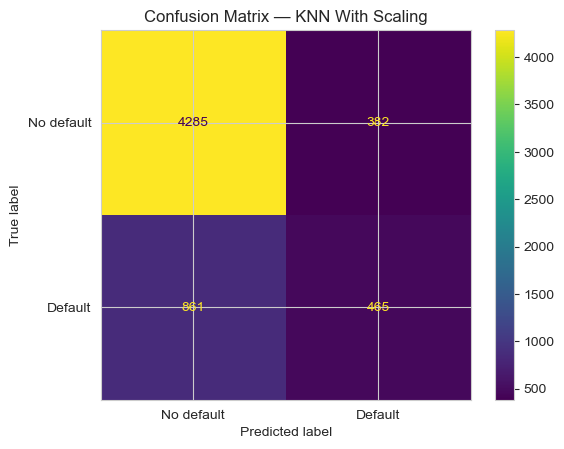

In [108]:
cm_knn_scaled = confusion_matrix(y_test, knn_scaled_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_scaled,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — KNN With Scaling")
plt.show()

## 5.6 Scaling Impact Comparison

Now we compare KNN without scaling and KNN with scaling.

This experiment demonstrates one of the most important practical lessons:

> preprocessing can be as important as model choice.

In [109]:
knn_scaling_comparison = pd.DataFrame([
    {
        "model": "KNN without scaling",
        **knn_no_scaling_metrics
    },
    {
        "model": "KNN with scaling",
        **knn_scaled_metrics
    }
])

knn_scaling_comparison = knn_scaling_comparison.set_index("model").round(4)

knn_scaling_comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
KNN without scaling,0.7509,0.3717,0.1825,0.2448,0.6030,0.2865
KNN with scaling,0.7926,0.5490,0.3507,0.4280,0.6983,0.4126


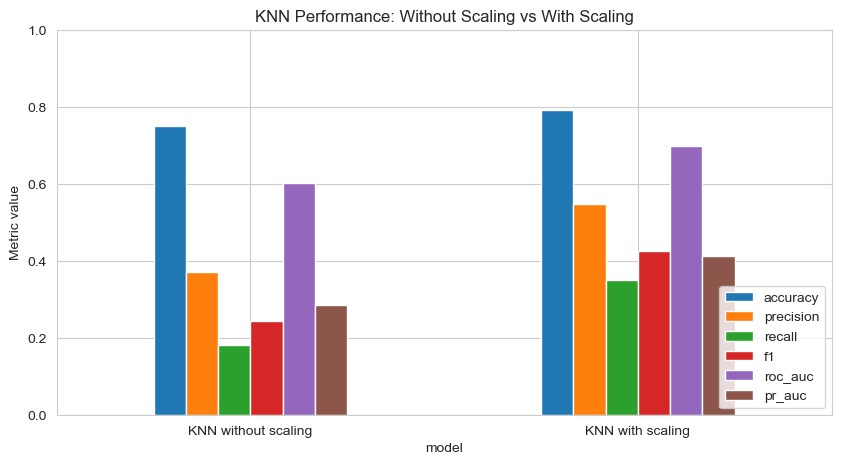

In [110]:
knn_scaling_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("KNN Performance: Without Scaling vs With Scaling")
plt.ylabel("Metric value")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

If scaling improves the metrics, it confirms that the original feature scales distorted the distance calculation.

If the improvement is modest, the lesson still holds: distance-based algorithms should almost always be used with proper scaling.

## 5.7 Effect of Number of Neighbors

The most important hyperparameter of KNN is `k`, the number of neighbors.

Small `k`:

- low bias,
- high variance,
- more flexible decision boundary,
- higher risk of overfitting.

Large `k`:

- higher bias,
- lower variance,
- smoother decision boundary,
- higher risk of underfitting.

In [111]:
k_values = list(range(1, 51))

knn_k_results = []

for k in k_values:
    knn_pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=k))
        ]
    )
    
    knn_pipeline.fit(X_train, y_train)
    
    pred = knn_pipeline.predict(X_test)
    proba = knn_pipeline.predict_proba(X_test)[:, 1]
    
    knn_k_results.append({
        "k": k,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba)
    })

knn_k_results = pd.DataFrame(knn_k_results)

knn_k_results.head()

,k,accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,0.722343,0.373123,0.374811,0.373965,0.597948,0.278179
1,2,0.784248,0.532673,0.202866,0.293829,0.648920,0.330334
2,3,0.769564,0.472472,0.355958,0.406022,0.671448,0.362928
3,4,0.798098,0.603571,0.254902,0.358431,0.686529,0.391605
4,5,0.792591,0.548996,0.350679,0.427980,0.698350,0.412600


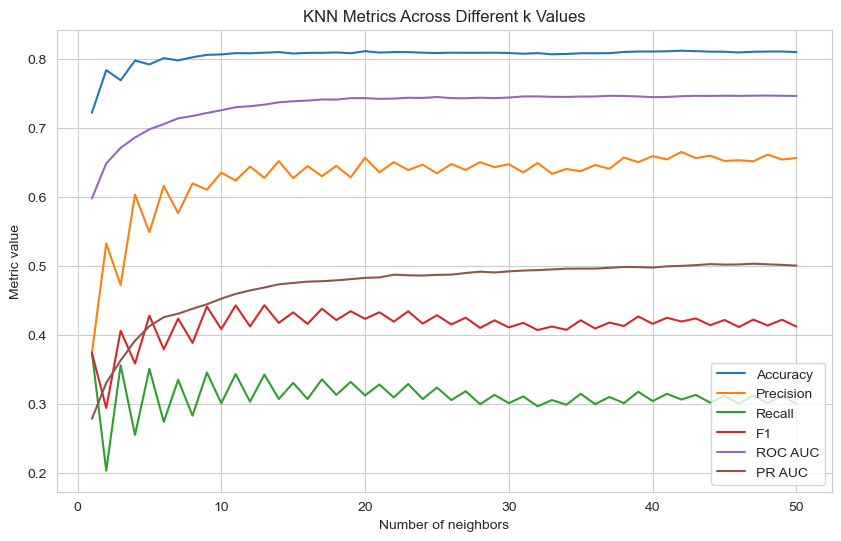

In [112]:
plt.figure(figsize=(10, 6))

plt.plot(knn_k_results["k"], knn_k_results["accuracy"], label="Accuracy")
plt.plot(knn_k_results["k"], knn_k_results["precision"], label="Precision")
plt.plot(knn_k_results["k"], knn_k_results["recall"], label="Recall")
plt.plot(knn_k_results["k"], knn_k_results["f1"], label="F1")
plt.plot(knn_k_results["k"], knn_k_results["roc_auc"], label="ROC AUC")
plt.plot(knn_k_results["k"], knn_k_results["pr_auc"], label="PR AUC")

plt.title("KNN Metrics Across Different k Values")
plt.xlabel("Number of neighbors")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True)
plt.show()

This plot shows how model performance changes with the number of neighbors.

The best value of `k` depends on the evaluation metric and the business objective.

## 5.8 Best k According to Different Metrics

Different metrics may select different values of `k`.

This is another example of why metric choice matters.

In [113]:
best_k_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"],
    "best_k": [
        knn_k_results.loc[knn_k_results["accuracy"].idxmax(), "k"],
        knn_k_results.loc[knn_k_results["precision"].idxmax(), "k"],
        knn_k_results.loc[knn_k_results["recall"].idxmax(), "k"],
        knn_k_results.loc[knn_k_results["f1"].idxmax(), "k"],
        knn_k_results.loc[knn_k_results["roc_auc"].idxmax(), "k"],
        knn_k_results.loc[knn_k_results["pr_auc"].idxmax(), "k"],
    ],
    "best_score": [
        knn_k_results["accuracy"].max(),
        knn_k_results["precision"].max(),
        knn_k_results["recall"].max(),
        knn_k_results["f1"].max(),
        knn_k_results["roc_auc"].max(),
        knn_k_results["pr_auc"].max(),
    ]
})

best_k_summary.round(4)

,metric,best_k,best_score
0,accuracy,42,0.8124
1,precision,42,0.6656
2,recall,1,0.3748
3,f1,13,0.4431
4,roc_auc,48,0.7474
5,pr_auc,47,0.5033


In [114]:
best_k_f1 = int(knn_k_results.loc[knn_k_results["f1"].idxmax(), "k"])

best_k_f1

13

## 5.9 Train KNN With Best k by F1-score

For now, we select the value of `k` that maximizes F1-score.

Later, we will perform proper cross-validation and hyperparameter tuning.

In [115]:
knn_best_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=best_k_f1))
    ]
)

knn_best_pipeline.fit(X_train, y_train)

knn_best_pred = knn_best_pipeline.predict(X_test)
knn_best_proba = knn_best_pipeline.predict_proba(X_test)[:, 1]

In [116]:
knn_best_metrics = {
    "accuracy": accuracy_score(y_test, knn_best_pred),
    "precision": precision_score(y_test, knn_best_pred, zero_division=0),
    "recall": recall_score(y_test, knn_best_pred, zero_division=0),
    "f1": f1_score(y_test, knn_best_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, knn_best_proba),
    "pr_auc": average_precision_score(y_test, knn_best_proba)
}

pd.Series(knn_best_metrics).round(4)

accuracy     0.8096
precision    0.6279
recall       0.3424
f1           0.4431
roc_auc      0.7342
pr_auc       0.4688
dtype: float64

In [117]:
print(classification_report(y_test, knn_best_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.83      0.94      0.89      4667
           1       0.63      0.34      0.44      1326

    accuracy                           0.81      5993
   macro avg       0.73      0.64      0.66      5993
weighted avg       0.79      0.81      0.79      5993



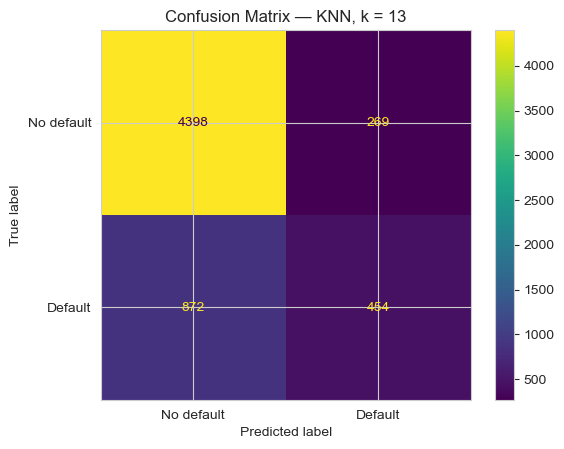

In [118]:
cm_knn_best = confusion_matrix(y_test, knn_best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_best,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix — KNN, k = {best_k_f1}")
plt.show()

## 5.10 ROC and Precision-Recall Curves for KNN

Now we visualize the ranking performance of the selected KNN model.

In [119]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

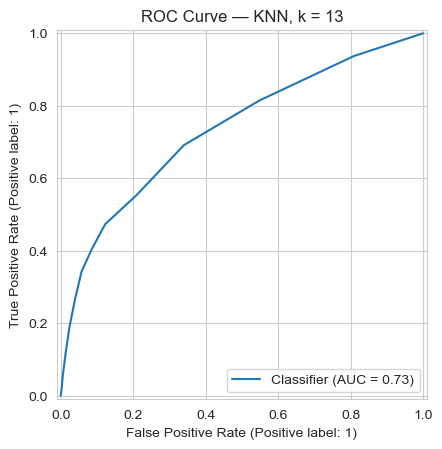

In [120]:
RocCurveDisplay.from_predictions(y_test, knn_best_proba)

plt.title(f"ROC Curve — KNN, k = {best_k_f1}")
plt.show()

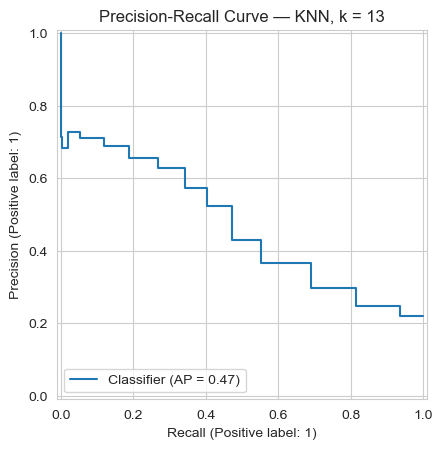

In [121]:
PrecisionRecallDisplay.from_predictions(y_test, knn_best_proba)

plt.title(f"Precision-Recall Curve — KNN, k = {best_k_f1}")
plt.show()

## 5.11 Decision Boundary Visualization on Synthetic Data

The real credit default dataset has many dimensions, so we cannot directly visualize its full decision boundary.

To understand KNN geometrically, we use a simple two-dimensional synthetic dataset.

This visualization shows how `k` changes the shape of the decision boundary.

In [122]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [123]:
X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=42
)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons,
    y_moons,
    test_size=0.3,
    random_state=42,
    stratify=y_moons
)

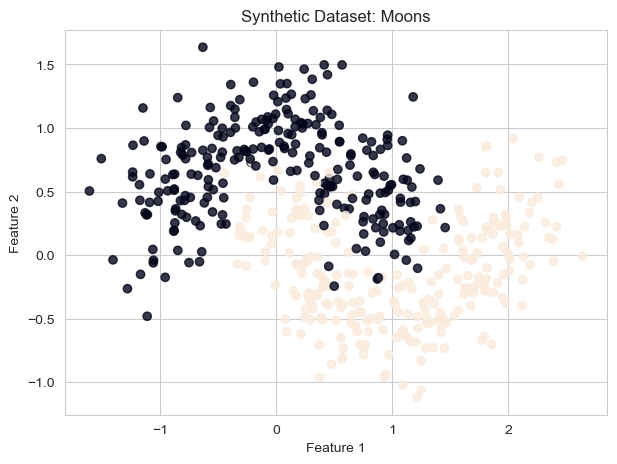

In [124]:
plt.figure(figsize=(7, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, alpha=0.8)

plt.title("Synthetic Dataset: Moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [125]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.8)
    
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

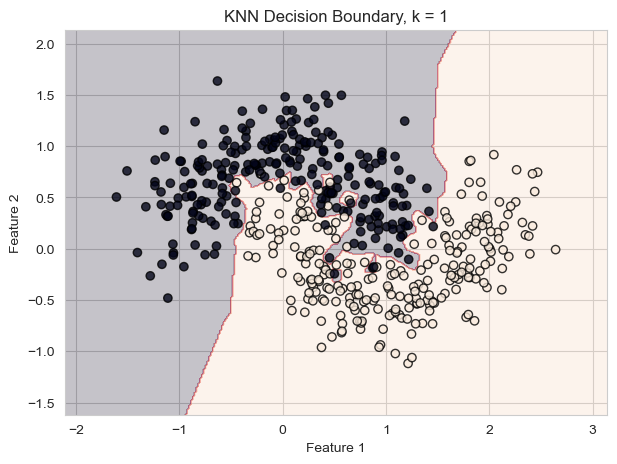

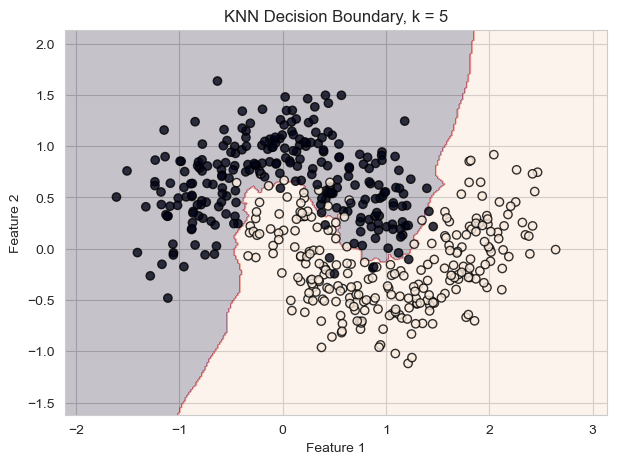

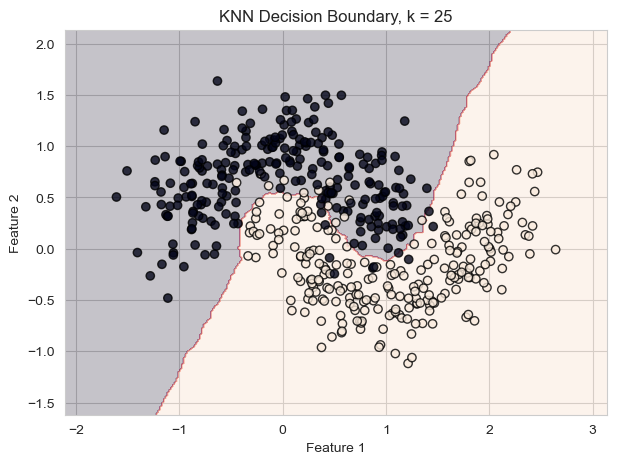

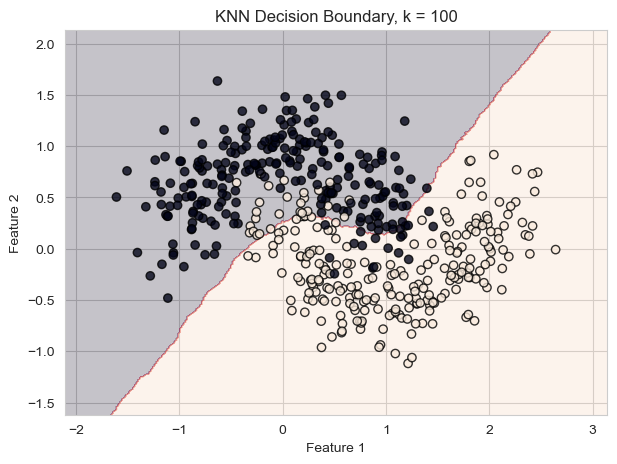

In [126]:
for k in [1, 5, 25, 100]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_moons_train, y_moons_train)
    
    plot_decision_boundary(
        model,
        X_moons,
        y_moons,
        title=f"KNN Decision Boundary, k = {k}"
    )

The decision boundaries show the bias-variance trade-off:

- `k = 1`: very flexible boundary, high variance, overfitting risk,
- moderate `k`: smoother and often better generalization,
- very large `k`: overly smooth boundary, high bias, underfitting risk.

## 5.12 Curse of Dimensionality Demonstration

KNN works best when distance is meaningful.

In high-dimensional spaces, distances between points become less informative.  
This is known as the curse of dimensionality.

Let us demonstrate this by adding random noise features to a simple dataset.

In [127]:
from sklearn.datasets import make_classification

In [128]:
noise_experiment_results = []

for n_noise_features in [0, 5, 10, 25, 50, 100]:
    X_noise, y_noise = make_classification(
        n_samples=2000,
        n_features=5 + n_noise_features,
        n_informative=5,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        random_state=42
    )
    
    X_noise_train, X_noise_test, y_noise_train, y_noise_test = train_test_split(
        X_noise,
        y_noise,
        test_size=0.3,
        random_state=42,
        stratify=y_noise
    )
    
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=5))
        ]
    )
    
    model.fit(X_noise_train, y_noise_train)
    
    pred = model.predict(X_noise_test)
    proba = model.predict_proba(X_noise_test)[:, 1]
    
    noise_experiment_results.append({
        "noise_features": n_noise_features,
        "accuracy": accuracy_score(y_noise_test, pred),
        "f1": f1_score(y_noise_test, pred),
        "roc_auc": roc_auc_score(y_noise_test, proba)
    })

noise_experiment_results = pd.DataFrame(noise_experiment_results)

noise_experiment_results

,noise_features,accuracy,f1,roc_auc
0,0,0.895000,0.899200,0.966078
1,5,0.861667,0.866345,0.930288
2,10,0.800000,0.807692,0.881156
3,25,0.733333,0.745223,0.810042
4,50,0.695000,0.721461,0.740516
5,100,0.623333,0.600707,0.667035


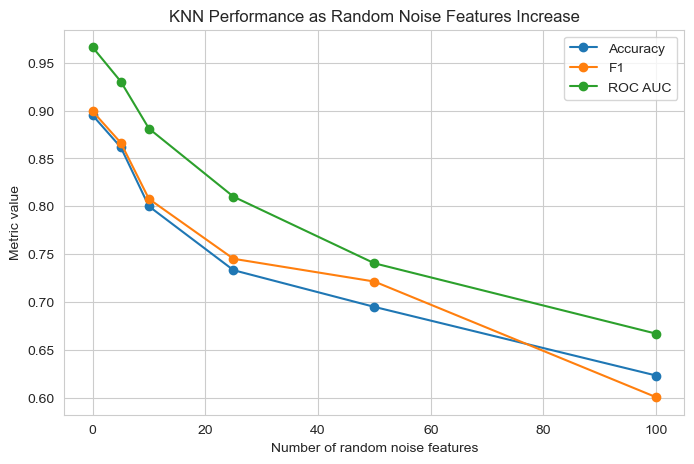

In [129]:
plt.figure(figsize=(8, 5))

plt.plot(noise_experiment_results["noise_features"], noise_experiment_results["accuracy"], marker="o", label="Accuracy")
plt.plot(noise_experiment_results["noise_features"], noise_experiment_results["f1"], marker="o", label="F1")
plt.plot(noise_experiment_results["noise_features"], noise_experiment_results["roc_auc"], marker="o", label="ROC AUC")

plt.title("KNN Performance as Random Noise Features Increase")
plt.xlabel("Number of random noise features")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True)
plt.show()

As more irrelevant dimensions are added, KNN performance usually deteriorates.

This happens because distance becomes less reliable as a similarity measure.

This is why feature selection and dimensionality reduction can be especially important for KNN.

## 5.13 Add KNN Results to Model Comparison

We now store KNN results for later comparison with Logistic Regression and SVM.

In [131]:
results.append({
    "model": f"KNN, k = {best_k_f1}",
    "accuracy": accuracy_score(y_test, knn_best_pred),
    "precision": precision_score(y_test, knn_best_pred, zero_division=0),
    "recall": recall_score(y_test, knn_best_pred, zero_division=0),
    "f1": f1_score(y_test, knn_best_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, knn_best_proba),
    "pr_auc": average_precision_score(y_test, knn_best_proba)
})

results_df = pd.DataFrame(results)

results_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression Baseline,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040
1,"KNN, k = 13",0.8096,0.6279,0.3424,0.4431,0.7342,0.4688


## 5.14 KNN Summary

Main conclusions from this section:

- KNN is simple and intuitive, but highly dependent on geometry.
- Feature scaling is essential for distance-based models.
- The number of neighbors controls the bias-variance trade-off.
- Small `k` may overfit; large `k` may underfit.
- KNN can struggle in high-dimensional spaces.
- Irrelevant features can strongly reduce KNN performance.
- KNN is useful as a teaching model, but may be computationally expensive on large datasets.

In the next section, we will study Support Vector Machines, where geometry appears again through margins and kernels.

# 6. Support Vector Machines — Margins & Kernels

Support Vector Machines are powerful supervised learning models based on geometry.

The central idea is to find a decision boundary that separates classes with the largest possible margin.

In this section, we will study:

- linear SVM,
- margins,
- support vectors,
- regularization parameter `C`,
- kernel trick,
- RBF kernel,
- hyperparameter `gamma`,
- SVM sensitivity to feature scaling.

## 6.1 SVM Intuition

SVM tries to find a hyperplane that separates classes as well as possible.

For binary classification, the model looks for a boundary that maximizes the distance between the boundary and the closest training observations.

These closest observations are called **support vectors**.

They are the most important observations for defining the decision boundary.

For a linear SVM, the decision boundary can be written as:

\[
w^T x + b = 0
\]

The margin constraints are:

\[
y_i(w^Tx_i+b) \geq 1
\]

## 6.2 Important Practical Note

SVM is sensitive to feature scaling.

Because the model is based on distances, margins, and dot products, variables with larger scales may dominate the solution.

Therefore, we will use `StandardScaler` in the modeling pipeline.

In [132]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

## 6.3 Linear SVM Baseline

We start with a linear SVM.

This model searches for a linear decision boundary in the feature space.

Because SVM does not always provide probability estimates by default, we set `probability=True`.  
This allows us to compute ROC AUC, PR AUC, and threshold-based metrics.

In [133]:
svm_linear_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="linear",
            C=1.0,
            probability=True,
            random_state=42
        ))
    ]
)

In [135]:
svm_linear_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'


In [136]:
svm_linear_pred = svm_linear_pipeline.predict(X_test)
svm_linear_proba = svm_linear_pipeline.predict_proba(X_test)[:, 1]

In [137]:
svm_linear_metrics = {
    "accuracy": accuracy_score(y_test, svm_linear_pred),
    "precision": precision_score(y_test, svm_linear_pred, zero_division=0),
    "recall": recall_score(y_test, svm_linear_pred, zero_division=0),
    "f1": f1_score(y_test, svm_linear_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, svm_linear_proba),
    "pr_auc": average_precision_score(y_test, svm_linear_proba)
}

pd.Series(svm_linear_metrics).round(4)

accuracy     0.8089
precision    0.6972
recall       0.2413
f1           0.3585
roc_auc      0.6983
pr_auc       0.4850
dtype: float64

In [138]:
print(classification_report(y_test, svm_linear_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.70      0.24      0.36      1326

    accuracy                           0.81      5993
   macro avg       0.76      0.61      0.62      5993
weighted avg       0.79      0.81      0.77      5993



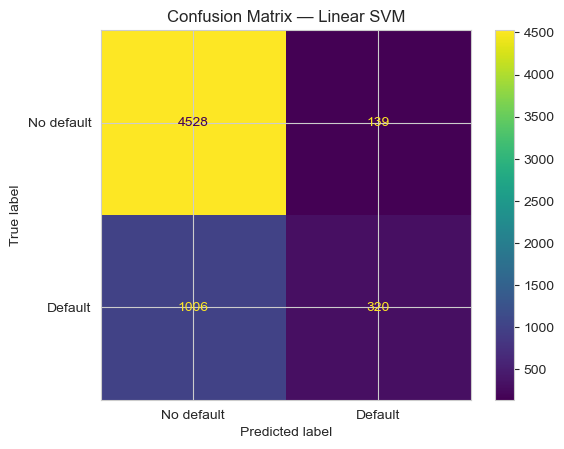

In [139]:
cm_svm_linear = confusion_matrix(y_test, svm_linear_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm_linear,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Linear SVM")
plt.show()

## 6.4 Linear SVM ROC and PR Curves

As before, we evaluate both ranking quality and minority-class performance.

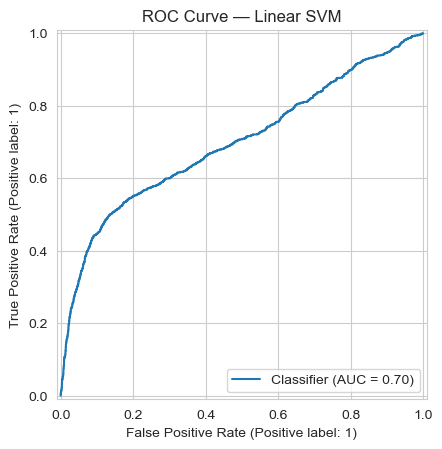

In [140]:
RocCurveDisplay.from_predictions(y_test, svm_linear_proba)
plt.title("ROC Curve — Linear SVM")
plt.show()

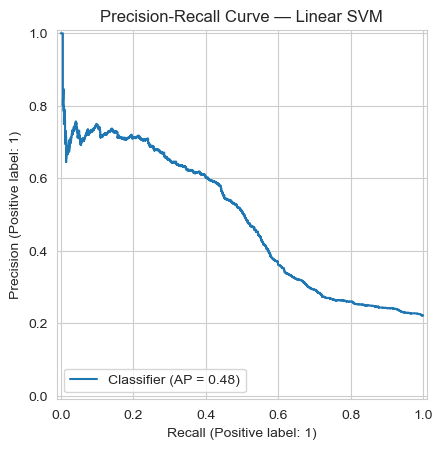

In [141]:
PrecisionRecallDisplay.from_predictions(y_test, svm_linear_proba)
plt.title("Precision-Recall Curve — Linear SVM")
plt.show()

## 6.5 SVM With RBF Kernel

A linear decision boundary may be too simple if the relationship between features and default is nonlinear.

The RBF kernel allows SVM to create nonlinear decision boundaries.

This is one of the most powerful ideas behind SVM: the **kernel trick**.

In [142]:
svm_rbf_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        ))
    ]
)

In [143]:
svm_rbf_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [144]:
svm_rbf_pred = svm_rbf_pipeline.predict(X_test)
svm_rbf_proba = svm_rbf_pipeline.predict_proba(X_test)[:, 1]

In [145]:
svm_rbf_metrics = {
    "accuracy": accuracy_score(y_test, svm_rbf_pred),
    "precision": precision_score(y_test, svm_rbf_pred, zero_division=0),
    "recall": recall_score(y_test, svm_rbf_pred, zero_division=0),
    "f1": f1_score(y_test, svm_rbf_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, svm_rbf_proba),
    "pr_auc": average_precision_score(y_test, svm_rbf_proba)
}

pd.Series(svm_rbf_metrics).round(4)

accuracy     0.8166
precision    0.6743
recall       0.3311
f1           0.4441
roc_auc      0.7170
pr_auc       0.5024
dtype: float64

In [146]:
print(classification_report(y_test, svm_rbf_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4667
           1       0.67      0.33      0.44      1326

    accuracy                           0.82      5993
   macro avg       0.75      0.64      0.67      5993
weighted avg       0.80      0.82      0.79      5993



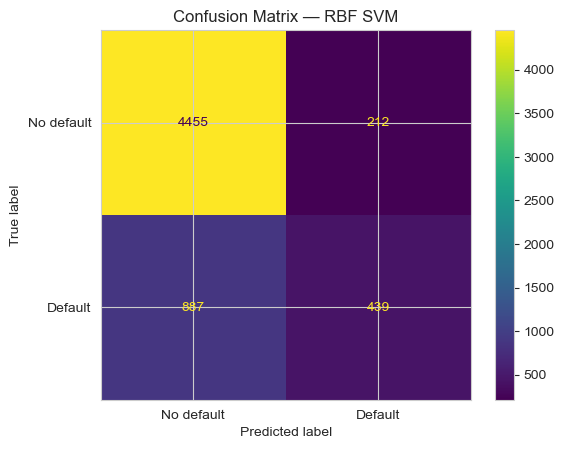

In [147]:
cm_svm_rbf = confusion_matrix(y_test, svm_rbf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm_rbf,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — RBF SVM")
plt.show()

## 6.6 Linear SVM vs RBF SVM

Now we compare the linear and nonlinear SVM variants.

In [148]:
svm_comparison = pd.DataFrame([
    {
        "model": "Linear SVM",
        **svm_linear_metrics
    },
    {
        "model": "RBF SVM",
        **svm_rbf_metrics
    }
])

svm_comparison = svm_comparison.set_index("model").round(4)

svm_comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Linear SVM,0.8089,0.6972,0.2413,0.3585,0.6983,0.4850
RBF SVM,0.8166,0.6743,0.3311,0.4441,0.7170,0.5024


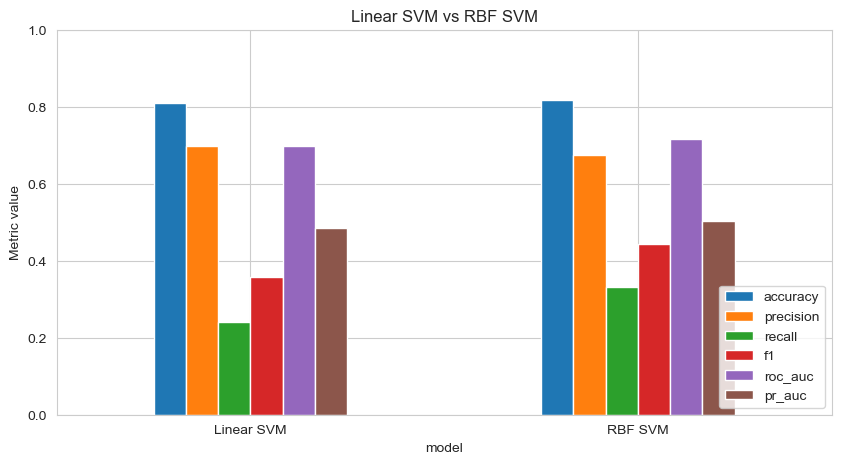

In [149]:
svm_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Linear SVM vs RBF SVM")
plt.ylabel("Metric value")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

If RBF SVM improves performance, it suggests that nonlinear relationships may be useful.

If the improvement is small, the dataset may be mostly captured by simpler linear structure, or additional feature engineering may be needed.

## 6.7 Understanding the Parameter C

The parameter `C` controls the strength of regularization.

Small `C`:

- allows more classification errors,
- creates wider margins,
- usually simpler boundary,
- lower variance,
- higher bias.

Large `C`:

- penalizes errors more strongly,
- creates narrower margins,
- may fit training data more aggressively,
- lower bias,
- higher variance.

In [150]:
C_values = [0.01, 0.1, 1, 10, 100]

svm_c_results = []

for C in C_values:
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel="rbf",
                C=C,
                gamma="scale",
                probability=True,
                random_state=42
            ))
        ]
    )
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    svm_c_results.append({
        "C": C,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba)
    })

svm_c_results = pd.DataFrame(svm_c_results)

svm_c_results.round(4)

,C,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.01,0.7998,0.6842,0.1765,0.2806,0.7171,0.4979
1,0.10,0.8158,0.6713,0.3281,0.4407,0.7128,0.5045
2,1.00,0.8166,0.6743,0.3311,0.4441,0.7170,0.5024
3,10.00,0.8161,0.6652,0.3401,0.4501,0.7139,0.4894
4,100.00,0.8019,0.5916,0.3386,0.4307,0.7064,0.4639


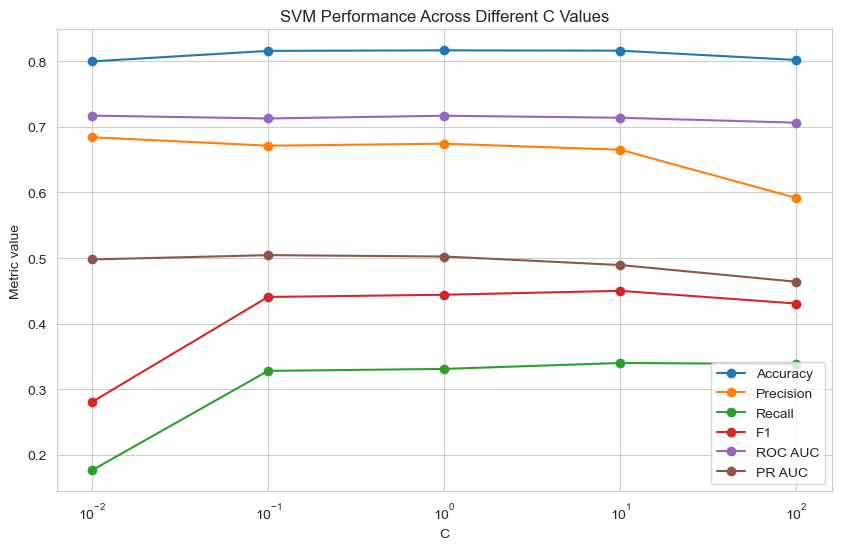

In [151]:
plt.figure(figsize=(10, 6))

plt.plot(svm_c_results["C"], svm_c_results["accuracy"], marker="o", label="Accuracy")
plt.plot(svm_c_results["C"], svm_c_results["precision"], marker="o", label="Precision")
plt.plot(svm_c_results["C"], svm_c_results["recall"], marker="o", label="Recall")
plt.plot(svm_c_results["C"], svm_c_results["f1"], marker="o", label="F1")
plt.plot(svm_c_results["C"], svm_c_results["roc_auc"], marker="o", label="ROC AUC")
plt.plot(svm_c_results["C"], svm_c_results["pr_auc"], marker="o", label="PR AUC")

plt.xscale("log")
plt.title("SVM Performance Across Different C Values")
plt.xlabel("C")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True)
plt.show()

## 6.8 Understanding the Parameter Gamma

For RBF SVM, `gamma` controls how far the influence of a single training observation reaches.

Small `gamma`:

- each observation has broad influence,
- smoother decision boundary,
- higher bias.

Large `gamma`:

- each observation has narrow influence,
- more complex decision boundary,
- higher variance,
- overfitting risk.

In [152]:
gamma_values = [0.001, 0.01, 0.1, 1, 10]

svm_gamma_results = []

for gamma in gamma_values:
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel="rbf",
                C=1.0,
                gamma=gamma,
                probability=True,
                random_state=42
            ))
        ]
    )
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    svm_gamma_results.append({
        "gamma": gamma,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_divion=0) if False else recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba)
    })

svm_gamma_results = pd.DataFrame(svm_gamma_results)

svm_gamma_results.round(4)

,gamma,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.001,0.7984,0.7458,0.1350,0.2286,0.7144,0.5032
1,0.010,0.8181,0.6879,0.3258,0.4422,0.7117,0.5024
2,0.100,0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
3,1.000,0.7926,0.6231,0.1584,0.2526,0.6824,0.4321
4,10.000,0.7791,0.5185,0.0211,0.0406,0.6167,0.3137


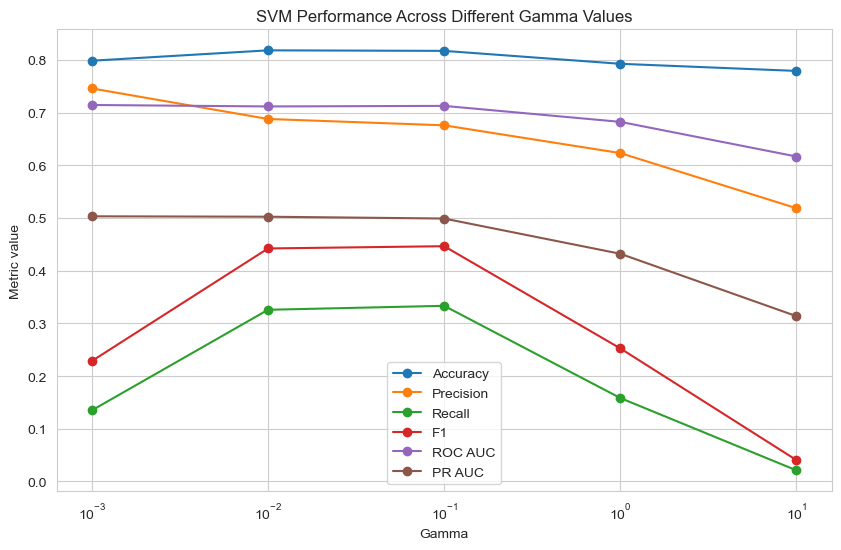

In [153]:
plt.figure(figsize=(10, 6))

plt.plot(svm_gamma_results["gamma"], svm_gamma_results["accuracy"], marker="o", label="Accuracy")
plt.plot(svm_gamma_results["gamma"], svm_gamma_results["precision"], marker="o", label="Precision")
plt.plot(svm_gamma_results["gamma"], svm_gamma_results["recall"], marker="o", label="Recall")
plt.plot(svm_gamma_results["gamma"], svm_gamma_results["f1"], marker="o", label="F1")
plt.plot(svm_gamma_results["gamma"], svm_gamma_results["roc_auc"], marker="o", label="ROC AUC")
plt.plot(svm_gamma_results["gamma"], svm_gamma_results["pr_auc"], marker="o", label="PR AUC")

plt.xscale("log")
plt.title("SVM Performance Across Different Gamma Values")
plt.xlabel("Gamma")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True)
plt.show()

## 6.9 Best SVM Configuration From Simple Search

For now, we select the best SVM configuration based on F1-score.

This is not yet full hyperparameter tuning.  
Later, we will perform cross-validation-based tuning.

In [154]:
simple_svm_search_results = []

for C in [0.1, 1, 10]:
    for gamma in [0.01, 0.1, 1]:
        model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("svm", SVC(
                    kernel="rbf",
                    C=C,
                    gamma=gamma,
                    probability=True,
                    random_state=42
                ))
            ]
        )
        
        model.fit(X_train, y_train)
        
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]
        
        simple_svm_search_results.append({
            "C": C,
            "gamma": gamma,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "f1": f1_score(y_test, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, proba),
            "pr_auc": average_precision_score(y_test, proba)
        })

simple_svm_search_results = pd.DataFrame(simple_svm_search_results)

simple_svm_search_results.sort_values("f1", ascending=False).round(4)

,C,gamma,accuracy,precision,recall,f1,roc_auc,pr_auc
4,1.0,0.10,0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
3,1.0,0.01,0.8181,0.6879,0.3258,0.4422,0.7117,0.5024
6,10.0,0.01,0.8171,0.6867,0.3190,0.4356,0.7148,0.4979
7,10.0,0.10,0.8084,0.6275,0.3303,0.4328,0.7073,0.4779
1,0.1,0.10,0.8145,0.6777,0.3077,0.4232,0.7110,0.5031
0,0.1,0.01,0.8111,0.6816,0.2745,0.3914,0.7145,0.5008
8,10.0,1.00,0.7716,0.4652,0.2164,0.2954,0.6603,0.3726
5,1.0,1.00,0.7926,0.6231,0.1584,0.2526,0.6824,0.4321
2,0.1,1.00,0.7796,0.6471,0.0083,0.0164,0.6870,0.4384


In [155]:
best_svm_row = simple_svm_search_results.loc[
    simple_svm_search_results["f1"].idxmax()
]

best_svm_C = best_svm_row["C"]
best_svm_gamma = best_svm_row["gamma"]

print("Best C:", best_svm_C)
print("Best gamma:", best_svm_gamma)

Best C: 1.0
Best gamma: 0.1


In [156]:
svm_best_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=best_svm_C,
            gamma=best_svm_gamma,
            probability=True,
            random_state=42
        ))
    ]
)

svm_best_pipeline.fit(X_train, y_train)

svm_best_pred = svm_best_pipeline.predict(X_test)
svm_best_proba = svm_best_pipeline.predict_proba(X_test)[:, 1]

In [157]:
svm_best_metrics = {
    "accuracy": accuracy_score(y_test, svm_best_pred),
    "precision": precision_score(y_test, svm_best_pred, zero_division=0),
    "recall": recall_score(y_test, svm_best_pred, zero_division=0),
    "f1": f1_score(y_test, svm_best_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, svm_best_proba),
    "pr_auc": average_precision_score(y_test, svm_best_proba)
}

pd.Series(svm_best_metrics).round(4)

accuracy     0.8171
precision    0.6758
recall       0.3333
f1           0.4465
roc_auc      0.7127
pr_auc       0.4989
dtype: float64

## 6.10 Heatmap of Simple SVM Search

A heatmap helps visualize how combinations of `C` and `gamma` affect model performance.

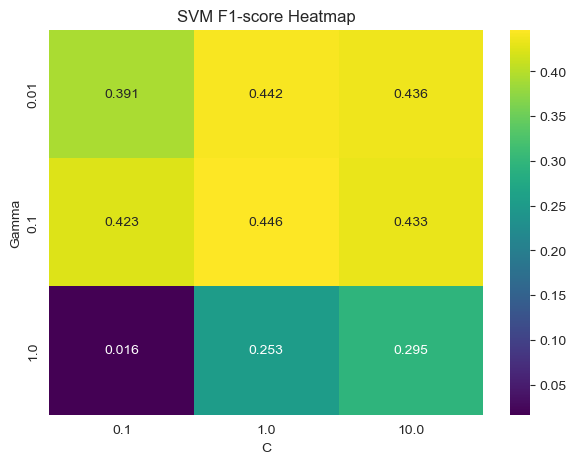

In [158]:
svm_heatmap_data = simple_svm_search_results.pivot(
    index="gamma",
    columns="C",
    values="f1"
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    svm_heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("SVM F1-score Heatmap")
plt.xlabel("C")
plt.ylabel("Gamma")
plt.show()

This heatmap shows that SVM performance can be highly sensitive to hyperparameter choices.

This motivates systematic hyperparameter tuning with cross-validation.

## 6.11 Decision Boundary Visualization: Linear vs RBF Kernel

The credit default dataset has many dimensions, so full decision boundaries cannot be directly visualized.

To understand SVM geometry, we use a two-dimensional synthetic dataset.

In [159]:
from sklearn.datasets import make_moons, make_circles

In [160]:
X_svm_demo, y_svm_demo = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=42
)

X_svm_demo_train, X_svm_demo_test, y_svm_demo_train, y_svm_demo_test = train_test_split(
    X_svm_demo,
    y_svm_demo,
    test_size=0.3,
    random_state=42,
    stratify=y_svm_demo
)

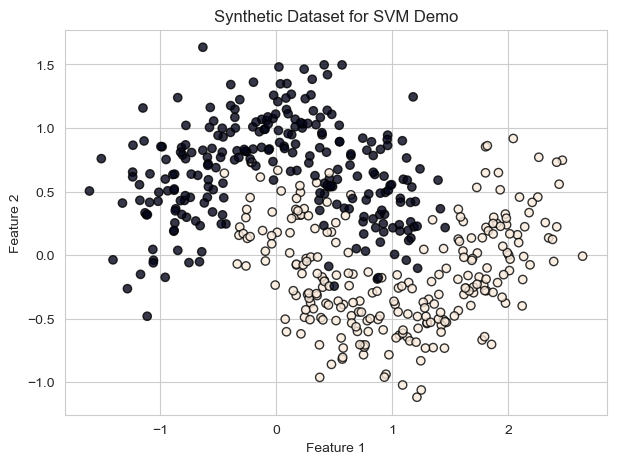

In [161]:
plt.figure(figsize=(7, 5))
plt.scatter(X_svm_demo[:, 0], X_svm_demo[:, 1], c=y_svm_demo, edgecolor="k", alpha=0.8)

plt.title("Synthetic Dataset for SVM Demo")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [162]:
def plot_svm_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.8)
    
    if hasattr(model, "support_vectors_"):
        plt.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=120,
            facecolors="none",
            edgecolors="black",
            linewidths=1.5,
            label="Support vectors"
        )
        plt.legend()
    
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

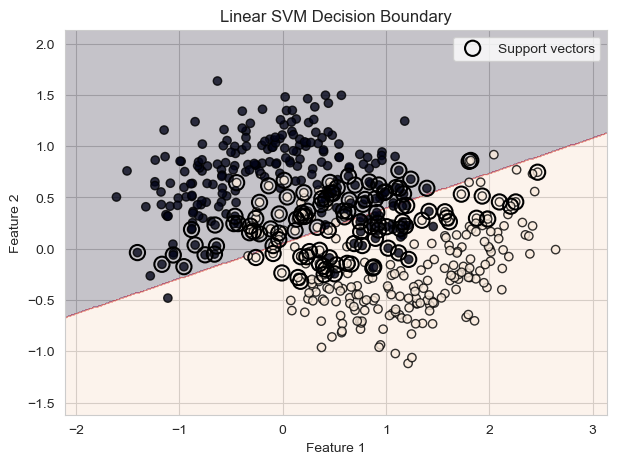

In [163]:
linear_svm_demo = SVC(
    kernel="linear",
    C=1.0,
    random_state=42
)

linear_svm_demo.fit(X_svm_demo_train, y_svm_demo_train)

plot_svm_decision_boundary(
    linear_svm_demo,
    X_svm_demo,
    y_svm_demo,
    "Linear SVM Decision Boundary"
)

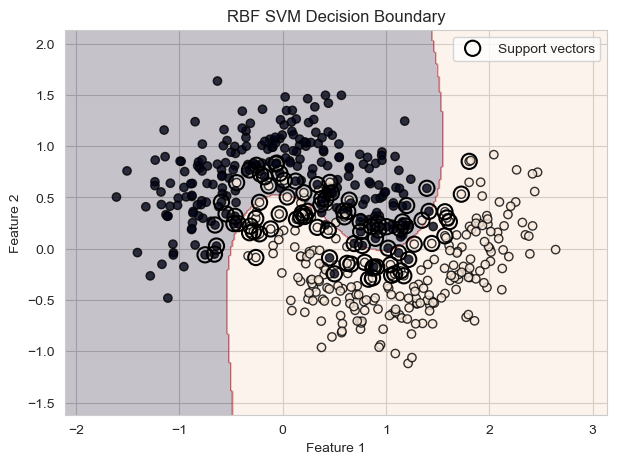

In [164]:
rbf_svm_demo = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

rbf_svm_demo.fit(X_svm_demo_train, y_svm_demo_train)

plot_svm_decision_boundary(
    rbf_svm_demo,
    X_svm_demo,
    y_svm_demo,
    "RBF SVM Decision Boundary"
)

The linear SVM can only create a straight decision boundary.

The RBF SVM can create nonlinear boundaries and better adapt to curved class structures.

## 6.12 Effect of C on Decision Boundary

Now we visualize how `C` changes the decision boundary.

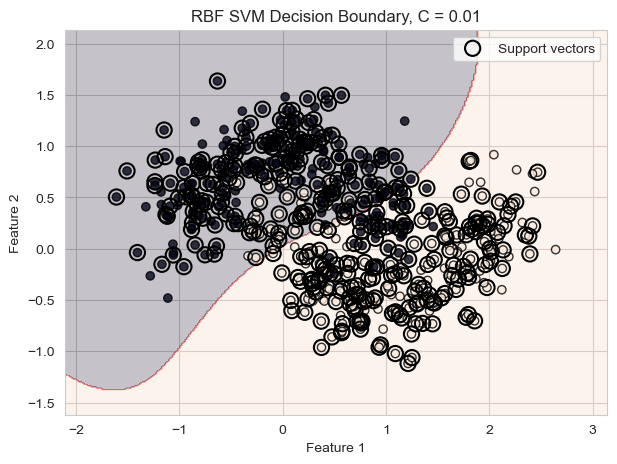

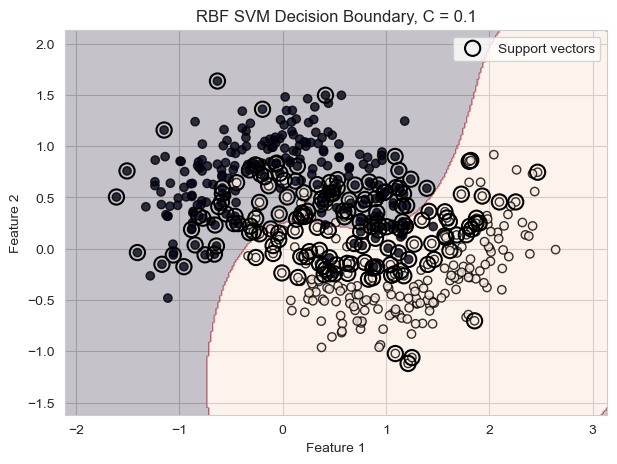

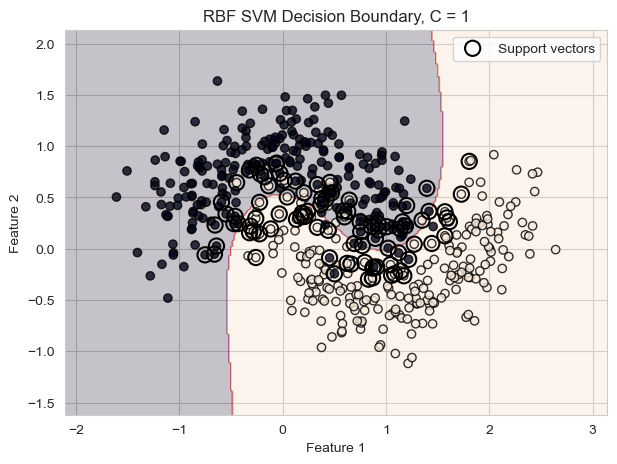

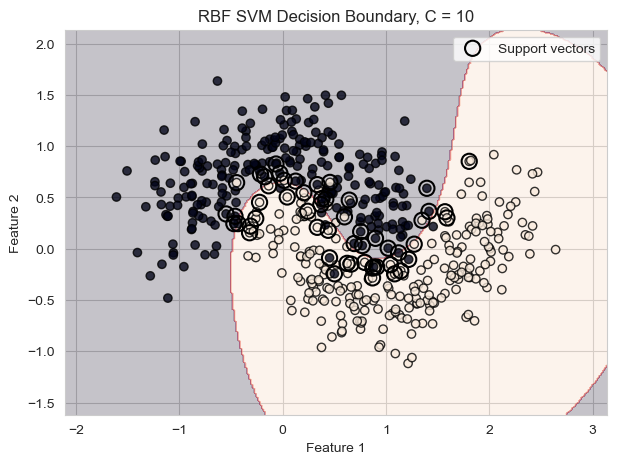

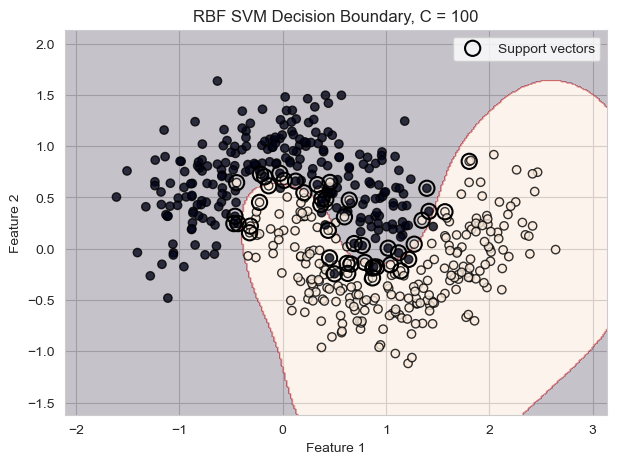

In [165]:
for C in [0.01, 0.1, 1, 10, 100]:
    model = SVC(
        kernel="rbf",
        C=C,
        gamma="scale",
        random_state=42
    )
    
    model.fit(X_svm_demo_train, y_svm_demo_train)
    
    plot_svm_decision_boundary(
        model,
        X_svm_demo,
        y_svm_demo,
        title=f"RBF SVM Decision Boundary, C = {C}"
    )

As `C` increases, the model tries harder to classify training examples correctly.

This may improve training fit but can increase overfitting risk.

## 6.13 Effect of Gamma on Decision Boundary

Now we visualize how `gamma` changes the decision boundary.

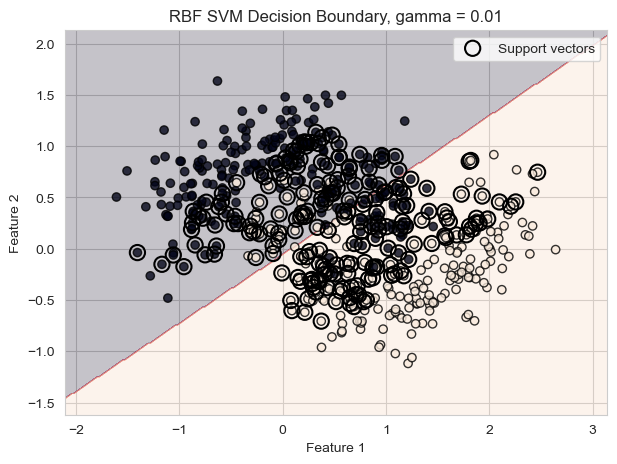

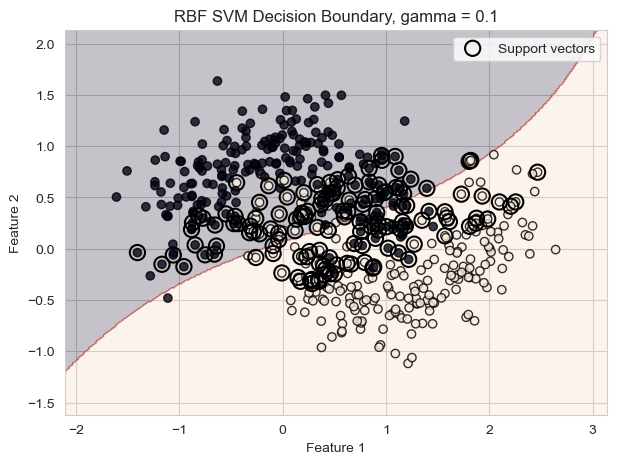

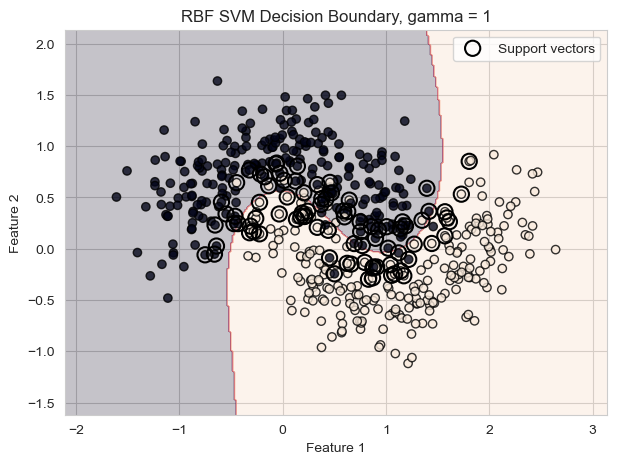

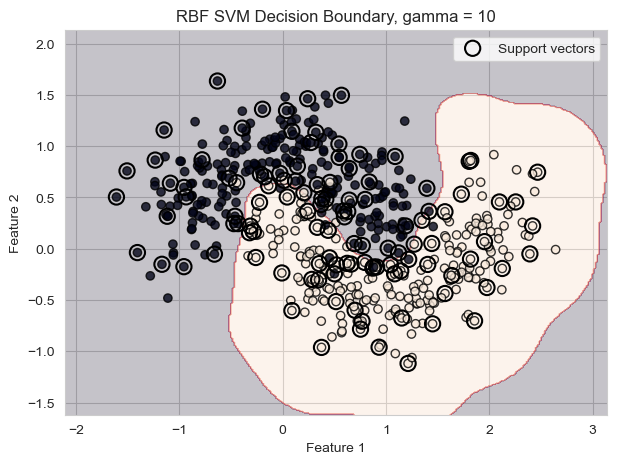

In [166]:
for gamma in [0.01, 0.1, 1, 10]:
    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma=gamma,
        random_state=42
    )
    
    model.fit(X_svm_demo_train, y_svm_demo_train)
    
    plot_svm_decision_boundary(
        model,
        X_svm_demo,
        y_svm_demo,
        title=f"RBF SVM Decision Boundary, gamma = {gamma}"
    )

Very small `gamma` creates a smooth boundary and may underfit.

Very large `gamma` creates a highly flexible boundary and may overfit.

The optimal value is usually somewhere in between.

## 6.14 Add SVM Results to Model Comparison

We now store SVM results for later comparison with Logistic Regression and KNN.

In [167]:
results.append({
    "model": f"SVM RBF, C={best_svm_C}, gamma={best_svm_gamma}",
    "accuracy": accuracy_score(y_test, svm_best_pred),
    "precision": precision_score(y_test, svm_best_pred, zero_division=0),
    "recall": recall_score(y_test, svm_best_pred, zero_division=0),
    "f1": f1_score(y_test, svm_best_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, svm_best_proba),
    "pr_auc": average_precision_score(y_test, svm_best_proba)
})

results_df = pd.DataFrame(results)

results_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression Baseline,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040
1,"KNN, k = 13",0.8096,0.6279,0.3424,0.4431,0.7342,0.4688
2,"SVM RBF, C=1.0, gamma=0.1",0.8171,0.6758,0.3333,0.4465,0.7127,0.4989


## 6.15 SVM Summary

Main conclusions from this section:

- SVM is based on margins and support vectors.
- Linear SVM creates linear decision boundaries.
- RBF SVM can model nonlinear relationships.
- Feature scaling is essential.
- `C` controls regularization strength.
- `gamma` controls the flexibility of the RBF kernel.
- SVM can be powerful, but it is sensitive to hyperparameters.
- Systematic hyperparameter tuning is especially important for SVM.

In the next section, we will introduce cross-validation and use it to evaluate models more reliably.

# 7. Cross Validation & Hyperparameter Tuning

So far, we evaluated models using a single train-test split.

This is useful for a first comparison, but it has an important limitation:

> model performance may depend on how the data was split.

Cross-validation gives us a more reliable estimate of model performance by evaluating the model on multiple train-validation splits.

## 7.1 Why Cross-Validation?

In a single train-test split, some observations go to training data and others go to testing data.

If we change the random split, the evaluation score may also change.

Cross-validation reduces this instability by repeatedly training and evaluating the model on different subsets of the data.

In this section, we will:

- compare single split instability,
- introduce Stratified K-Fold Cross-Validation,
- tune Logistic Regression,
- tune KNN,
- tune SVM,
- compare tuned models.

## 7.2 Single Split Instability

First, let us show that model evaluation can vary across different random train-test splits.

We will train the same Logistic Regression model several times using different random seeds.

In [168]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [169]:
split_results = []

for seed in range(10):
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=seed,
        stratify=y
    )
    
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42))
        ]
    )
    
    model.fit(X_train_tmp, y_train_tmp)
    
    pred_tmp = model.predict(X_test_tmp)
    proba_tmp = model.predict_proba(X_test_tmp)[:, 1]
    
    split_results.append({
        "seed": seed,
        "accuracy": accuracy_score(y_test_tmp, pred_tmp),
        "precision": precision_score(y_test_tmp, pred_tmp, zero_division=0),
        "recall": recall_score(y_test_tmp, pred_tmp, zero_division=0),
        "f1": f1_score(y_test_tmp, pred_tmp, zero_division=0),
        "roc_auc": roc_auc_score(y_test_tmp, proba_tmp),
        "pr_auc": average_precision_score(y_test_tmp, proba_tmp)
    })

split_results = pd.DataFrame(split_results)

split_results.round(4)

,seed,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0,0.8066,0.7012,0.2195,0.3343,0.7131,0.4955
1,1,0.8068,0.6875,0.2323,0.3472,0.7249,0.5014
2,2,0.8064,0.6781,0.2383,0.3527,0.7288,0.4980
3,3,0.8116,0.7194,0.2436,0.3639,0.7236,0.5093
4,4,0.8106,0.7136,0.2406,0.3598,0.7158,0.5006
5,5,0.8126,0.7146,0.2549,0.3758,0.7182,0.5011
6,6,0.8119,0.7140,0.2504,0.3707,0.7317,0.5162
7,7,0.8158,0.7546,0.2481,0.3734,0.7251,0.5293
8,8,0.8079,0.6957,0.2345,0.3508,0.7244,0.4985
9,9,0.8083,0.6911,0.2413,0.3577,0.7218,0.5012


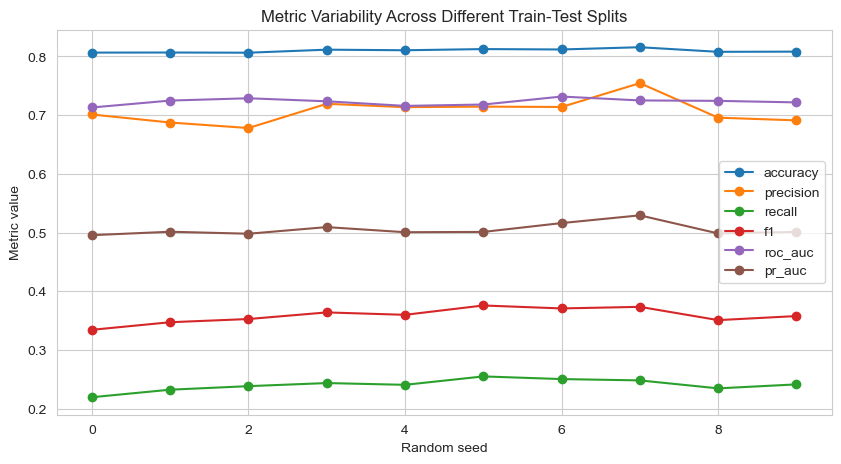

In [170]:
split_results.set_index("seed")[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Metric Variability Across Different Train-Test Splits")
plt.xlabel("Random seed")
plt.ylabel("Metric value")
plt.grid(True)
plt.show()

Even when the model and dataset stay the same, evaluation metrics vary across different data splits.

This is why a single validation result should not be treated as a perfect estimate of model quality.

## 7.3 Stratified K-Fold Cross-Validation

Because this is an imbalanced classification problem, we should preserve class proportions in each fold.

For that reason, we use **Stratified K-Fold Cross-Validation**.

Each fold should contain approximately the same percentage of defaulters and non-defaulters.

In [171]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [172]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [173]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

## 7.4 Cross-Validation for Baseline Logistic Regression

Now we evaluate Logistic Regression using cross-validation.

In [174]:
log_reg_cv_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

In [175]:
log_reg_cv_scores = cross_validate(
    log_reg_cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

In [176]:
log_reg_cv_results = pd.DataFrame(log_reg_cv_scores)

log_reg_cv_results

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1,test_roc_auc,train_roc_auc,test_pr_auc,train_pr_auc
0,0.145504,0.030081,0.807776,0.810696,0.692478,0.720115,0.236048,0.236237,0.352081,0.355764,0.729073,0.722455,0.500638,0.504576
1,0.149631,0.029531,0.811614,0.810446,0.733967,0.712528,0.233032,0.240196,0.353749,0.359278,0.706501,0.728296,0.508373,0.504866
2,0.119581,0.035538,0.812948,0.810446,0.730337,0.706972,0.245098,0.244721,0.367024,0.363585,0.711025,0.728319,0.510978,0.503451
3,0.142532,0.029163,0.813616,0.809611,0.721868,0.716628,0.256410,0.230769,0.378408,0.349116,0.743338,0.719239,0.517904,0.501329
4,0.130620,0.029935,0.807275,0.813032,0.699301,0.728080,0.226244,0.247360,0.341880,0.369265,0.721486,0.724537,0.482895,0.511281


In [177]:
cv_summary = (
    log_reg_cv_results
    .filter(regex="test_")
    .agg(["mean", "std"])
    .T
)

cv_summary.index = cv_summary.index.str.replace("test_", "")

cv_summary.round(4)

,mean,std
accuracy,0.8106,0.0029
precision,0.7156,0.0187
recall,0.2394,0.0117
f1,0.3586,0.0142
roc_auc,0.7223,0.0147
pr_auc,0.5042,0.0134


The mean score gives us an average performance estimate.

The standard deviation tells us how stable the model is across folds.

## 7.5 Train vs Validation Scores

Cross-validation can also help diagnose overfitting.

If training scores are much better than validation scores, the model may be overfitting.

In [178]:
train_test_summary = []

for metric in scoring.keys():
    train_scores = log_reg_cv_results[f"train_{metric}"]
    test_scores = log_reg_cv_results[f"test_{metric}"]
    
    train_test_summary.append({
        "metric": metric,
        "train_mean": train_scores.mean(),
        "train_std": train_scores.std(),
        "validation_mean": test_scores.mean(),
        "validation_std": test_scores.std(),
        "gap": train_scores.mean() - test_scores.mean()
    })

train_test_summary = pd.DataFrame(train_test_summary)

train_test_summary.round(4)

,metric,train_mean,train_std,validation_mean,validation_std,gap
0,accuracy,0.8108,0.0013,0.8106,0.0029,0.0002
1,precision,0.7169,0.0080,0.7156,0.0187,0.0013
2,recall,0.2399,0.0066,0.2394,0.0117,0.0005
3,f1,0.3594,0.0076,0.3586,0.0142,0.0008
4,roc_auc,0.7246,0.0039,0.7223,0.0147,0.0023
5,pr_auc,0.5051,0.0037,0.5042,0.0134,0.0009


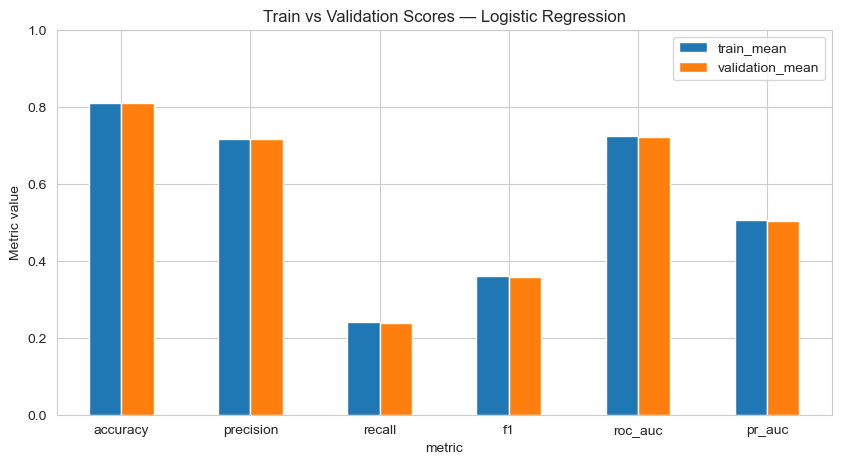

In [179]:
plot_data = train_test_summary.set_index("metric")[["train_mean", "validation_mean"]]

plot_data.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Train vs Validation Scores — Logistic Regression")
plt.ylabel("Metric value")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

A small train-validation gap suggests stable generalization.

A large gap would suggest overfitting.

## 7.6 Hyperparameter Tuning: Concept

A hyperparameter is a parameter chosen before training.

Examples:

- `C` in Logistic Regression and SVM,
- `k` in KNN,
- `gamma` in RBF SVM.

Hyperparameter tuning means searching for values that produce the best validation performance.

Important rule:

> Hyperparameters should be selected using validation data or cross-validation, not the final test set.

The test set should be used only for final evaluation.

## 7.7 Logistic Regression Tuning

For Logistic Regression, we tune:

- regularization strength `C`,
- penalty type.

Smaller `C` means stronger regularization.  
Larger `C` means weaker regularization.

In [180]:
from sklearn.model_selection import GridSearchCV

In [181]:
log_reg_tuning_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            random_state=42
        ))
    ]
)

In [182]:
log_reg_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"]
}

In [183]:
log_reg_grid = GridSearchCV(
    estimator=log_reg_tuning_pipeline,
    param_grid=log_reg_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

log_reg_grid.fit(X_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__penalty': ['l1', 'l2']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [184]:
log_reg_grid.best_params_

{'model__C': 0.001, 'model__penalty': 'l2'}

In [185]:
log_reg_grid.best_score_

np.float64(0.3597747012566275)

In [186]:
log_reg_tuning_results = pd.DataFrame(log_reg_grid.cv_results_)

log_reg_tuning_results[
    [
        "param_model__C",
        "param_model__penalty",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_model__C,param_model__penalty,mean_train_score,mean_test_score,std_test_score,rank_test_score
1,0.001,l2,0.361809,0.359775,0.010600,1
7,1.000,l2,0.357872,0.357152,0.009549,2
8,10.000,l1,0.357960,0.357152,0.009549,2
9,10.000,l2,0.357974,0.357152,0.009549,2
10,100.000,l1,0.357961,0.357152,0.009549,2
11,100.000,l2,0.357974,0.357152,0.009549,2
6,1.000,l1,0.357820,0.357067,0.009812,7
5,0.100,l2,0.357686,0.357018,0.009637,8
4,0.100,l1,0.354164,0.353812,0.010288,9
3,0.010,l2,0.353933,0.350619,0.010743,10


We tune using only the training data with cross-validation.

The test set remains untouched and will be used later for final evaluation.

## 7.8 Visualizing Logistic Regression Tuning Results

A plot helps us understand how regularization affects validation performance.

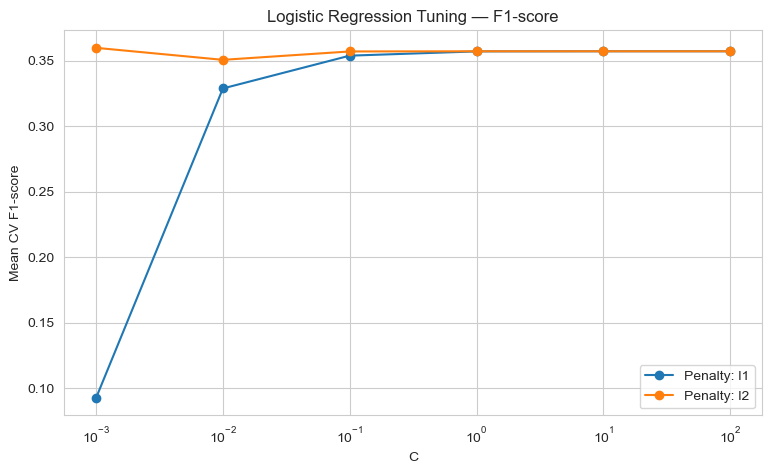

In [187]:
plt.figure(figsize=(9, 5))

for penalty in ["l1", "l2"]:
    subset = log_reg_tuning_results[
        log_reg_tuning_results["param_model__penalty"] == penalty
    ].copy()
    
    subset = subset.sort_values("param_model__C")
    
    plt.plot(
        subset["param_model__C"],
        subset["mean_test_score"],
        marker="o",
        label=f"Penalty: {penalty}"
    )

plt.xscale("log")
plt.title("Logistic Regression Tuning — F1-score")
plt.xlabel("C")
plt.ylabel("Mean CV F1-score")
plt.legend()
plt.grid(True)
plt.show()

## 7.9 KNN Tuning

For KNN, we tune:

- number of neighbors,
- weighting scheme,
- distance metric.

KNN is especially sensitive to these choices.

In [188]:
from sklearn.neighbors import KNeighborsClassifier

In [189]:
knn_tuning_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]
)

In [190]:
knn_param_grid = {
    "model__n_neighbors": list(range(3, 52, 2)),
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

In [191]:
knn_grid = GridSearchCV(
    estimator=knn_tuning_pipeline,
    param_grid=knn_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

knn_grid.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [192]:
knn_grid.best_params_

{'model__metric': 'euclidean',
 'model__n_neighbors': 17,
 'model__weights': 'distance'}

In [193]:
knn_grid.best_score_

np.float64(0.4353979709230001)

In [194]:
knn_tuning_results = pd.DataFrame(knn_grid.cv_results_)

knn_tuning_results[
    [
        "param_model__n_neighbors",
        "param_model__weights",
        "param_model__metric",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_model__n_neighbors,param_model__weights,param_model__metric,mean_train_score,mean_test_score,std_test_score,rank_test_score
15,17,distance,euclidean,0.999104,0.435398,0.010147,1
13,15,distance,euclidean,0.999104,0.435383,0.008070,2
9,11,distance,euclidean,0.999104,0.433994,0.003152,3
12,15,uniform,euclidean,0.475186,0.433894,0.008779,4
17,19,distance,euclidean,0.999104,0.433468,0.009348,5
8,11,uniform,euclidean,0.491390,0.432434,0.008868,6
19,21,distance,euclidean,0.999104,0.432422,0.008508,7
14,17,uniform,euclidean,0.470236,0.432395,0.010386,8
11,13,distance,euclidean,0.999104,0.432142,0.009960,9
21,23,distance,euclidean,0.999104,0.431088,0.010681,10


## 7.10 Visualizing KNN Tuning Results

We visualize how the number of neighbors affects F1-score.

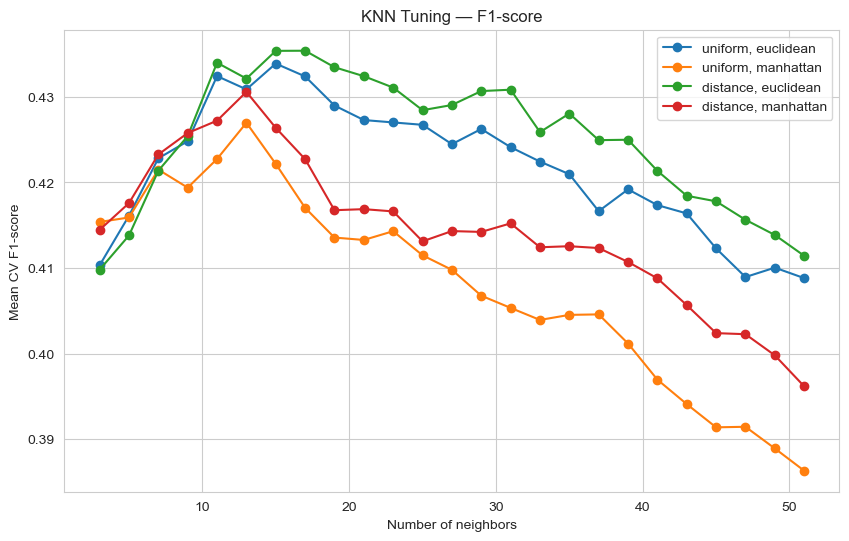

In [195]:
plt.figure(figsize=(10, 6))

for weights in ["uniform", "distance"]:
    for metric in ["euclidean", "manhattan"]:
        subset = knn_tuning_results[
            (knn_tuning_results["param_model__weights"] == weights)
            & (knn_tuning_results["param_model__metric"] == metric)
        ].copy()
        
        subset = subset.sort_values("param_model__n_neighbors")
        
        plt.plot(
            subset["param_model__n_neighbors"],
            subset["mean_test_score"],
            marker="o",
            label=f"{weights}, {metric}"
        )

plt.title("KNN Tuning — F1-score")
plt.xlabel("Number of neighbors")
plt.ylabel("Mean CV F1-score")
plt.legend()
plt.grid(True)
plt.show()

This plot shows the bias-variance trade-off for KNN.

Very small `k` may overfit.  
Very large `k` may underfit.

## 7.11 SVM Tuning

SVM is highly sensitive to hyperparameters.

For RBF SVM, we tune:

- `C`,
- `gamma`.

Because SVM can be computationally expensive, we use a relatively small search grid.

In [196]:
from sklearn.svm import SVC

In [197]:
svm_tuning_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]
)

In [198]:
svm_param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": [0.01, 0.1, 1]
}

In [199]:
svm_grid = GridSearchCV(
    estimator=svm_tuning_pipeline,
    param_grid=svm_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

svm_grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__gamma': [0.01, 0.1, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [200]:
svm_grid.best_params_

{'model__C': 1, 'model__gamma': 0.1}

In [201]:
svm_grid.best_score_

np.float64(0.4495888191781135)

In [202]:
svm_tuning_results = pd.DataFrame(svm_grid.cv_results_)

svm_tuning_results[
    [
        "param_model__C",
        "param_model__gamma",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_model__C,param_model__gamma,mean_train_score,mean_test_score,std_test_score,rank_test_score
4,1.0,0.10,0.510491,0.449589,0.014450,1
7,10.0,0.10,0.648160,0.439587,0.010401,2
3,1.0,0.01,0.443609,0.439460,0.023737,3
6,10.0,0.01,0.456560,0.438647,0.012113,4
1,0.1,0.10,0.430753,0.420227,0.017796,5
0,0.1,0.01,0.386491,0.386201,0.015671,6
8,10.0,1.00,0.924677,0.295696,0.010680,7
5,1.0,1.00,0.777628,0.244012,0.009776,8
2,0.1,1.00,0.013279,0.008600,0.004479,9


## 7.12 SVM Hyperparameter Heatmap

The heatmap shows how the interaction between `C` and `gamma` affects model performance.

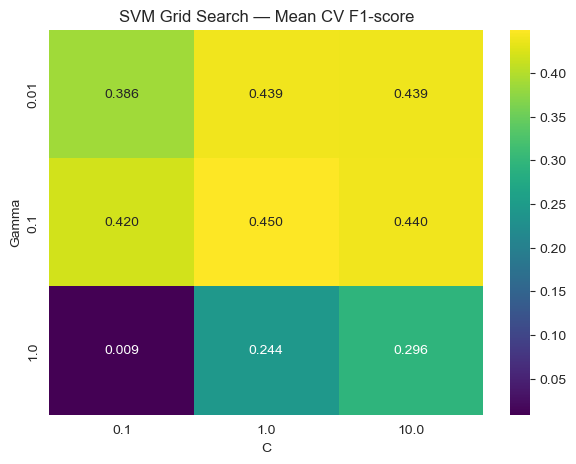

In [203]:
svm_cv_heatmap = svm_tuning_results.pivot(
    index="param_model__gamma",
    columns="param_model__C",
    values="mean_test_score"
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    svm_cv_heatmap,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("SVM Grid Search — Mean CV F1-score")
plt.xlabel("C")
plt.ylabel("Gamma")
plt.show()

## 7.13 Randomized Search

Grid Search checks every combination in the parameter grid.

This can become expensive when the search space is large.

Randomized Search samples a fixed number of combinations from parameter distributions.

It is often more efficient than Grid Search.

In [204]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

In [205]:
svm_random_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]
)

In [206]:
svm_random_param_distributions = {
    "model__C": loguniform(1e-2, 1e2),
    "model__gamma": loguniform(1e-3, 1e1)
}

In [207]:
svm_random_search = RandomizedSearchCV(
    estimator=svm_random_pipeline,
    param_distributions=svm_random_param_distributions,
    n_iter=15,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

svm_random_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__C': <scipy.stats....00175661356A0>, 'model__gamma': <scipy.stats....001756B69D450>}"
,n_iter,15
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [208]:
svm_random_search.best_params_

{'model__C': np.float64(2.801635158716261),
 'model__gamma': np.float64(0.003613894271216527)}

In [209]:
svm_random_search.best_score_

np.float64(0.4381031579059136)

In [210]:
svm_random_results = pd.DataFrame(svm_random_search.cv_results_)

svm_random_results[
    [
        "param_model__C",
        "param_model__gamma",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_model__C,param_model__gamma,mean_train_score,mean_test_score,std_test_score,rank_test_score
10,2.801635,0.003614,0.440094,0.438103,0.017243,1
6,21.368329,0.007069,0.455245,0.437138,0.010319,2
9,0.534294,0.014619,0.441641,0.436471,0.022017,3
11,0.147428,0.029204,0.440715,0.435342,0.020375,4
8,0.164804,0.125610,0.436552,0.418305,0.018098,5
1,8.471801,0.248104,0.791486,0.416553,0.014706,6
13,0.062906,0.114009,0.404865,0.394630,0.018493,7
14,2.342385,0.001534,0.369480,0.366742,0.011396,8
4,2.537816,0.679658,0.833159,0.341723,0.010804,9
7,0.053370,0.005415,0.172767,0.171804,0.022455,10


Randomized Search does not guarantee checking the best possible combination.

However, it can explore a much wider hyperparameter space with fewer evaluations.

## 7.14 Final Evaluation of Tuned Models on Test Set

Now we evaluate the best tuned models on the test set.

This is the first time the selected models are tested on unseen data.

In [211]:
best_log_reg = log_reg_grid.best_estimator_
best_knn = knn_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_svm_random = svm_random_search.best_estimator_

In [212]:
tuned_models = {
    "Tuned Logistic Regression": best_log_reg,
    "Tuned KNN": best_knn,
    "Tuned SVM Grid": best_svm,
    "Tuned SVM Random": best_svm_random
}

In [213]:
tuned_test_results = []

for model_name, model in tuned_models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    tuned_test_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba)
    })

tuned_test_results = pd.DataFrame(tuned_test_results)

tuned_test_results.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Tuned Logistic Regression,0.8104,0.7065,0.2451,0.3639,0.7130,0.5002
1,Tuned KNN,0.8073,0.6183,0.3371,0.4363,0.7376,0.4858
2,Tuned SVM Grid,0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
3,Tuned SVM Random,0.8185,0.6895,0.3265,0.4432,0.7076,0.5013


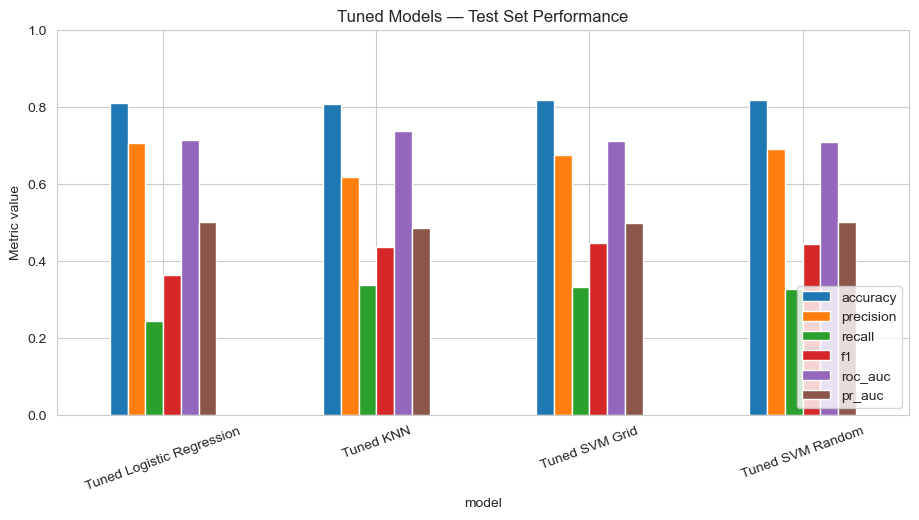

In [214]:
tuned_test_results.set_index("model").plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Tuned Models — Test Set Performance")
plt.ylabel("Metric value")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## 7.15 Confusion Matrices for Tuned Models

Now we compare the confusion matrices of tuned models.

This is especially useful because the same F1-score can hide different business trade-offs.

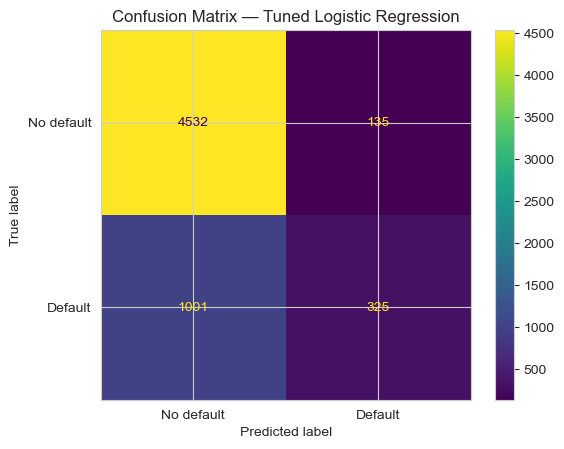

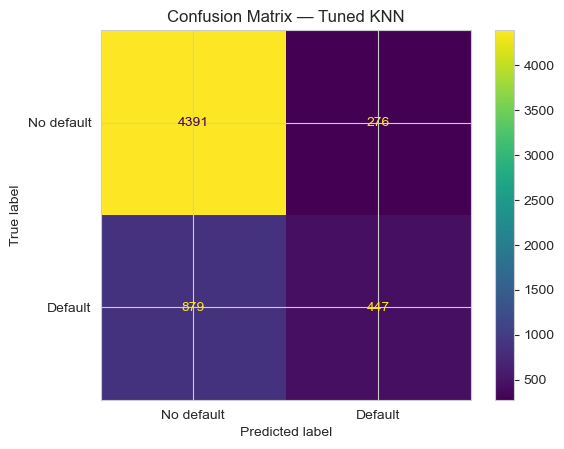

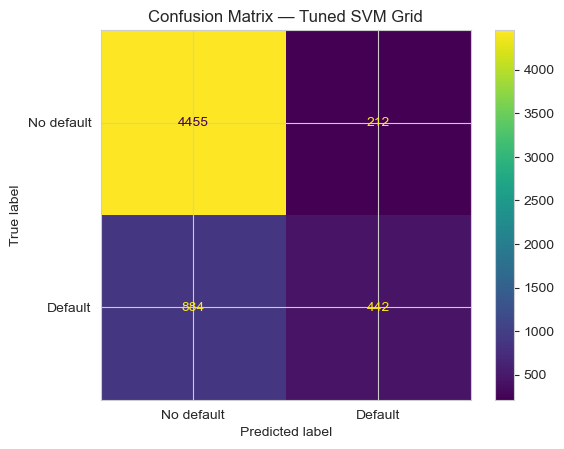

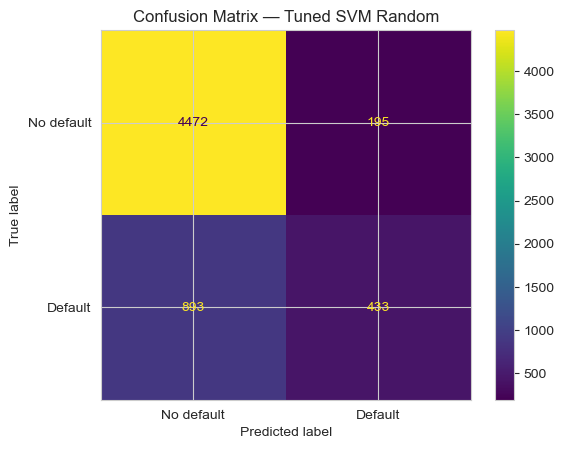

In [215]:
for model_name, model in tuned_models.items():
    pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No default", "Default"]
    )
    
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

## 7.16 ROC Curves for Tuned Models

We compare ranking ability across models.

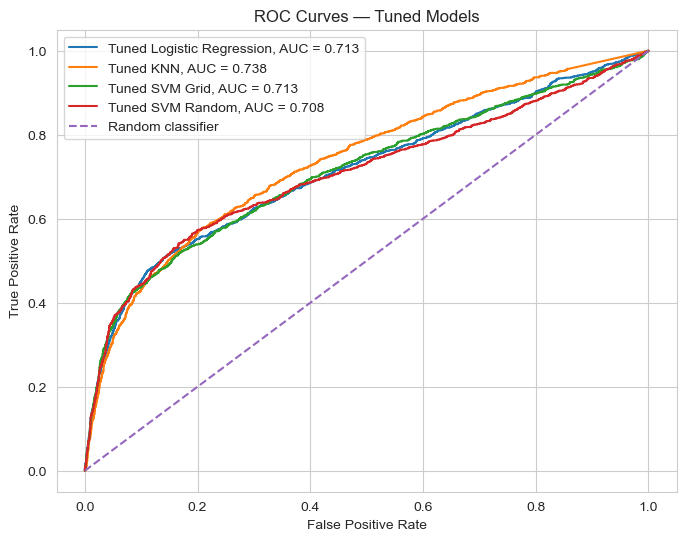

In [216]:
plt.figure(figsize=(8, 6))

for model_name, model in tuned_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    
    plt.plot(fpr, tpr, label=f"{model_name}, AUC = {auc_score:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.title("ROC Curves — Tuned Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

## 7.17 Precision-Recall Curves for Tuned Models

For imbalanced classification, Precision-Recall curves are often more informative than ROC curves.

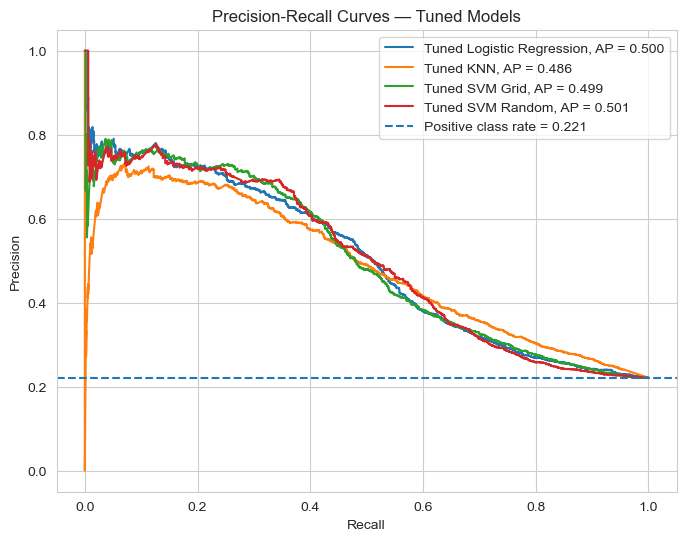

In [217]:
plt.figure(figsize=(8, 6))

for model_name, model in tuned_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap_score = average_precision_score(y_test, proba)
    
    plt.plot(recall, precision, label=f"{model_name}, AP = {ap_score:.3f}")

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Positive class rate = {y_test.mean():.3f}"
)

plt.title("Precision-Recall Curves — Tuned Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

## 7.18 Update Global Results Table

We add the tuned models to our global model comparison table.

In [218]:
for _, row in tuned_test_results.iterrows():
    results.append(row.to_dict())

results_df = pd.DataFrame(results)

results_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression Baseline,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040
1,"KNN, k = 13",0.8096,0.6279,0.3424,0.4431,0.7342,0.4688
2,"SVM RBF, C=1.0, gamma=0.1",0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
3,Tuned Logistic Regression,0.8104,0.7065,0.2451,0.3639,0.7130,0.5002
4,Tuned KNN,0.8073,0.6183,0.3371,0.4363,0.7376,0.4858
5,Tuned SVM Grid,0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
6,Tuned SVM Random,0.8185,0.6895,0.3265,0.4432,0.7076,0.5013


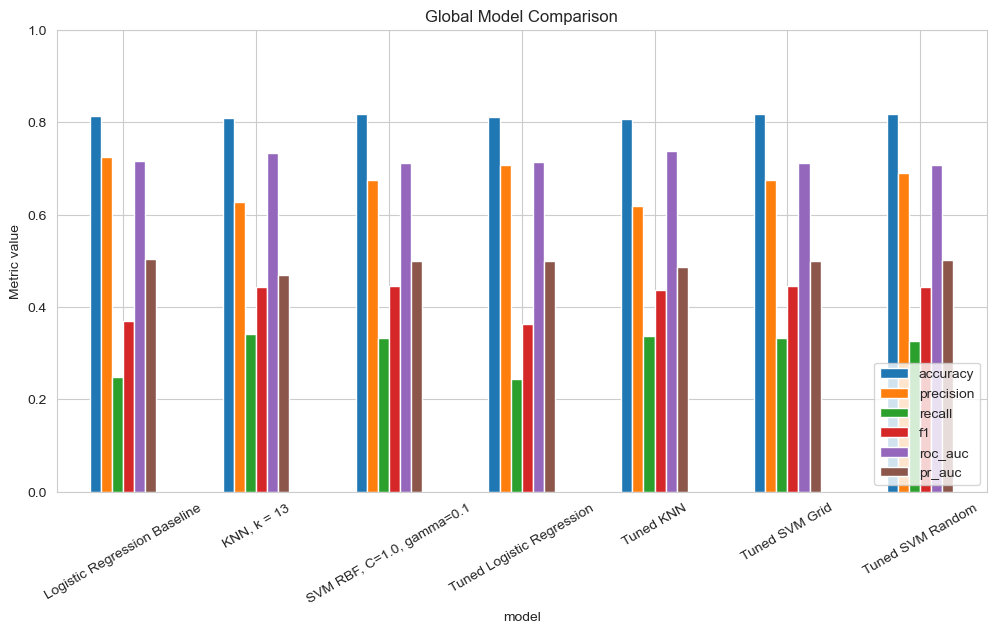

In [219]:
results_df.drop_duplicates(subset=["model"], keep="last").set_index("model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Global Model Comparison")
plt.ylabel("Metric value")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## 7.19 Cross-Validation & Hyperparameter Tuning Summary

Main conclusions:

- A single train-test split can produce unstable estimates.
- Cross-validation gives a more reliable estimate of model performance.
- Stratified K-Fold is appropriate for imbalanced classification.
- Hyperparameter tuning should be performed using cross-validation.
- The final test set should not be used for selecting hyperparameters.
- Logistic Regression, KNN, and SVM require different hyperparameter spaces.
- Grid Search is exhaustive but may be expensive.
- Randomized Search can explore larger spaces more efficiently.
- Tuned models should be evaluated using several metrics, not just accuracy.

In the next section, we will study feature engineering and regularization.

# 8. Feature Engineering & Regularization

So far, we trained models mostly on the original dataset.

Now we will improve the modeling process using two important ideas:

1. **Feature Engineering** — creating new variables that may better represent customer behavior.
2. **Regularization** — controlling model complexity to reduce overfitting.

Feature engineering can improve the signal available to the model.  
Regularization helps the model use that signal without becoming too complex.

## 8.1 Why Feature Engineering?

Raw variables are not always the best representation of the business problem.

In credit risk, individual monthly bill amounts and payment amounts may be less informative than summarized behavioral indicators.

For example, we may want to know:

- how much debt the client has accumulated,
- how much the client has repaid,
- whether the client pays systematically,
- whether recent payment delays occurred,
- how much of the credit limit is being used.

## 8.2 Create Feature Engineering Function

To avoid data leakage, feature engineering should be wrapped in a function and applied consistently to training and test data.

The function below creates simple business-inspired features.

In [220]:
def add_credit_features(df_input):
    df_fe = df_input.copy()
    
    bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
    pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
    pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
    
    df_fe["TOTAL_BILL_AMT"] = df_fe[bill_cols].sum(axis=1)
    df_fe["AVG_BILL_AMT"] = df_fe[bill_cols].mean(axis=1)
    df_fe["MAX_BILL_AMT"] = df_fe[bill_cols].max(axis=1)
    
    df_fe["TOTAL_PAY_AMT"] = df_fe[pay_amt_cols].sum(axis=1)
    df_fe["AVG_PAY_AMT"] = df_fe[pay_amt_cols].mean(axis=1)
    df_fe["MAX_PAY_AMT"] = df_fe[pay_amt_cols].max(axis=1)
    
    df_fe["PAY_TO_BILL_RATIO"] = df_fe["TOTAL_PAY_AMT"] / (df_fe["TOTAL_BILL_AMT"].abs() + 1)
    df_fe["BILL_TO_LIMIT_RATIO"] = df_fe["AVG_BILL_AMT"] / (df_fe["LIMIT_BAL"] + 1)
    
    df_fe["AVG_PAY_STATUS"] = df_fe[pay_status_cols].mean(axis=1)
    df_fe["MAX_PAY_STATUS"] = df_fe[pay_status_cols].max(axis=1)
    df_fe["NUM_DELAYED_PAYMENTS"] = (df_fe[pay_status_cols] > 0).sum(axis=1)
    
    df_fe["RECENT_DELAY"] = (df_fe["PAY_0"] > 0).astype(int)
    
    return df_fe

## 8.3 Apply Feature Engineering

We create a new feature matrix with additional engineered variables.

In [221]:
X_fe = add_credit_features(X)

X_fe.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TOTAL_BILL_AMT,AVG_BILL_AMT,MAX_BILL_AMT,TOTAL_PAY_AMT,AVG_PAY_AMT,MAX_PAY_AMT,PAY_TO_BILL_RATIO,BILL_TO_LIMIT_RATIO,AVG_PAY_STATUS,MAX_PAY_STATUS,NUM_DELAYED_PAYMENTS,RECENT_DELAY
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,7704,1284.000000,3913,689,114.833333,689,0.089422,0.064197,-0.333333,2,2,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,17077,2846.166667,3455,5000,833.333333,2000,0.292774,0.023718,0.500000,2,2,0
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,101653,16942.166667,29239,11018,1836.333333,5000,0.108387,0.188244,0.000000,0,0,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,231334,38555.666667,49291,8388,1398.000000,2019,0.036259,0.771098,0.000000,0,0,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,109339,18223.166667,35835,59049,9841.500000,36681,0.540049,0.364456,-0.333333,0,0,0


In [222]:
print("Original number of features:", X.shape[1])
print("Number of features after feature engineering:", X_fe.shape[1])

Original number of features: 23
Number of features after feature engineering: 35


## 8.4 Train-Test Split With Engineered Features

We use the same stratified split logic as before.

In [223]:
X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [224]:
print("X_fe_train shape:", X_fe_train.shape)
print("X_fe_test shape:", X_fe_test.shape)

X_fe_train shape: (23972, 35)
X_fe_test shape: (5993, 35)


## 8.5 Baseline Logistic Regression With Engineered Features

First, we check whether engineered features improve Logistic Regression.

In [225]:
log_reg_fe_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

log_reg_fe_pipeline.fit(X_fe_train, y_fe_train)

log_reg_fe_pred = log_reg_fe_pipeline.predict(X_fe_test)
log_reg_fe_proba = log_reg_fe_pipeline.predict_proba(X_fe_test)[:, 1]

In [226]:
log_reg_fe_metrics = {
    "accuracy": accuracy_score(y_fe_test, log_reg_fe_pred),
    "precision": precision_score(y_fe_test, log_reg_fe_pred, zero_division=0),
    "recall": recall_score(y_fe_test, log_reg_fe_pred, zero_division=0),
    "f1": f1_score(y_fe_test, log_reg_fe_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_fe_test, log_reg_fe_proba),
    "pr_auc": average_precision_score(y_fe_test, log_reg_fe_proba)
}

pd.Series(log_reg_fe_metrics).round(4)

accuracy     0.8103
precision    0.6527
recall       0.3047
f1           0.4154
roc_auc      0.7529
pr_auc       0.5139
dtype: float64

In [227]:
print(classification_report(y_fe_test, log_reg_fe_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4667
           1       0.65      0.30      0.42      1326

    accuracy                           0.81      5993
   macro avg       0.74      0.63      0.65      5993
weighted avg       0.79      0.81      0.78      5993



## 8.6 Compare Original vs Engineered Features

Now we compare Logistic Regression trained on original features and engineered features.

In [228]:
feature_engineering_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression — Original Features",
        **baseline_metrics.to_dict()
    },
    {
        "model": "Logistic Regression — Engineered Features",
        **log_reg_fe_metrics
    }
]).set_index("model")

feature_engineering_comparison.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression — Original Features,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040
Logistic Regression — Engineered Features,0.8103,0.6527,0.3047,0.4154,0.7529,0.5139


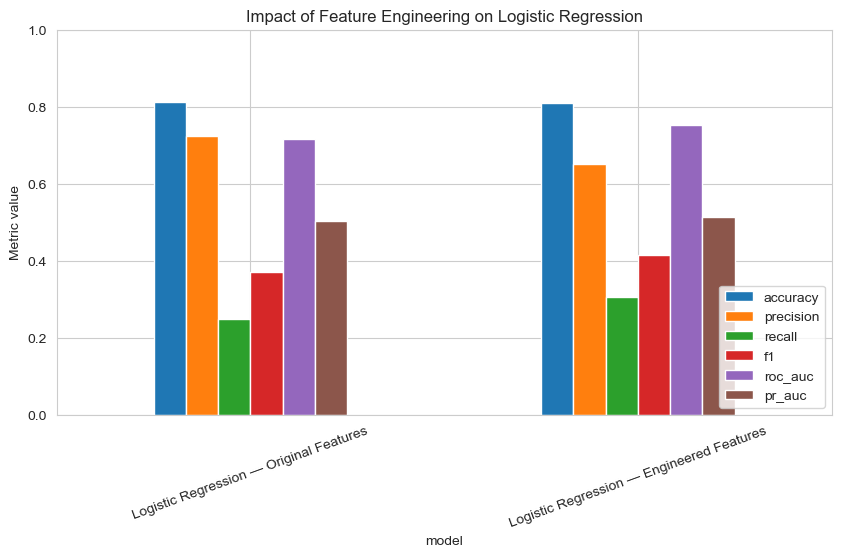

In [229]:
feature_engineering_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Impact of Feature Engineering on Logistic Regression")
plt.ylabel("Metric value")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## 8.7 Inspect Engineered Feature Coefficients

Because Logistic Regression is interpretable, we can check which engineered features matter most.

In [230]:
log_reg_fe_model = log_reg_fe_pipeline.named_steps["model"]

coef_fe_df = pd.DataFrame({
    "feature": X_fe.columns,
    "coefficient": log_reg_fe_model.coef_[0]
})

coef_fe_df["abs_coefficient"] = coef_fe_df["coefficient"].abs()

coef_fe_df = coef_fe_df.sort_values("abs_coefficient", ascending=False)

coef_fe_df.head(20)

,feature,coefficient,abs_coefficient
33,NUM_DELAYED_PAYMENTS,0.651737,0.651737
28,MAX_PAY_AMT,0.494261,0.494261
12,BILL_AMT2,0.290236,0.290236
25,MAX_BILL_AMT,-0.258868,0.258868
32,MAX_PAY_STATUS,0.245850,0.245850
29,PAY_TO_BILL_RATIO,-0.223995,0.223995
27,AVG_PAY_AMT,-0.205794,0.205794
26,TOTAL_PAY_AMT,-0.205794,0.205794
0,LIMIT_BAL,-0.202292,0.202292
17,PAY_AMT1,-0.194522,0.194522


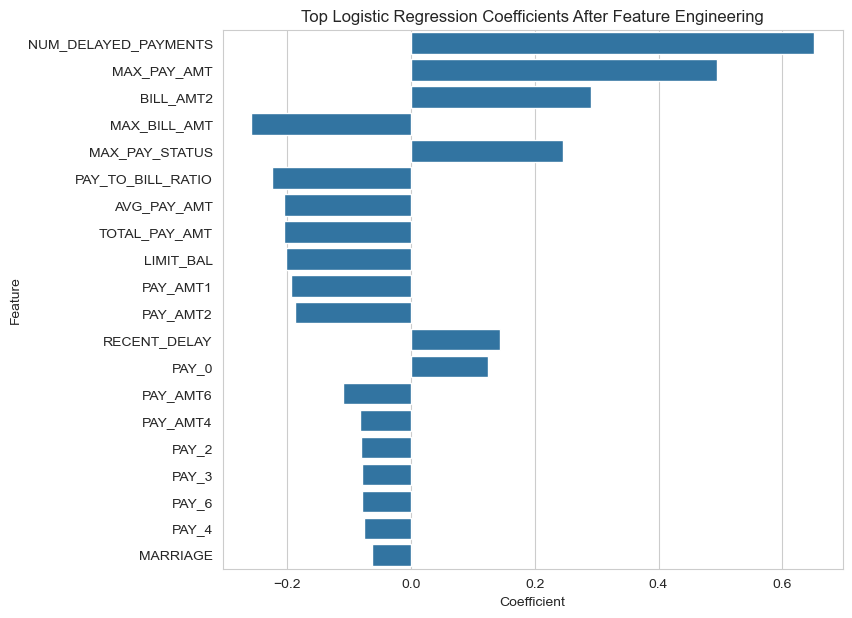

In [231]:
plt.figure(figsize=(8, 7))
sns.barplot(
    data=coef_fe_df.head(20),
    x="coefficient",
    y="feature"
)

plt.title("Top Logistic Regression Coefficients After Feature Engineering")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Positive coefficients increase predicted default probability.

Negative coefficients decrease predicted default probability.

Because features are standardized, coefficient magnitudes are more comparable.

## 8.8 Regularization Concept

Feature engineering increases the number of variables.

This may improve predictive power, but it can also increase overfitting risk.

Regularization helps control model complexity by penalizing large coefficients.

The regularized objective function can be written as:

\[
J(\theta) = L(\theta) + \lambda R(\theta)
\]

where:

- \(L(\theta)\) is the original loss function,
- \(R(\theta)\) is the regularization penalty,
- \(\lambda\) controls regularization strength.

## 8.9 L1 vs L2 Regularization

We will compare two common types of regularization:

### L1 Regularization — Lasso

\[
R(\theta)=\sum_{j=1}^{p}|\theta_j|
\]

L1 regularization can shrink some coefficients exactly to zero.  
This means it can perform feature selection.

### L2 Regularization — Ridge

\[
R(\theta)=\sum_{j=1}^{p}\theta_j^2
\]

L2 regularization shrinks coefficients toward zero, but usually does not set them exactly to zero.  
It is useful when many correlated variables are present.

## 8.10 Compare Regularization Strength

In scikit-learn, Logistic Regression uses parameter `C`.

Important:

- small `C` = stronger regularization,
- large `C` = weaker regularization.

In [232]:
regularization_results = []

for penalty in ["l1", "l2"]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("log_reg", LogisticRegression(
                    penalty=penalty,
                    C=C,
                    solver="liblinear",
                    max_iter=2000,
                    random_state=42
                ))
            ]
        )
        
        model.fit(X_fe_train, y_fe_train)
        
        pred = model.predict(X_fe_test)
        proba = model.predict_proba(X_fe_test)[:, 1]
        
        coefficients = model.named_steps["log_reg"].coef_[0]
        n_nonzero_coefficients = np.sum(coefficients != 0)
        
        regularization_results.append({
            "penalty": penalty,
            "C": C,
            "accuracy": accuracy_score(y_fe_test, pred),
            "precision": precision_score(y_fe_test, pred, zero_division=0),
            "recall": recall_score(y_fe_test, pred, zero_division=0),
            "f1": f1_score(y_fe_test, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_fe_test, proba),
            "pr_auc": average_precision_score(y_fe_test, proba),
            "nonzero_coefficients": n_nonzero_coefficients
        })

regularization_results = pd.DataFrame(regularization_results)

regularization_results.round(4)

,penalty,C,accuracy,precision,recall,f1,roc_auc,pr_auc,nonzero_coefficients
0,l1,0.001,0.8061,0.6708,0.2428,0.3566,0.7181,0.4699,3
1,l1,0.010,0.8063,0.6355,0.2919,0.4000,0.7462,0.5090,17
2,l1,0.100,0.8099,0.6511,0.3039,0.4144,0.7526,0.5133,27
3,l1,1.000,0.8101,0.6516,0.3047,0.4152,0.7528,0.5139,31
4,l1,10.000,0.8101,0.6521,0.3039,0.4146,0.7529,0.5140,34
5,l1,100.000,0.8101,0.6521,0.3039,0.4146,0.7529,0.5140,35
6,l2,0.001,0.8081,0.6183,0.3469,0.4444,0.7435,0.5118,35
7,l2,0.010,0.8093,0.6459,0.3054,0.4147,0.7518,0.5136,35
8,l2,0.100,0.8103,0.6532,0.3039,0.4148,0.7527,0.5139,35
9,l2,1.000,0.8101,0.6521,0.3039,0.4146,0.7529,0.5140,35


## 8.11 Visualize Regularization Impact

We visualize how regularization strength affects performance.

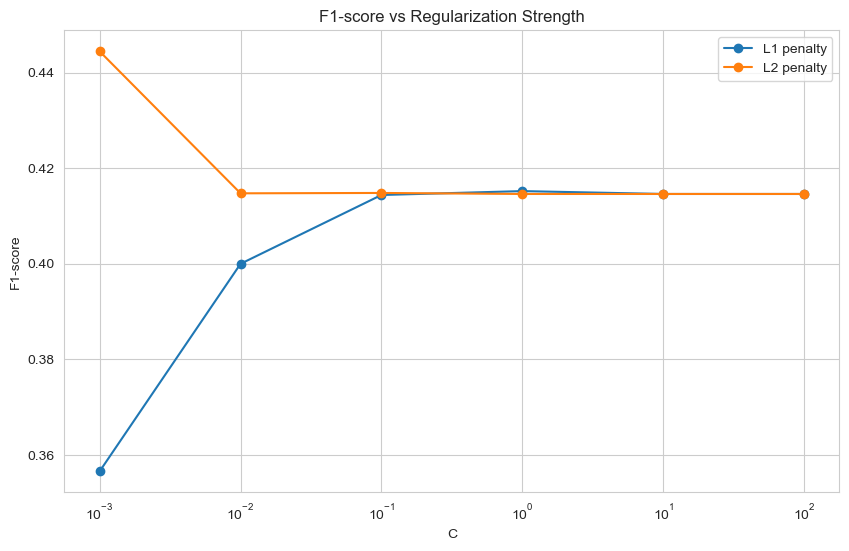

In [233]:
plt.figure(figsize=(10, 6))

for penalty in ["l1", "l2"]:
    subset = regularization_results[
        regularization_results["penalty"] == penalty
    ].sort_values("C")
    
    plt.plot(
        subset["C"],
        subset["f1"],
        marker="o",
        label=f"{penalty.upper()} penalty"
    )

plt.xscale("log")
plt.title("F1-score vs Regularization Strength")
plt.xlabel("C")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()

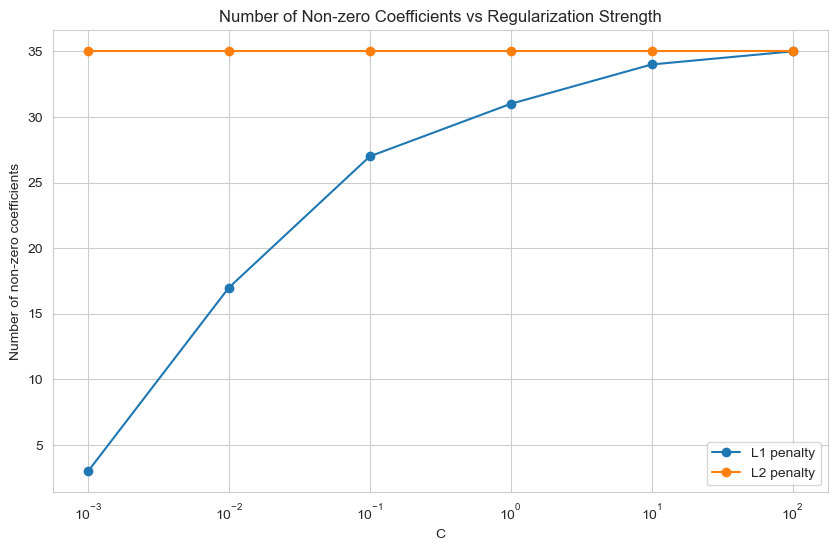

In [234]:
plt.figure(figsize=(10, 6))

for penalty in ["l1", "l2"]:
    subset = regularization_results[
        regularization_results["penalty"] == penalty
    ].sort_values("C")
    
    plt.plot(
        subset["C"],
        subset["nonzero_coefficients"],
        marker="o",
        label=f"{penalty.upper()} penalty"
    )

plt.xscale("log")
plt.title("Number of Non-zero Coefficients vs Regularization Strength")
plt.xlabel("C")
plt.ylabel("Number of non-zero coefficients")
plt.legend()
plt.grid(True)
plt.show()

The second plot is especially important.

For L1 regularization, strong regularization can reduce many coefficients exactly to zero.

This means L1 can act as a feature selection method.

## 8.12 Best Regularized Logistic Regression

We select the best regularized Logistic Regression model according to F1-score.

In [235]:
best_reg_row = regularization_results.loc[
    regularization_results["f1"].idxmax()
]

best_reg_row

penalty                       l2
C                          0.001
accuracy                0.808109
precision                0.61828
recall                  0.346908
f1                      0.444444
roc_auc                 0.743467
pr_auc                  0.511763
nonzero_coefficients          35
Name: 6, dtype: object

In [236]:
best_penalty = best_reg_row["penalty"]
best_C = best_reg_row["C"]

best_reg_log_reg_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("log_reg", LogisticRegression(
            penalty=best_penalty,
            C=best_C,
            solver="liblinear",
            max_iter=2000,
            random_state=42
        ))
    ]
)

best_reg_log_reg_pipeline.fit(X_fe_train, y_fe_train)

best_reg_pred = best_reg_log_reg_pipeline.predict(X_fe_test)
best_reg_proba = best_reg_log_reg_pipeline.predict_proba(X_fe_test)[:, 1]

In [237]:
best_reg_metrics = {
    "accuracy": accuracy_score(y_fe_test, best_reg_pred),
    "precision": precision_score(y_fe_test, best_reg_pred, zero_division=0),
    "recall": recall_score(y_fe_test, best_reg_pred, zero_division=0),
    "f1": f1_score(y_fe_test, best_reg_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_fe_test, best_reg_proba),
    "pr_auc": average_precision_score(y_fe_test, best_reg_proba)
}

pd.Series(best_reg_metrics).round(4)

accuracy     0.8081
precision    0.6183
recall       0.3469
f1           0.4444
roc_auc      0.7435
pr_auc       0.5118
dtype: float64

In [238]:
print(classification_report(y_fe_test, best_reg_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.84      0.94      0.88      4667
           1       0.62      0.35      0.44      1326

    accuracy                           0.81      5993
   macro avg       0.73      0.64      0.66      5993
weighted avg       0.79      0.81      0.79      5993



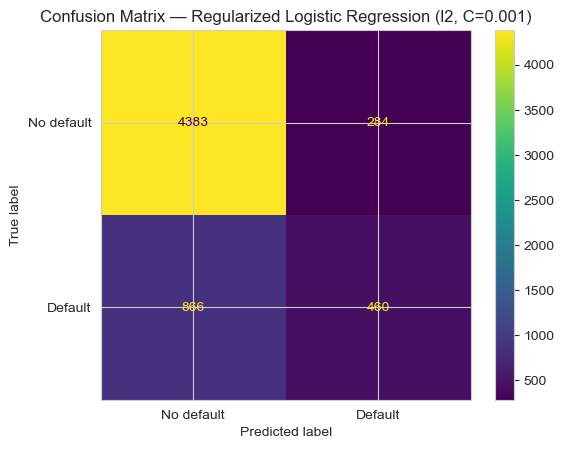

In [239]:
cm_best_reg = confusion_matrix(y_fe_test, best_reg_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_reg,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix — Regularized Logistic Regression ({best_penalty}, C={best_C})")
plt.show()

## 8.13 Coefficients After Regularization

Now we inspect which features remain important after regularization.

In [240]:
best_reg_model = best_reg_log_reg_pipeline.named_steps["log_reg"]

best_reg_coef_df = pd.DataFrame({
    "feature": X_fe.columns,
    "coefficient": best_reg_model.coef_[0]
})

best_reg_coef_df["abs_coefficient"] = best_reg_coef_df["coefficient"].abs()

best_reg_coef_df = best_reg_coef_df.sort_values("abs_coefficient", ascending=False)

best_reg_coef_df.head(20)

,feature,coefficient,abs_coefficient
33,NUM_DELAYED_PAYMENTS,0.340540,0.340540
34,RECENT_DELAY,0.242582,0.242582
32,MAX_PAY_STATUS,0.141282,0.141282
0,LIMIT_BAL,-0.108840,0.108840
5,PAY_0,0.094998,0.094998
17,PAY_AMT1,-0.056886,0.056886
26,TOTAL_PAY_AMT,-0.046842,0.046842
27,AVG_PAY_AMT,-0.046842,0.046842
18,PAY_AMT2,-0.043969,0.043969
3,MARRIAGE,-0.043616,0.043616


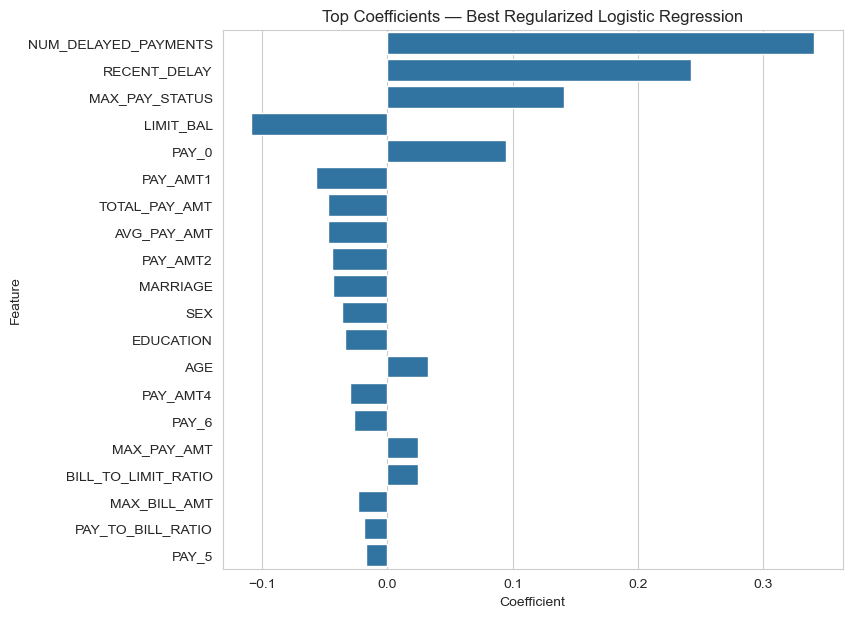

In [241]:
plt.figure(figsize=(8, 7))
sns.barplot(
    data=best_reg_coef_df.head(20),
    x="coefficient",
    y="feature"
)

plt.title("Top Coefficients — Best Regularized Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In [242]:
zero_coefficients = best_reg_coef_df[best_reg_coef_df["coefficient"] == 0]

print("Number of zero coefficients:", len(zero_coefficients))
print("Number of non-zero coefficients:", len(best_reg_coef_df) - len(zero_coefficients))

Number of zero coefficients: 0
Number of non-zero coefficients: 35


## 8.14 Polynomial Features

Some relationships may be nonlinear.

One way to allow a linear model to capture nonlinear patterns is to create polynomial and interaction features.

However, this can quickly increase model complexity and overfitting risk.

In [243]:
from sklearn.preprocessing import PolynomialFeatures

To keep this experiment computationally reasonable, we use only selected numerical features.

In [244]:
selected_poly_features = [
    "LIMIT_BAL",
    "AGE",
    "PAY_0",
    "PAY_2",
    "AVG_PAY_STATUS",
    "NUM_DELAYED_PAYMENTS",
    "BILL_TO_LIMIT_RATIO",
    "PAY_TO_BILL_RATIO"
]

X_poly_base = X_fe[selected_poly_features]

In [245]:
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly_base,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [246]:
poly_log_reg_pipeline = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("log_reg", LogisticRegression(
            penalty="l2",
            C=1,
            solver="liblinear",
            max_iter=3000,
            random_state=42
        ))
    ]
)

poly_log_reg_pipeline.fit(X_poly_train, y_poly_train)

poly_pred = poly_log_reg_pipeline.predict(X_poly_test)
poly_proba = poly_log_reg_pipeline.predict_proba(X_poly_test)[:, 1]

In [247]:
poly_metrics = {
    "accuracy": accuracy_score(y_poly_test, poly_pred),
    "precision": precision_score(y_poly_test, poly_pred, zero_division=0),
    "recall": recall_score(y_poly_test, poly_pred, zero_division=0),
    "f1": f1_score(y_poly_test, poly_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_poly_test, poly_proba),
    "pr_auc": average_precision_score(y_poly_test, poly_proba)
}

pd.Series(poly_metrics).round(4)

accuracy     0.8166
precision    0.6633
recall       0.3477
f1           0.4562
roc_auc      0.7576
pr_auc       0.5338
dtype: float64

In [248]:
poly_feature_names = poly_log_reg_pipeline.named_steps["poly"].get_feature_names_out(
    selected_poly_features
)

print("Original selected features:", len(selected_poly_features))
print("Polynomial features:", len(poly_feature_names))

Original selected features: 8
Polynomial features: 44


## 8.15 Compare Feature Engineering and Regularization Experiments

Now we compare several Logistic Regression variants.

In [249]:
fe_regularization_comparison = pd.DataFrame([
    {
        "model": "Original Logistic Regression",
        **baseline_metrics.to_dict()
    },
    {
        "model": "Engineered Features",
        **log_reg_fe_metrics
    },
    {
        "model": f"Regularized FE ({best_penalty}, C={best_C})",
        **best_reg_metrics
    },
    {
        "model": "Polynomial Features",
        **poly_metrics
    }
])

fe_regularization_comparison = fe_regularization_comparison.set_index("model")

fe_regularization_comparison.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Original Logistic Regression,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040
Engineered Features,0.8103,0.6527,0.3047,0.4154,0.7529,0.5139
"Regularized FE (l2, C=0.001)",0.8081,0.6183,0.3469,0.4444,0.7435,0.5118
Polynomial Features,0.8166,0.6633,0.3477,0.4562,0.7576,0.5338


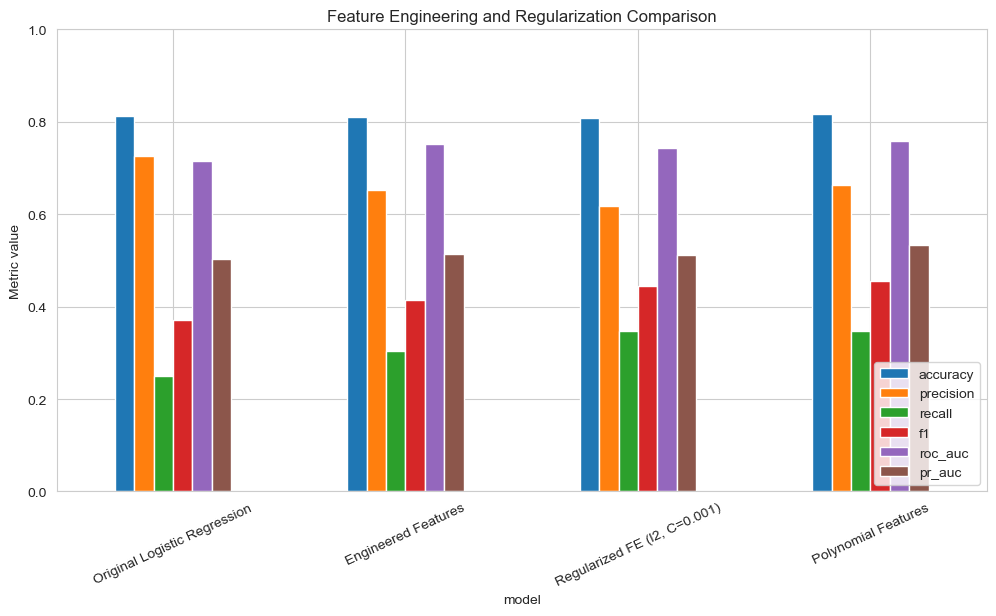

In [250]:
fe_regularization_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Feature Engineering and Regularization Comparison")
plt.ylabel("Metric value")
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## 8.16 ROC and PR Curves

We compare probability ranking quality for the feature-engineered and regularized models.

In [251]:
model_variants = {
    "Original Logistic Regression": (y_test, y_proba),
    "Engineered Features": (y_fe_test, log_reg_fe_proba),
    f"Regularized FE ({best_penalty}, C={best_C})": (y_fe_test, best_reg_proba),
    "Polynomial Features": (y_poly_test, poly_proba)
}

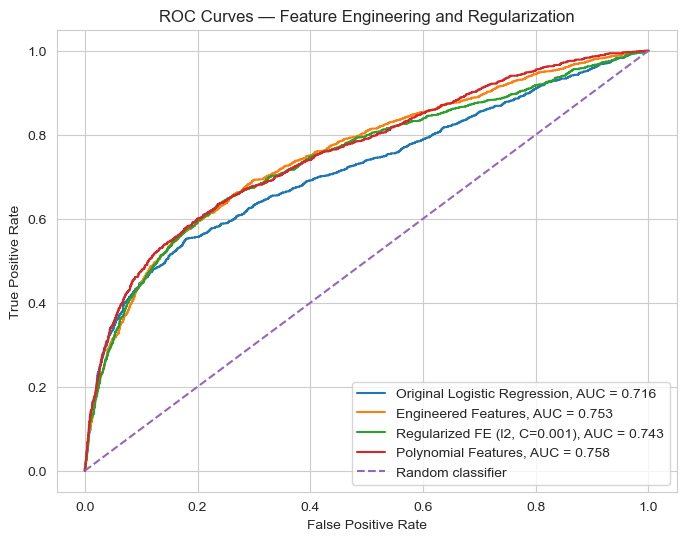

In [252]:
plt.figure(figsize=(8, 6))

for model_name, (y_true_variant, proba_variant) in model_variants.items():
    fpr, tpr, _ = roc_curve(y_true_variant, proba_variant)
    auc_score = roc_auc_score(y_true_variant, proba_variant)
    
    plt.plot(fpr, tpr, label=f"{model_name}, AUC = {auc_score:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.title("ROC Curves — Feature Engineering and Regularization")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

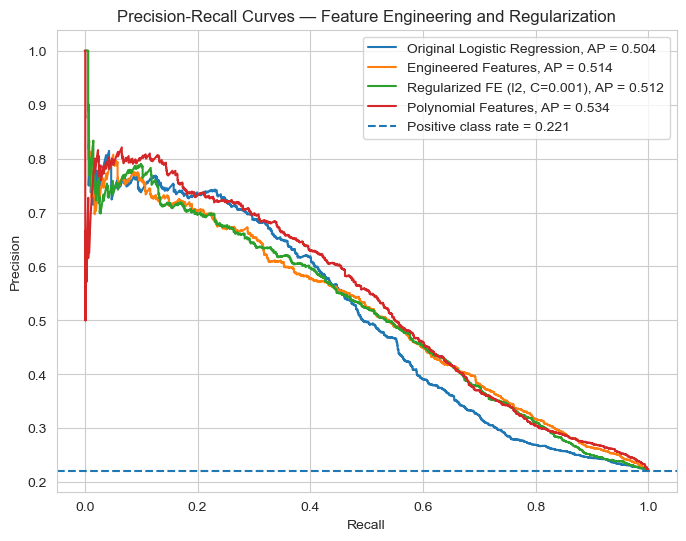

In [253]:
plt.figure(figsize=(8, 6))

for model_name, (y_true_variant, proba_variant) in model_variants.items():
    precision, recall, _ = precision_recall_curve(y_true_variant, proba_variant)
    ap_score = average_precision_score(y_true_variant, proba_variant)
    
    plt.plot(recall, precision, label=f"{model_name}, AP = {ap_score:.3f}")

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Positive class rate = {y_test.mean():.3f}"
)

plt.title("Precision-Recall Curves — Feature Engineering and Regularization")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

## 8.17 Add Best Regularized Model to Global Results

We store the best regularized Logistic Regression model for the final comparison.

In [254]:
results.append({
    "model": f"Regularized Logistic Regression FE ({best_penalty}, C={best_C})",
    "accuracy": accuracy_score(y_fe_test, best_reg_pred),
    "precision": precision_score(y_fe_test, best_reg_pred, zero_division=0),
    "recall": recall_score(y_fe_test, best_reg_pred, zero_division=0),
    "f1": f1_score(y_fe_test, best_reg_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_fe_test, best_reg_proba),
    "pr_auc": average_precision_score(y_fe_test, best_reg_proba)
})

results_df = pd.DataFrame(results)

results_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression Baseline,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040
1,"KNN, k = 13",0.8096,0.6279,0.3424,0.4431,0.7342,0.4688
2,"SVM RBF, C=1.0, gamma=0.1",0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
3,Tuned Logistic Regression,0.8104,0.7065,0.2451,0.3639,0.7130,0.5002
4,Tuned KNN,0.8073,0.6183,0.3371,0.4363,0.7376,0.4858
5,Tuned SVM Grid,0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
6,Tuned SVM Random,0.8185,0.6895,0.3265,0.4432,0.7076,0.5013
7,"Regularized Logistic Regression FE (l2, C=0.001)",0.8081,0.6183,0.3469,0.4444,0.7435,0.5118


## 8.18 Feature Engineering & Regularization Summary

Main conclusions:

- Raw variables are not always the best representation of the business problem.
- Business-inspired features can summarize repayment behavior more effectively.
- Feature engineering may improve model performance, but it can also increase complexity.
- Regularization controls coefficient size and helps reduce overfitting.
- L1 regularization can perform feature selection by setting coefficients to zero.
- L2 regularization is useful when many correlated variables are present.
- Polynomial features can capture nonlinearities, but they increase dimensionality quickly.
- Feature engineering and regularization should be evaluated empirically, not assumed to help automatically.

In the next section, we will focus on imbalanced learning and methods for improving default detection.

# 9. Imbalanced Learning

In credit default prediction, the positive class is usually much smaller than the negative class.

This creates an imbalanced classification problem.

In our case:

- class `0`: client did not default,
- class `1`: client defaulted.

The minority class is often the class we care about most.

## 9.1 Why Class Imbalance Matters

Class imbalance affects machine learning in two main ways:

1. **Training problem**  
   The model may focus mostly on the majority class.

2. **Evaluation problem**  
   Metrics such as accuracy may look good even when the model performs poorly on the minority class.

In credit risk, this is dangerous because undetected defaulters may generate direct financial losses.

## 9.2 Target Distribution Reminder

First, let us inspect the class distribution again.

In [255]:
class_counts = y.value_counts().sort_index()
class_share = y.value_counts(normalize=True).sort_index()

class_distribution = pd.DataFrame({
    "count": class_counts,
    "share": class_share
})

class_distribution

,count,share
default,,
0,23335,0.778742
1,6630,0.221258


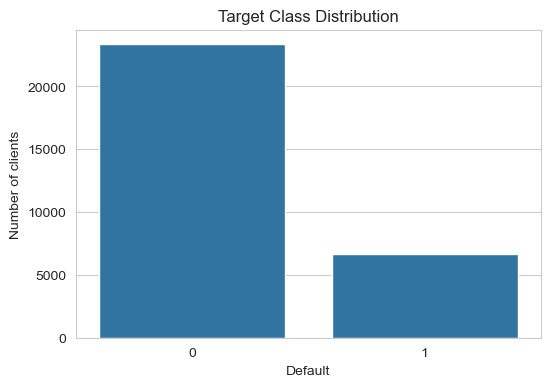

In [256]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)

plt.title("Target Class Distribution")
plt.xlabel("Default")
plt.ylabel("Number of clients")
plt.show()

In [257]:
imbalance_ratio = class_counts[0] / class_counts[1]

print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Imbalance ratio: 3.52:1


The imbalance ratio tells us how many non-default clients we have for each default client.

The larger this ratio, the more careful we need to be with evaluation and training strategy.

## 9.3 Baseline Problem: Low Recall for Defaulters

Before applying imbalance techniques, let us recall how the baseline model performs on the minority class.

In [258]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.73      0.25      0.37      1326

    accuracy                           0.81      5993
   macro avg       0.77      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993



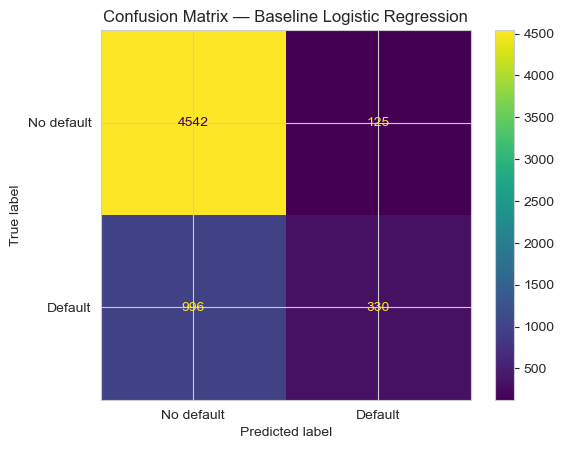

In [259]:
cm_baseline = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.show()

In imbalanced classification, we often observe that recall for the minority class is too low.

This means that many actual defaulters are predicted as non-defaulters.

## 9.4 Strategy 1: Class Weights

The first approach is to modify the learning algorithm by assigning higher weight to the minority class.

This makes mistakes on defaulters more costly during training.

In [261]:
class_weight="balanced"

weighted_log_reg_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

weighted_log_reg_pipeline.fit(X_train, y_train)

weighted_pred = weighted_log_reg_pipeline.predict(X_test)
weighted_proba = weighted_log_reg_pipeline.predict_proba(X_test)[:, 1]

In [262]:
weighted_metrics = {
    "accuracy": accuracy_score(y_test, weighted_pred),
    "precision": precision_score(y_test, weighted_pred, zero_division=0),
    "recall": recall_score(y_test, weighted_pred, zero_division=0),
    "f1": f1_score(y_test, weighted_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, weighted_proba),
    "pr_auc": average_precision_score(y_test, weighted_proba)
}

pd.Series(weighted_metrics).round(4)

accuracy     0.6865
precision    0.3756
recall       0.6297
f1           0.4706
roc_auc      0.7162
pr_auc       0.5015
dtype: float64

In [263]:
print(classification_report(y_test, weighted_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4667
           1       0.38      0.63      0.47      1326

    accuracy                           0.69      5993
   macro avg       0.62      0.67      0.62      5993
weighted avg       0.76      0.69      0.71      5993



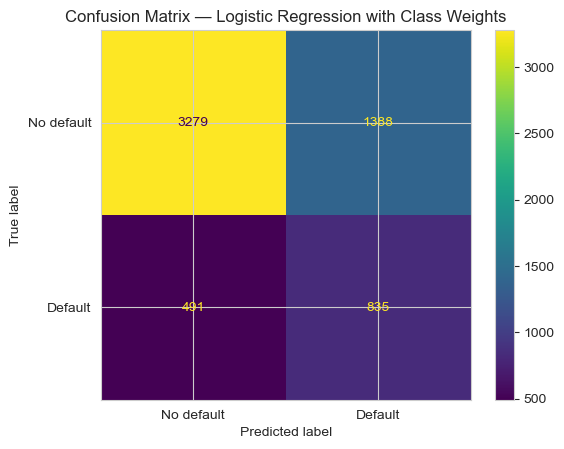

In [264]:
cm_weighted = confusion_matrix(y_test, weighted_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_weighted,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression with Class Weights")
plt.show()

Class weighting usually increases recall for the minority class.

However, it may reduce precision because the model predicts more clients as risky.

## 9.5 Strategy 2: Random Undersampling

Random undersampling reduces the number of majority-class observations.

This creates a more balanced training set.

Main advantage:

- simple and fast.

Main disadvantage:

- we may discard useful information from the majority class.

In [265]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [266]:
undersampling_pipeline = ImbPipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("sampler", RandomUnderSampler(random_state=42)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

undersampling_pipeline.fit(X_train, y_train)

undersampling_pred = undersampling_pipeline.predict(X_test)
undersampling_proba = undersampling_pipeline.predict_proba(X_test)[:, 1]

In [267]:
undersampling_metrics = {
    "accuracy": accuracy_score(y_test, undersampling_pred),
    "precision": precision_score(y_test, undersampling_pred, zero_division=0),
    "recall": recall_score(y_test, undersampling_pred, zero_division=0),
    "f1": f1_score(y_test, undersampling_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, undersampling_proba),
    "pr_auc": average_precision_score(y_test, undersampling_proba)
}

pd.Series(undersampling_metrics).round(4)

accuracy     0.6891
precision    0.3770
recall       0.6207
f1           0.4691
roc_auc      0.7143
pr_auc       0.4993
dtype: float64

In [268]:
print(classification_report(y_test, undersampling_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.87      0.71      0.78      4667
           1       0.38      0.62      0.47      1326

    accuracy                           0.69      5993
   macro avg       0.62      0.66      0.62      5993
weighted avg       0.76      0.69      0.71      5993



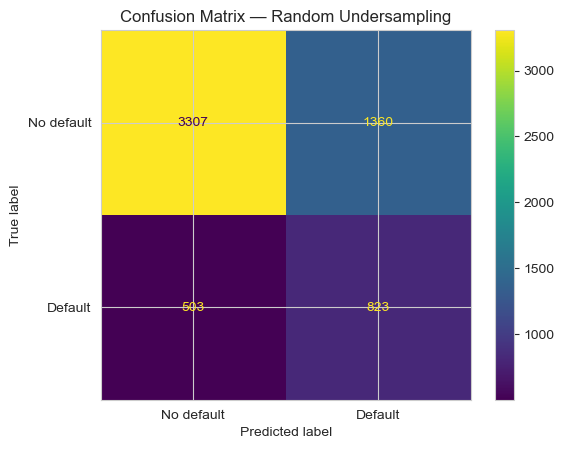

In [269]:
cm_undersampling = confusion_matrix(y_test, undersampling_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_undersampling,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Random Undersampling")
plt.show()

## 9.6 Strategy 3: Random Oversampling

Random oversampling increases the number of minority-class observations by duplicating them.

Main advantage:

- no majority-class information is removed.

Main disadvantage:

- duplicated observations may increase overfitting risk.

In [270]:
from imblearn.over_sampling import RandomOverSampler

In [271]:
oversampling_pipeline = ImbPipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("sampler", RandomOverSampler(random_state=42)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

oversampling_pipeline.fit(X_train, y_train)

oversampling_pred = oversampling_pipeline.predict(X_test)
oversampling_proba = oversampling_pipeline.predict_proba(X_test)[:, 1]

In [272]:
oversampling_metrics = {
    "accuracy": accuracy_score(y_test, oversampling_pred),
    "precision": precision_score(y_test, oversampling_pred, zero_division=0),
    "recall": recall_score(y_test, oversampling_pred, zero_division=0),
    "f1": f1_score(y_test, oversampling_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, oversampling_proba),
    "pr_auc": average_precision_score(y_test, oversampling_proba)
}

pd.Series(oversampling_metrics).round(4)

accuracy     0.6865
precision    0.3746
recall       0.6229
f1           0.4679
roc_auc      0.7161
pr_auc       0.5011
dtype: float64

In [273]:
print(classification_report(y_test, oversampling_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4667
           1       0.37      0.62      0.47      1326

    accuracy                           0.69      5993
   macro avg       0.62      0.66      0.62      5993
weighted avg       0.76      0.69      0.71      5993



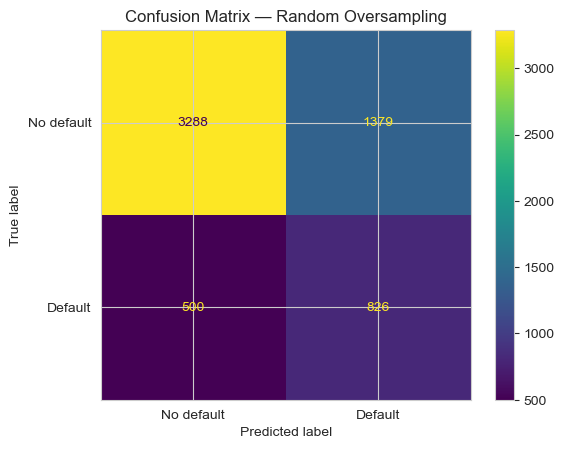

In [274]:
cm_oversampling = confusion_matrix(y_test, oversampling_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_oversampling,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Random Oversampling")
plt.show()

## 9.7 Strategy 4: SMOTE

SMOTE stands for **Synthetic Minority Oversampling Technique**.

Instead of simply duplicating minority observations, SMOTE creates synthetic minority-class examples.

It generates new observations between existing minority-class observations and their nearest neighbors.

This can help the model learn a broader minority-class region.

In [275]:
from imblearn.over_sampling import SMOTE

In [276]:
smote_pipeline = ImbPipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("sampler", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

smote_pipeline.fit(X_train, y_train)

smote_pred = smote_pipeline.predict(X_test)
smote_proba = smote_pipeline.predict_proba(X_test)[:, 1]

In [277]:
smote_metrics = {
    "accuracy": accuracy_score(y_test, smote_pred),
    "precision": precision_score(y_test, smote_pred, zero_division=0),
    "recall": recall_score(y_test, smote_pred, zero_division=0),
    "f1": f1_score(y_test, smote_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, smote_proba),
    "pr_auc": average_precision_score(y_test, smote_proba)
}

pd.Series(smote_metrics).round(4)

accuracy     0.6781
precision    0.3681
recall       0.6342
f1           0.4658
roc_auc      0.7158
pr_auc       0.5000
dtype: float64

In [278]:
print(classification_report(y_test, smote_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.87      0.69      0.77      4667
           1       0.37      0.63      0.47      1326

    accuracy                           0.68      5993
   macro avg       0.62      0.66      0.62      5993
weighted avg       0.76      0.68      0.70      5993



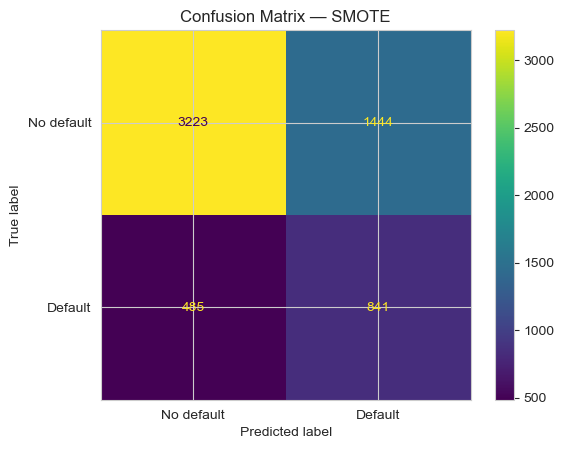

In [279]:
cm_smote = confusion_matrix(y_test, smote_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=["No default", "Default"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — SMOTE")
plt.show()

SMOTE often increases recall.

However, it can also reduce precision if the model starts predicting too many clients as defaulters.

This is not necessarily bad — it depends on the business cost structure.

## 9.8 Important Rule: Resampling Must Be Inside the Pipeline

Resampling should be applied only to the training data.

We should never oversample or undersample the test set.

Putting the sampler inside an imbalanced-learn pipeline helps prevent data leakage during cross-validation.

Correct approach:

```python
Pipeline:
1. scale training fold
2. resample training fold
3. train model
4. evaluate on untouched validation fold

Incorrect approach:
    
1. resample full dataset
2. split into train and test


## 9.9 Cross-Validation With SMOTE

Now we evaluate SMOTE using cross-validation.

The sampler is inside the pipeline, so resampling is performed separately within each training fold.

In [280]:
smote_cv_pipeline = ImbPipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("sampler", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

In [281]:
smote_cv_scores = cross_validate(
    smote_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

In [282]:
smote_cv_results = pd.DataFrame(smote_cv_scores)

smote_cv_summary = (
    smote_cv_results
    .filter(regex="test_")
    .agg(["mean", "std"])
    .T
)

smote_cv_summary.index = smote_cv_summary.index.str.replace("test_", "")

smote_cv_summary.round(4)

,mean,std
accuracy,0.6816,0.0072
precision,0.3739,0.0067
recall,0.6508,0.0227
f1,0.4749,0.0086
roc_auc,0.7266,0.0118
pr_auc,0.4999,0.0164


Cross-validation gives us a more reliable estimate of how the resampling strategy behaves.

## 9.10 Compare Imbalanced Learning Strategies

Now we compare:

- baseline Logistic Regression,
- class weights,
- random undersampling,
- random oversampling,
- SMOTE.

In [283]:
imbalance_comparison = pd.DataFrame([
    {
        "model": "Baseline Logistic Regression",
        **baseline_metrics.to_dict()
    },
    {
        "model": "Class Weight Balanced",
        **weighted_metrics
    },
    {
        "model": "Random Undersampling",
        **undersampling_metrics
    },
    {
        "model": "Random Oversampling",
        **oversampling_metrics
    },
    {
        "model": "SMOTE",
        **smote_metrics
    }
])

imbalance_comparison = imbalance_comparison.set_index("model")

imbalance_comparison.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Baseline Logistic Regression,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040
Class Weight Balanced,0.6865,0.3756,0.6297,0.4706,0.7162,0.5015
Random Undersampling,0.6891,0.3770,0.6207,0.4691,0.7143,0.4993
Random Oversampling,0.6865,0.3746,0.6229,0.4679,0.7161,0.5011
SMOTE,0.6781,0.3681,0.6342,0.4658,0.7158,0.5000


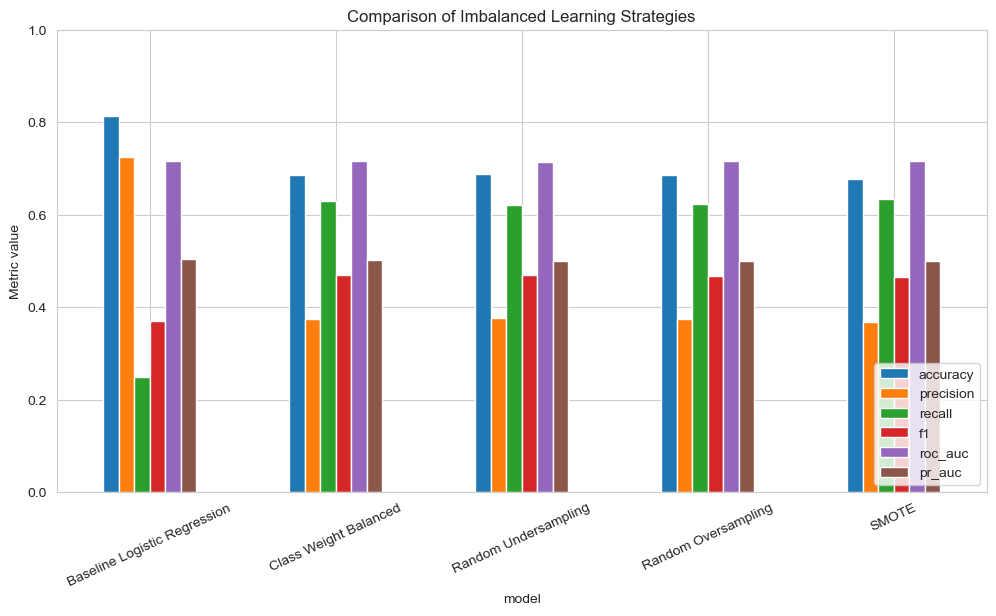

In [284]:
imbalance_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Imbalanced Learning Strategies")
plt.ylabel("Metric value")
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

The key trade-off is usually:

- higher recall,
- lower precision.

This means the model detects more defaulters, but also produces more false alarms.

## 9.11 Precision-Recall Trade-off

Because the main goal is to detect defaulters, we compare Precision-Recall curves.

In [285]:
imbalance_models = {
    "Baseline": (y_test, y_proba),
    "Class Weights": (y_test, weighted_proba),
    "Undersampling": (y_test, undersampling_proba),
    "Oversampling": (y_test, oversampling_proba),
    "SMOTE": (y_test, smote_proba)
}

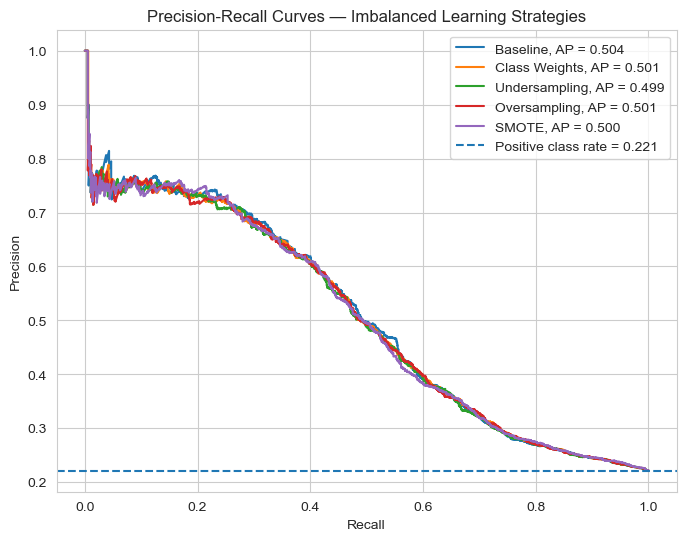

In [286]:
plt.figure(figsize=(8, 6))

for model_name, (y_true_model, proba_model) in imbalance_models.items():
    precision, recall, _ = precision_recall_curve(y_true_model, proba_model)
    ap_score = average_precision_score(y_true_model, proba_model)
    
    plt.plot(recall, precision, label=f"{model_name}, AP = {ap_score:.3f}")

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Positive class rate = {y_test.mean():.3f}"
)

plt.title("Precision-Recall Curves — Imbalanced Learning Strategies")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

## 9.12 ROC Curves

We also compare ROC curves, but remember that PR curves are usually more informative for imbalanced classification.

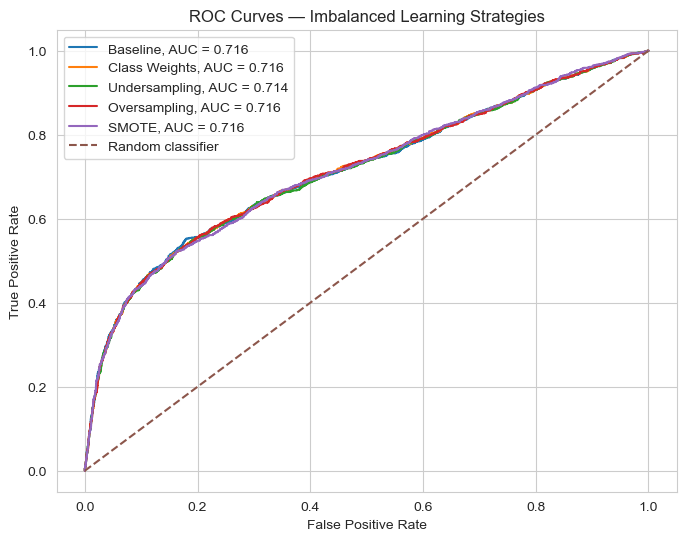

In [287]:
plt.figure(figsize=(8, 6))

for model_name, (y_true_model, proba_model) in imbalance_models.items():
    fpr, tpr, _ = roc_curve(y_true_model, proba_model)
    auc_score = roc_auc_score(y_true_model, proba_model)
    
    plt.plot(fpr, tpr, label=f"{model_name}, AUC = {auc_score:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.title("ROC Curves — Imbalanced Learning Strategies")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

## 9.13 Threshold Tuning After Imbalanced Learning

Even after using imbalance methods, threshold tuning remains important.

Here we tune the threshold for the SMOTE model.

In [288]:
smote_threshold_results = []

for threshold in np.arange(0.01, 1.00, 0.01):
    pred_threshold = (smote_proba >= threshold).astype(int)
    
    smote_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_threshold),
        "precision": precision_score(y_test, pred_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_threshold, zero_division=0),
        "f1": f1_score(y_test, pred_threshold, zero_division=0)
    })

smote_threshold_results = pd.DataFrame(smote_threshold_results)

smote_threshold_results.head()

,threshold,accuracy,precision,recall,f1
0,0.01,0.223761,0.221627,0.998492,0.362740
1,0.02,0.225763,0.221980,0.997738,0.363162
2,0.03,0.228433,0.222484,0.996983,0.363786
3,0.04,0.229768,0.222690,0.996229,0.364012
4,0.05,0.231604,0.222917,0.994721,0.364214


In [289]:
smote_threshold_results = []

for threshold in np.arange(0.01, 1.00, 0.01):
    pred_threshold = (smote_proba >= threshold).astype(int)
    
    smote_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_threshold),
        "precision": precision_score(y_test, pred_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_threshold, zero_division=0),
        "f1": f1_score(y_test, pred_threshold, zero_division=0)
    })

smote_threshold_results = pd.DataFrame(smote_threshold_results)

smote_threshold_results.head()

,threshold,accuracy,precision,recall,f1
0,0.01,0.223761,0.221627,0.998492,0.362740
1,0.02,0.225763,0.221980,0.997738,0.363162
2,0.03,0.228433,0.222484,0.996983,0.363786
3,0.04,0.229768,0.222690,0.996229,0.364012
4,0.05,0.231604,0.222917,0.994721,0.364214


## 9.14 Choose Threshold for High Recall

Suppose the bank wants to detect at least 75% of defaulters.

Among thresholds satisfying this requirement, we choose the one with the highest precision.

In [290]:
min_recall = 0.75

smote_candidates = smote_threshold_results[
    smote_threshold_results["recall"] >= min_recall
]

smote_candidates.sort_values("precision", ascending=False).head()

,threshold,accuracy,precision,recall,f1
40,0.41,0.528617,0.286285,0.757164,0.415477
39,0.40,0.514434,0.281577,0.769985,0.412359
38,0.39,0.501919,0.278386,0.785822,0.411126
37,0.38,0.490739,0.275377,0.797888,0.409443
36,0.37,0.475388,0.271263,0.812971,0.406792


In [291]:
if len(smote_candidates) > 0:
    smote_business_row = smote_candidates.sort_values("precision", ascending=False).iloc[0]
    smote_business_threshold = smote_business_row["threshold"]

    smote_business_pred = (smote_proba >= smote_business_threshold).astype(int)

    print("Selected threshold:", round(smote_business_threshold, 3))
    print(classification_report(y_test, smote_business_pred, zero_division=0))
else:
    print("No threshold satisfies the minimum recall requirement.")

Selected threshold: 0.41
              precision    recall  f1-score   support

           0       0.87      0.46      0.61      4667
           1       0.29      0.76      0.42      1326

    accuracy                           0.53      5993
   macro avg       0.58      0.61      0.51      5993
weighted avg       0.74      0.53      0.56      5993



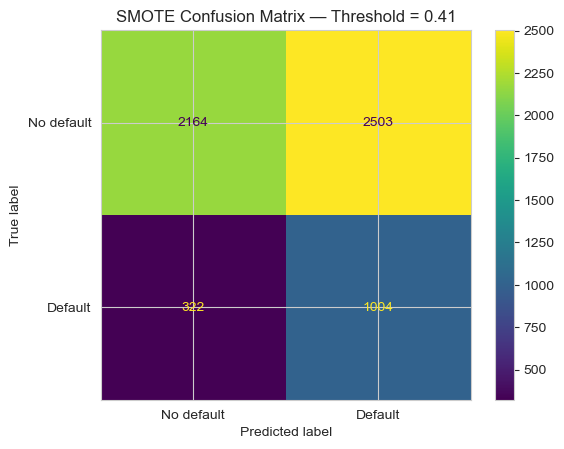

In [292]:
if len(smote_candidates) > 0:
    cm_smote_business = confusion_matrix(y_test, smote_business_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_smote_business,
        display_labels=["No default", "Default"]
    )

    disp.plot(values_format="d")
    plt.title(f"SMOTE Confusion Matrix — Threshold = {smote_business_threshold:.2f}")
    plt.show()

This example shows that class balancing and threshold tuning solve different problems.

- class balancing changes how the model is trained,
- threshold tuning changes how probabilities are converted into decisions.

## 9.15 Business Interpretation

There is no universally best imbalance strategy.

The right choice depends on business costs.

If False Negatives are very expensive, we may prefer:

- high recall,
- lower threshold,
- class weights or resampling.

If False Positives are expensive, we may prefer:

- higher precision,
- higher threshold,
- more conservative model behavior.

In [293]:
business_comparison = []

strategies = {
    "Baseline threshold 0.5": y_pred,
    "Class weights threshold 0.5": weighted_pred,
    "SMOTE threshold 0.5": smote_pred
}

if len(smote_candidates) > 0:
    strategies[f"SMOTE threshold {smote_business_threshold:.2f}"] = smote_business_pred

for name, pred in strategies.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    
    business_comparison.append({
        "strategy": name,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0)
    })

business_comparison = pd.DataFrame(business_comparison)

business_comparison.round(4)

,strategy,true_negatives,false_positives,false_negatives,true_positives,precision,recall,f1
0,Baseline threshold 0.5,4542,125,996,330,0.7253,0.2489,0.3706
1,Class weights threshold 0.5,3279,1388,491,835,0.3756,0.6297,0.4706
2,SMOTE threshold 0.5,3223,1444,485,841,0.3681,0.6342,0.4658
3,SMOTE threshold 0.41,2164,2503,322,1004,0.2863,0.7572,0.4155


## 9.16 Optional: Simple Cost-Based Evaluation

To connect model evaluation with business impact, we can define simple hypothetical costs.

For example:

- False Negative cost = 5
- False Positive cost = 1

This means missing a defaulter is assumed to be five times more costly than falsely flagging a safe client.

In [294]:
false_negative_cost = 5
false_positive_cost = 1

In [295]:
cost_results = []

for name, pred in strategies.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    
    total_cost = fp * false_positive_cost + fn * false_negative_cost
    
    cost_results.append({
        "strategy": name,
        "false_positives": fp,
        "false_negatives": fn,
        "total_cost": total_cost
    })

cost_results = pd.DataFrame(cost_results)

cost_results.sort_values("total_cost")

,strategy,false_positives,false_negatives,total_cost
1,Class weights threshold 0.5,1388,491,3843
2,SMOTE threshold 0.5,1444,485,3869
3,SMOTE threshold 0.41,2503,322,4113
0,Baseline threshold 0.5,125,996,5105


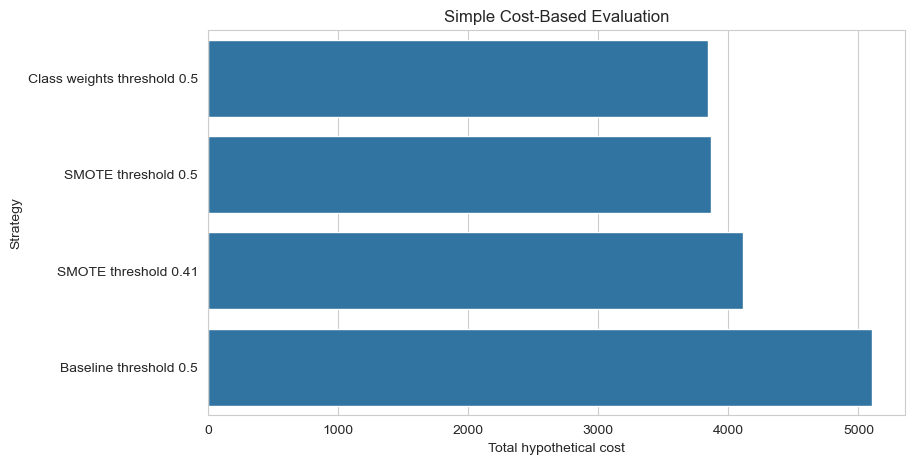

In [296]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=cost_results.sort_values("total_cost"),
    x="total_cost",
    y="strategy"
)

plt.title("Simple Cost-Based Evaluation")
plt.xlabel("Total hypothetical cost")
plt.ylabel("Strategy")
plt.show()

This is not a real financial cost model.

However, it demonstrates a crucial idea:

> the best model depends on the cost of different types of errors.

## 9.17 Add Best Imbalanced Model to Global Results

We store the selected imbalanced-learning strategy for final comparison.

In [297]:
if len(smote_candidates) > 0:
    selected_imbalance_model_name = f"SMOTE + threshold {smote_business_threshold:.2f}"
    selected_imbalance_pred = smote_business_pred
    selected_imbalance_proba = smote_proba
else:
    selected_imbalance_model_name = "SMOTE"
    selected_imbalance_pred = smote_pred
    selected_imbalance_proba = smote_proba

In [298]:
results.append({
    "model": selected_imbalance_model_name,
    "accuracy": accuracy_score(y_test, selected_imbalance_pred),
    "precision": precision_score(y_test, selected_imbalance_pred, zero_division=0),
    "recall": recall_score(y_test, selected_imbalance_pred, zero_division=0),
    "f1": f1_score(y_test, selected_imbalance_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, selected_imbalance_proba),
    "pr_auc": average_precision_score(y_test, selected_imbalance_proba)
})

results_df = pd.DataFrame(results)

results_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression Baseline,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040
1,"KNN, k = 13",0.8096,0.6279,0.3424,0.4431,0.7342,0.4688
2,"SVM RBF, C=1.0, gamma=0.1",0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
3,Tuned Logistic Regression,0.8104,0.7065,0.2451,0.3639,0.7130,0.5002
4,Tuned KNN,0.8073,0.6183,0.3371,0.4363,0.7376,0.4858
5,Tuned SVM Grid,0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
6,Tuned SVM Random,0.8185,0.6895,0.3265,0.4432,0.7076,0.5013
7,"Regularized Logistic Regression FE (l2, C=0.001)",0.8081,0.6183,0.3469,0.4444,0.7435,0.5118
8,SMOTE + threshold 0.41,0.5286,0.2863,0.7572,0.4155,0.7158,0.5000


## 9.18 Imbalanced Learning Summary

Main conclusions:

- Credit default prediction is naturally imbalanced.
- Accuracy can hide poor minority-class performance.
- Class weights modify the learning objective.
- Undersampling removes majority-class observations.
- Oversampling duplicates minority-class observations.
- SMOTE creates synthetic minority-class observations.
- Resampling must be performed only on training data.
- Pipelines help prevent data leakage.
- Imbalance handling often increases recall but lowers precision.
- Threshold tuning remains necessary after resampling.
- The best strategy depends on business costs.

In the next section, we will compare all models and summarize the final lessons from the case study.

# 10. Final Model Comparison

We have now trained and evaluated several classification models and modeling strategies.

The goal of this section is to compare them in one place and decide which approach is most useful from a business perspective.

We will compare models using:

- accuracy,
- precision,
- recall,
- F1-score,
- ROC AUC,
- PR AUC.

However, we will not choose the final model based only on one metric.

## 10.1 Prepare Final Results Table

Throughout the notebook, we stored model results in the `results` list.

Now we convert it into a clean comparison table.

In [299]:
final_results_df = pd.DataFrame(results)

final_results_df = final_results_df.drop_duplicates(
    subset=["model"],
    keep="last"
)

final_results_df = final_results_df.reset_index(drop=True)

final_results_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression Baseline,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040
1,"KNN, k = 13",0.8096,0.6279,0.3424,0.4431,0.7342,0.4688
2,"SVM RBF, C=1.0, gamma=0.1",0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
3,Tuned Logistic Regression,0.8104,0.7065,0.2451,0.3639,0.7130,0.5002
4,Tuned KNN,0.8073,0.6183,0.3371,0.4363,0.7376,0.4858
5,Tuned SVM Grid,0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
6,Tuned SVM Random,0.8185,0.6895,0.3265,0.4432,0.7076,0.5013
7,"Regularized Logistic Regression FE (l2, C=0.001)",0.8081,0.6183,0.3469,0.4444,0.7435,0.5118
8,SMOTE + threshold 0.41,0.5286,0.2863,0.7572,0.4155,0.7158,0.5000


In [300]:
final_results_df.sort_values("f1", ascending=False).round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,"SVM RBF, C=1.0, gamma=0.1",0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
5,Tuned SVM Grid,0.8171,0.6758,0.3333,0.4465,0.7127,0.4989
7,"Regularized Logistic Regression FE (l2, C=0.001)",0.8081,0.6183,0.3469,0.4444,0.7435,0.5118
6,Tuned SVM Random,0.8185,0.6895,0.3265,0.4432,0.7076,0.5013
1,"KNN, k = 13",0.8096,0.6279,0.3424,0.4431,0.7342,0.4688
4,Tuned KNN,0.8073,0.6183,0.3371,0.4363,0.7376,0.4858
8,SMOTE + threshold 0.41,0.5286,0.2863,0.7572,0.4155,0.7158,0.5000
0,Logistic Regression Baseline,0.8129,0.7253,0.2489,0.3706,0.7158,0.5040
3,Tuned Logistic Regression,0.8104,0.7065,0.2451,0.3639,0.7130,0.5002


## 10.2 Rank Models by Different Metrics

Different metrics may lead to different model rankings.

This is important because there is no universally best model.

In [301]:
metrics_to_rank = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

for metric in metrics_to_rank:
    print(f"\nTop models by {metric}:")
    display(
        final_results_df
        .sort_values(metric, ascending=False)
        [["model", metric]]
        .head(5)
        .round(4)
    )


Top models by accuracy:


,model,accuracy
6,Tuned SVM Random,0.8185
2,"SVM RBF, C=1.0, gamma=0.1",0.8171
5,Tuned SVM Grid,0.8171
0,Logistic Regression Baseline,0.8129
3,Tuned Logistic Regression,0.8104



Top models by precision:


,model,precision
0,Logistic Regression Baseline,0.7253
3,Tuned Logistic Regression,0.7065
6,Tuned SVM Random,0.6895
2,"SVM RBF, C=1.0, gamma=0.1",0.6758
5,Tuned SVM Grid,0.6758



Top models by recall:


,model,recall
8,SMOTE + threshold 0.41,0.7572
7,"Regularized Logistic Regression FE (l2, C=0.001)",0.3469
1,"KNN, k = 13",0.3424
4,Tuned KNN,0.3371
2,"SVM RBF, C=1.0, gamma=0.1",0.3333



Top models by f1:


,model,f1
2,"SVM RBF, C=1.0, gamma=0.1",0.4465
5,Tuned SVM Grid,0.4465
7,"Regularized Logistic Regression FE (l2, C=0.001)",0.4444
6,Tuned SVM Random,0.4432
1,"KNN, k = 13",0.4431



Top models by roc_auc:


,model,roc_auc
7,"Regularized Logistic Regression FE (l2, C=0.001)",0.7435
4,Tuned KNN,0.7376
1,"KNN, k = 13",0.7342
0,Logistic Regression Baseline,0.7158
8,SMOTE + threshold 0.41,0.7158



Top models by pr_auc:


,model,pr_auc
7,"Regularized Logistic Regression FE (l2, C=0.001)",0.5118
0,Logistic Regression Baseline,0.5040
6,Tuned SVM Random,0.5013
3,Tuned Logistic Regression,0.5002
8,SMOTE + threshold 0.41,0.5000


A model with the highest accuracy is not necessarily the best model for credit risk.

For this use case, recall and PR AUC may be more relevant because we care about detecting defaulters.

## 10.3 Visual Comparison of All Models

A bar chart allows us to compare model performance across multiple metrics.

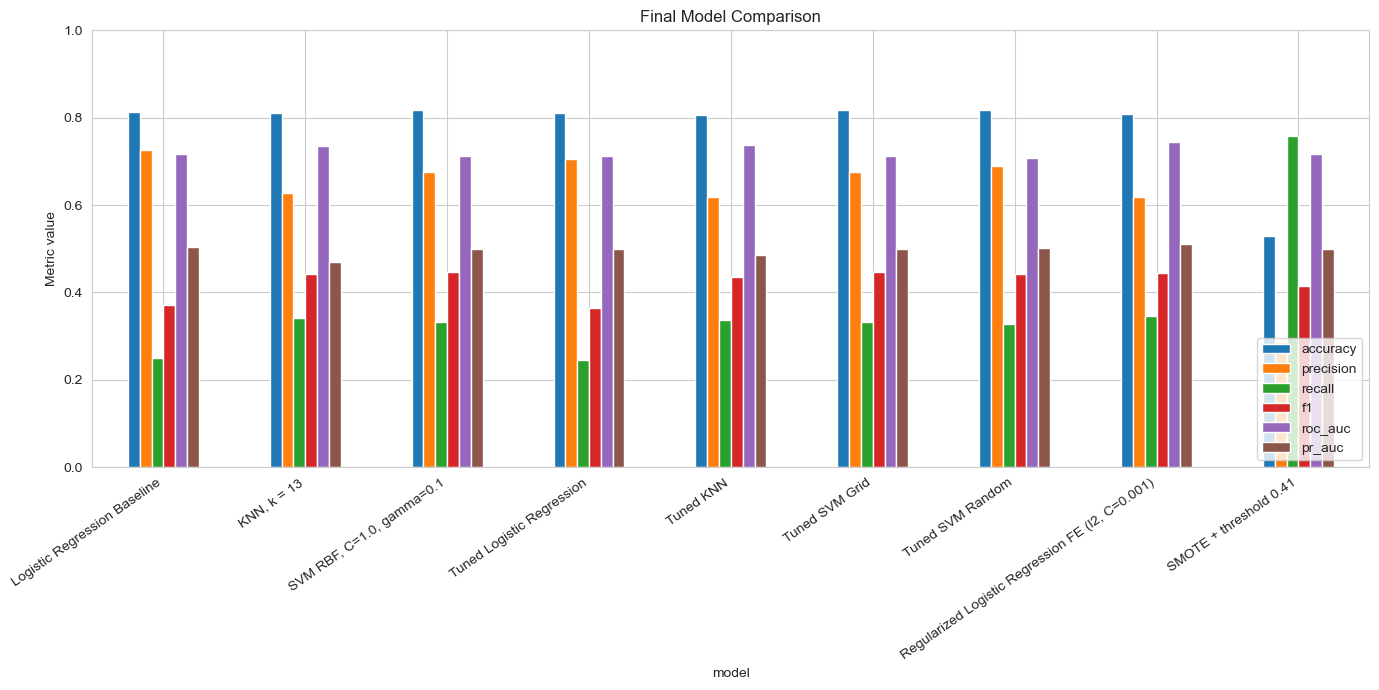

In [302]:
final_results_df.set_index("model")[metrics_to_rank].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Final Model Comparison")
plt.ylabel("Metric value")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10.4 Focus on Business-Critical Metrics

In default prediction, we often care more about detecting risky clients than maximizing overall accuracy.

Therefore, we focus on:

- recall,
- precision,
- F1-score,
- PR AUC.

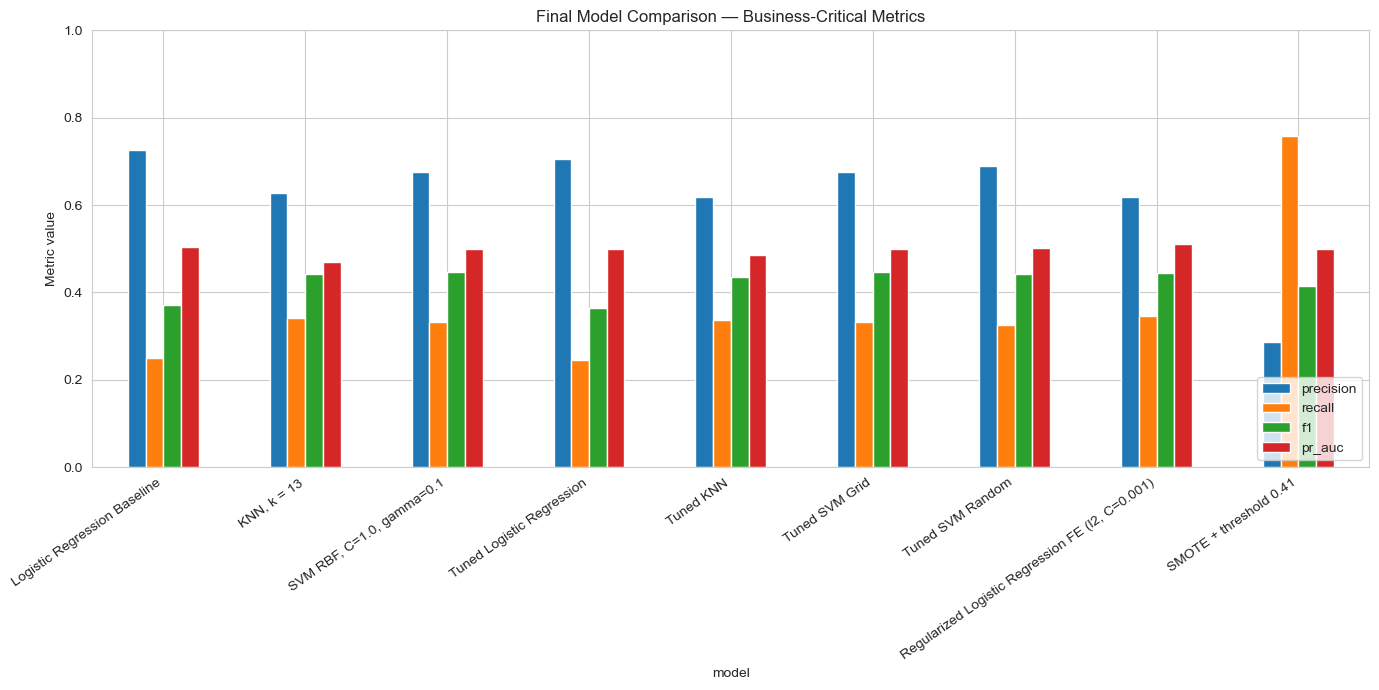

In [303]:
business_metrics = ["precision", "recall", "f1", "pr_auc"]

final_results_df.set_index("model")[business_metrics].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Final Model Comparison — Business-Critical Metrics")
plt.ylabel("Metric value")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10.5 Precision vs Recall Trade-off

Credit risk modeling often requires choosing between:

- detecting more defaulters,
- avoiding too many false alarms.

This plot shows the precision-recall trade-off for all evaluated models.

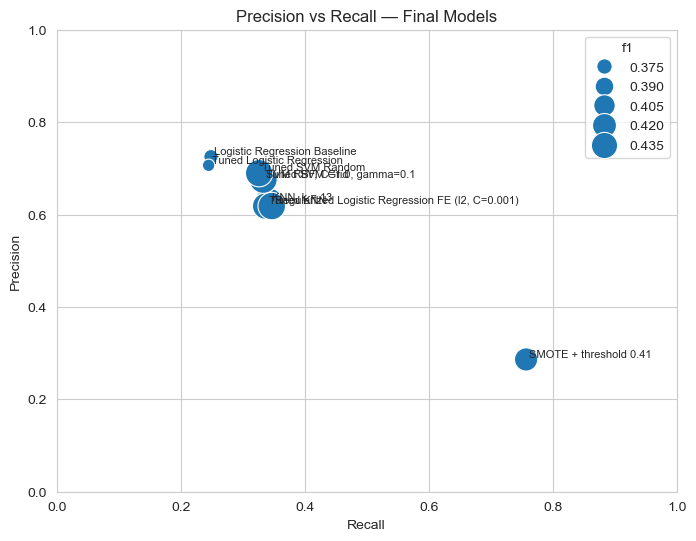

In [304]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=final_results_df,
    x="recall",
    y="precision",
    size="f1",
    sizes=(80, 400),
    legend=True
)

for _, row in final_results_df.iterrows():
    plt.text(
        row["recall"] + 0.005,
        row["precision"] + 0.005,
        row["model"],
        fontsize=8
    )

plt.title("Precision vs Recall — Final Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

Models in the upper-right area are generally more attractive.

However, the final choice depends on whether the business prefers:

- higher recall,
- higher precision,
- or a balanced trade-off.

## 10.6 Select Best Model by F1-score

F1-score balances precision and recall.

This can be a reasonable default choice when both false positives and false negatives matter.

In [305]:
best_f1_model_row = final_results_df.loc[
    final_results_df["f1"].idxmax()
]

best_f1_model_row

model        SVM RBF, C=1.0, gamma=0.1
accuracy                       0.81712
precision                     0.675841
recall                        0.333333
f1                            0.446465
roc_auc                       0.712721
pr_auc                         0.49895
Name: 2, dtype: object

In [317]:
print("Best model by F1-score:")
print(best_f1_model_row["model"])

print("\nMetrics:")

display(
    best_f1_model_row
    .drop("model")
    .to_frame("value")
    .style.format(precision=4)
)

Best model by F1-score:
SVM RBF, C=1.0, gamma=0.1

Metrics:


,value
accuracy,0.8171
precision,0.6758
recall,0.3333
f1,0.4465
roc_auc,0.7127
pr_auc,0.4989


## 10.7 Select Best Model by Recall

If the bank mainly wants to detect as many defaulters as possible, recall may be the primary metric.

In [ ]:
best_recall_model_row = final_results_df.loc[
    final_results_df["recall"].idxmax()
]

best_recall_model_row

In [ ]:
print("Best model by Recall:")
print(best_recall_model_row["model"])
print("\nMetrics:")
print(best_recall_model_row.drop("model").round(4))

## 10.8 Select Best Model by PR AUC

PR AUC evaluates the quality of probability ranking for the positive class.

It is especially useful in imbalanced classification.

In [307]:
best_pr_auc_model_row = final_results_df.loc[
    final_results_df["pr_auc"].idxmax()
]

best_pr_auc_model_row

model        Regularized Logistic Regression FE (l2, C=0.001)
accuracy                                             0.808109
precision                                             0.61828
recall                                               0.346908
f1                                                   0.444444
roc_auc                                              0.743467
pr_auc                                               0.511763
Name: 7, dtype: object

In [316]:
print("Best model by PR AUC:")
print(best_pr_auc_model_row["model"])

print("\nMetrics:")
display(
    best_pr_auc_model_row
    .drop("model")
    .to_frame("value")
    .style.format(precision=4)
)

Best model by PR AUC:
Regularized Logistic Regression FE (l2, C=0.001)

Metrics:


,value
accuracy,0.8081
precision,0.6183
recall,0.3469
f1,0.4444
roc_auc,0.7435
pr_auc,0.5118


## 10.9 Model Selection Depends on Business Objective

We can define three possible decision scenarios:

1. **Balanced objective**  
   Choose the model with the highest F1-score.

2. **Risk-averse objective**  
   Choose the model with the highest recall.

3. **Ranking objective**  
   Choose the model with the highest PR AUC.

Each scenario may lead to a different model.

In [309]:
selection_summary = pd.DataFrame([
    {
        "business_objective": "Balanced precision-recall trade-off",
        "selection_metric": "F1-score",
        "selected_model": best_f1_model_row["model"],
        "score": best_f1_model_row["f1"]
    },
    {
        "business_objective": "Detect as many defaulters as possible",
        "selection_metric": "Recall",
        "selected_model": best_recall_model_row["model"],
        "score": best_recall_model_row["recall"]
    },
    {
        "business_objective": "Rank clients by default risk",
        "selection_metric": "PR AUC",
        "selected_model": best_pr_auc_model_row["model"],
        "score": best_pr_auc_model_row["pr_auc"]
    }
])

selection_summary.round(4)

NameError: name 'best_recall_model_row' is not defined

## 10.10 Optional Business Cost Comparison

In many real projects, we should select a model based on expected business cost.

Here we use a simplified example:

- False Negative cost = 5
- False Positive cost = 1

This means that missing a defaulter is assumed to be five times more expensive than falsely flagging a safe client.

In [310]:
false_negative_cost = 5
false_positive_cost = 1

Because not every model object was stored, we use already available final strategies where predictions exist.

This part is illustrative rather than a complete production-level cost model.

In [311]:
available_prediction_strategies = {}

if "y_pred" in globals():
    available_prediction_strategies["Baseline Logistic Regression"] = y_pred

if "knn_best_pred" in globals():
    available_prediction_strategies["KNN best"] = knn_best_pred

if "svm_best_pred" in globals():
    available_prediction_strategies["SVM best"] = svm_best_pred

if "best_reg_pred" in globals():
    available_prediction_strategies["Regularized Logistic Regression FE"] = best_reg_pred

if "selected_imbalance_pred" in globals():
    available_prediction_strategies["Selected Imbalanced Strategy"] = selected_imbalance_pred

In [312]:
final_cost_results = []

for model_name, pred in available_prediction_strategies.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    
    total_cost = fp * false_positive_cost + fn * false_negative_cost
    
    final_cost_results.append({
        "model": model_name,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
        "total_cost": total_cost
    })

final_cost_results = pd.DataFrame(final_cost_results)

final_cost_results.sort_values("total_cost")

,model,false_positives,false_negatives,true_positives,true_negatives,total_cost
4,Selected Imbalanced Strategy,2503,322,1004,2164,4113
3,Regularized Logistic Regression FE,284,866,460,4383,4614
1,KNN best,269,872,454,4398,4629
2,SVM best,212,884,442,4455,4632
0,Baseline Logistic Regression,125,996,330,4542,5105


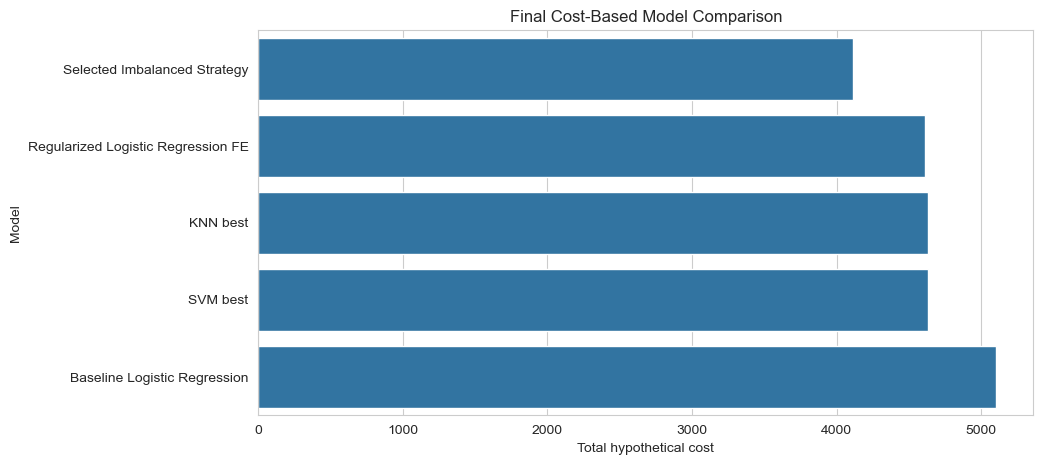

In [313]:
if len(final_cost_results) > 0:
    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=final_cost_results.sort_values("total_cost"),
        x="total_cost",
        y="model"
    )

    plt.title("Final Cost-Based Model Comparison")
    plt.xlabel("Total hypothetical cost")
    plt.ylabel("Model")
    plt.show()

This example shows why model selection should be connected to business consequences.

A model with lower accuracy may still be better if it reduces costly false negatives.

## 10.11 Final Recommended Model

For this educational case study, we recommend selecting the final model according to the business objective.

If the goal is balanced classification performance, choose the best F1-score model.

If the goal is risk detection, choose the best recall model.

If the goal is client prioritization by risk, choose the best PR AUC model.

In [314]:
recommended_model = best_f1_model_row["model"]

print("Recommended model for balanced performance:")
print(recommended_model)

Recommended model for balanced performance:
SVM RBF, C=1.0, gamma=0.1


In [315]:
final_recommendation = {
    "recommended_model": recommended_model,
    "reason": "Highest F1-score among evaluated models",
    "accuracy": best_f1_model_row["accuracy"],
    "precision": best_f1_model_row["precision"],
    "recall": best_f1_model_row["recall"],
    "f1": best_f1_model_row["f1"],
    "roc_auc": best_f1_model_row["roc_auc"],
    "pr_auc": best_f1_model_row["pr_auc"]
}

pd.Series(final_recommendation)

recommended_model                  SVM RBF, C=1.0, gamma=0.1
reason               Highest F1-score among evaluated models
accuracy                                             0.81712
precision                                           0.675841
recall                                              0.333333
f1                                                  0.446465
roc_auc                                             0.712721
pr_auc                                               0.49895
dtype: object

# 11. Final Conclusions

This case study demonstrated the complete machine learning workflow for a binary classification problem in credit risk.

The objective was to predict whether a credit card client would default next month.

We used this problem to study not only model training, but also the practical consequences of different modeling decisions.

## 11.1 What We Learned About the Data

The exploratory analysis showed that:

- the target variable is imbalanced,
- financial variables have very different numerical scales,
- repayment history is strongly related to default risk,
- some variables contain outliers,
- feature engineering can summarize repayment behavior,
- model evaluation must focus on the minority class.

## 11.2 What We Learned About Metrics

Accuracy alone is not sufficient for imbalanced classification.

A model can achieve high accuracy while failing to detect defaulters.

More informative metrics include:

- precision,
- recall,
- F1-score,
- ROC AUC,
- PR AUC,
- confusion matrix.

In credit risk, recall is often especially important because False Negatives represent risky clients that the model failed to identify.

## 11.3 What We Learned About Logistic Regression

Logistic Regression was a useful baseline model.

Its strengths:

- simple,
- fast,
- interpretable,
- provides probability estimates,
- works well with regularization.

Its limitations:

- linear decision boundary,
- may underfit nonlinear relationships,
- requires careful threshold selection.

## 11.4 What We Learned About KNN

KNN demonstrated the importance of geometry.

Its behavior depends strongly on:

- feature scaling,
- number of neighbors,
- distance metric,
- irrelevant features,
- dimensionality.

KNN is intuitive, but it can struggle in high-dimensional datasets and may be computationally expensive.

## 11.5 What We Learned About SVM

SVM introduced the concepts of:

- margins,
- support vectors,
- kernels,
- regularization through `C`,
- nonlinear classification through `gamma`.

SVM can model complex decision boundaries, but it is sensitive to hyperparameters and feature scaling.

## 11.6 What We Learned About Cross-Validation

A single train-test split may give unstable results.

Cross-validation provides a more reliable estimate of model performance.

For imbalanced classification, stratified cross-validation is preferred because it preserves class proportions in each fold.

Hyperparameters should be tuned using cross-validation, not the final test set.

## 11.7 What We Learned About Feature Engineering and Regularization

Feature engineering can improve model performance by creating more informative representations of customer behavior.

Regularization helps control model complexity.

Key insights:

- L1 regularization can perform feature selection,
- L2 regularization stabilizes coefficients,
- polynomial features can model nonlinear effects,
- additional features are useful only if they improve validation performance.

## 11.8 What We Learned About Imbalanced Learning

Class imbalance is central to credit default prediction.

We tested several approaches:

- class weights,
- random undersampling,
- random oversampling,
- SMOTE,
- threshold tuning.

The main trade-off was:

- higher recall usually means lower precision.

The best approach depends on the cost of false positives and false negatives.

## 11.9 Key Practical Takeaways

The most important lessons from this case study are:

1. **Start with a simple baseline.**  
   Complex models are useful only if they improve over a simple reference model.

2. **Never rely only on accuracy.**  
   Especially when classes are imbalanced.

3. **Use pipelines.**  
   They help prevent data leakage and keep preprocessing consistent.

4. **Scale features when needed.**  
   KNN, SVM, and regularized linear models require careful scaling.

5. **Tune thresholds.**  
   The default threshold of 0.5 is not always appropriate.

6. **Use cross-validation.**  
   It gives more reliable model evaluation and safer hyperparameter tuning.

7. **Connect metrics to business costs.**  
   The best model is not always the one with the highest statistical score.

8. **Modeling is iterative.**  
   EDA, feature engineering, model selection, and evaluation influence each other.

## 11.10 Final Message

Machine learning is not only about choosing an algorithm.

It is a complete decision-making process involving:

- understanding the business problem,
- preparing the data,
- selecting relevant metrics,
- building baselines,
- comparing models,
- tuning hyperparameters,
- managing trade-offs,
- and translating predictions into business actions.

In credit default prediction, the most important question is not:

> Which model has the highest accuracy?

but rather:

> Which model helps us make better credit risk decisions?